# Unit-sphere viewer: APD hinge data

Three optical overview stages are compared:

| Stage / `SPHERE_STAGE` | Channel processing | Angle inversion |
|---|---|---|
| `raw` | Recorded channels | Homogeneous full pupil; uncalibrated diagnostic |
| `corrected` | Inverse gains, then supplied inverse optical matrix | Homogeneous full pupil; no hole/interface |
| `fresnel` | Inverse gains, then supplied inverse optical matrix | Annular pupil **and** water-to-oil Fresnel interface |

The overview averages channels in consecutive `BLOCK_US` blocks before forming anisotropy ratios. **Native route analyses and, by default, the sphere use unaveraged 4 us observations.** The sphere has a separate `SPHERE_USE_NATIVE` flag. The second and third optical stages have identical measured anisotropy at the same sampling: the hole/Fresnel model changes the relation between that anisotropy and theta, its validity limit, and its predicted `r_max`. It is not another detector mixing matrix or an automatic radial rescaling.

There is **no channel-minimum lifting, background subtraction, centering, stretching, or automatic NA fitting**. The off-origin circle is fitted on the final-stage measured cloud and remains diagnostic only; it never changes the data or angles.

The **Current Route Test: O and Annular A/B/C** section follows the native time-spent map. It compares observed annular-wedge routes with routes through a central O disk. The earlier radial excursions, ellipse regions, rotated controls, and pinned examples remain below as separate analyses with their original labels. In the preserved-example viewer, the 'current' comparison panel refers to the smaller ellipse fit, not the new annular sectors.

## Controls and validity
- `BLOCK_US`: requested overview integration time. Every complete block is retained; the realised interval and discarded trailing samples are printed.
- `SPHERE_USE_NATIVE = True`: sphere-only native sampling. False uses the existing overview; this flag is in the sphere-coordinate cell.
- `SHOW_EVERY`: sphere-background display thinning only; it does not affect fitting, histograms, occupancy, native routes, or selected-window points and connections.
- `SPHERE_STAGE = "fresnel"` selects the final optical stage by default. `"raw"` and `"corrected"` remain available.
- `NA = 1.3`, `NA_IN = 0.38`, `N_WATER = 1.33`, and `N_OIL = 1.515` specify the optical models. Verify the oil index for the actual setup. There is no global optics switch overriding all three panels.
- `CHANNEL_FLAGS` identifies nonfinite block intensities, nonpositive pair sums, and negative channels. `VALIDITY` also records radii outside each overview stage's own model; `R_MAX_BY_STAGE` holds the corresponding limits. The sphere computes its own mask at its selected sampling. Invalid angles are `NaN`, not clipped.
- `ANNULAR_*` controls define only the new O/sector route analysis; `ABC_*` and `ROTATION_*` still belong to the earlier ellipse analysis.
- `SHOW_TWO_PEAK_DIAGNOSTIC = False` by default. Empirical views assume no state count; the optional two-component fit is descriptive, not evidence for two physical states.

Experimental theta values are estimates under a specified model, not known ground truth. Folded, Unwrapped, and Alternate fold are different azimuth conventions, not uniquely reconstructed 3D trajectories.

In [113]:
TDMS_PATH = r"data\Hinge apd recordings, 2 strand + notches\1.tdms"
BLOCK_US = 80.0
SHOW_EVERY = 3
VIEW = dict(elev=18, azim=55)
TIME_STEP_S = None
SPHERE_STAGE = "fresnel"

NA = 1.3
N_WATER = 1.33
N_OIL = 1.515
NA_IN = 0.38

RIM_SECTOR_DEG = (130.0, 230.0)
RIM_BINS = 90
RIM_EXTREME_POINTS = 3
THETA_TIME_BIN_S = 0.010
SHOW_TWO_PEAK_DIAGNOSTIC = False

## Standalone helper definitions

The following definition cells embed the optical and photometry helpers, radial passages, general geometry, ellipse residence/transition analysis, shared-radius ellipse fitting, and the new annular-zone classifier and route counter. **The notebook does not import or read an external analysis Python file.** The local `ha` object is only a `SimpleNamespace` for the notebook-defined helpers used by earlier cells.

Run the configuration and all helper-definition cells before loading data. Dependencies are Python 3.10 or newer, NumPy, SciPy, Matplotlib, npTDMS, and ipywidgets. Optional **ipympl** provides the mouse-rotatable sphere; four static perspectives remain available without it. Scikit-learn is needed only if `SHOW_TWO_PEAK_DIAGNOSTIC` is enabled. `TDMS_PATH` identifies the input recording; relative paths resolve from the kernel working directory.

The external module remains in the repository for compatibility, but is not a runtime dependency. The regression suite tests the embedded definitions, current annular route rules, sphere controls, earlier region geometry, and permanently pinned historical examples.

In [75]:
import numpy as np

def fourkas_ABC(NA: float = 1.3, n: float = 1.33,
                NA_in: float | None = None) -> tuple[float, float, float]:
    """Published homogeneous full-pupil coefficients, optionally subtracting an inner cone."""
    inner_na = 0.0 if NA_in is None else NA_in
    if not np.all(np.isfinite([NA, n, inner_na])) or not 0 <= inner_na < NA <= n:
        raise ValueError("Require finite 0 <= NA_in < NA <= n")
    a_out = np.arcsin(NA / n)
    if NA_in is None:
        ca = np.cos(a_out)
        A = 1/6 - ca/4 + ca**3/12
        B = ca/8 - ca**3/8
        C = 7/48 - ca/16 - ca**2/16 - ca**3/48
        return A, B, C
    a_in = np.arcsin(NA_in / n)
    ca_o, ca_i = np.cos(a_out), np.cos(a_in)
    A = (1/6 - ca_o/4 + ca_o**3/12) - (1/6 - ca_i/4 + ca_i**3/12)
    B = (ca_o/8 - ca_o**3/8) - (ca_i/8 - ca_i**3/8)
    C = (7/48 - ca_o/16 - ca_o**2/16 - ca_o**3/48) - (7/48 - ca_i/16 - ca_i**2/16 - ca_i**3/48)
    return A, B, C

def fourkas_ABC_fresnel(NA=1.3, n_water=1.33, n_oil=1.515, NA_in=0.38,
                        quadrature_order=128):
    """Circular annulus with one lossless water/oil interface.

    Cartesian pupil FIELD weight: sqrt(cos(alpha_oil))/cos(alpha_water).
    Equal media reproduce fourkas_ABC. No irregular hole, multilayers, or
    near-field emission are modeled. A common intensity scale is omitted.
    """
    parameters = [NA, NA_in, n_water, n_oil]
    if not np.all(np.isfinite(parameters)) or not 0 <= NA_in < NA <= min(n_water, n_oil):
        raise ValueError("Require finite 0 <= NA_in < NA <= min(n_water, n_oil)")
    if (isinstance(quadrature_order, bool) or int(quadrature_order) != quadrature_order
            or quadrature_order < 8):
        raise ValueError("quadrature_order must be an integer >= 8")
    nodes, weights = np.polynomial.legendre.leggauss(int(quadrature_order))
    pupil_radius = NA_in + (nodes + 1) * (NA - NA_in) / 2
    radial_weights = weights * (NA - NA_in) / 2
    sin_water = pupil_radius / n_water
    cos_water = np.sqrt(1 - sin_water**2)
    cos_oil = np.sqrt(1 - (pupil_radius / n_oil)**2)
    transmission_s = 2 * n_water * cos_water / (n_water * cos_water + n_oil * cos_oil)
    transmission_p = 2 * n_water * cos_water / (n_oil * cos_water + n_water * cos_oil)
    pupil_field_weight = np.sqrt(cos_oil) / cos_water
    measure = radial_weights * pupil_radius * pupil_field_weight**2 / n_water**2
    radial_field = transmission_p * cos_water
    coeff_a = np.sum(measure * transmission_p**2 * sin_water**2) / 4
    coeff_a_plus_b = np.sum(measure * (radial_field**2 + transmission_s**2)) / 8
    coeff_c = np.sum(measure * (radial_field + transmission_s)**2) / 16
    return float(coeff_a), float(coeff_a_plus_b - coeff_a), float(coeff_c)

def r_max_of(A, B, C):
    return C / (A + B)

def load_tdms(path, channel_order=("90", "45", "135", "0"), fs=None):
    """Load four APD channels; native order is 90, 45, 135, 0."""
    from nptdms import TdmsFile
    tf = TdmsFile.read(path)
    group = tf.groups()[0]
    chans = group.channels()
    if len(chans) != 4:
        raise ValueError(f"expected 4 channels, got {len(chans)}")
    raw = [ch[:] for ch in chans]
    if fs is None:
        inc = chans[0].properties.get("wf_increment", 4e-6)
        fs = 1.0 / float(inc)
    out = {}
    for name, sig in zip(channel_order, raw):
        out[f"c{name}"] = np.asarray(sig, dtype=np.float64)
    n = min(len(v) for v in out.values())
    for k in list(out):
        out[k] = out[k][:n]
    t = np.arange(n) / fs
    return {"c0": out["c0"], "c45": out["c45"], "c90": out["c90"], "c135": out["c135"],
            "t": t, "fps": fs, "meta": {}, "source": "tdms", "n_frames": int(n)}

def fit_gains_tmatrix(rec, T=None):
    """Fit inverse gains on raw channels with the inverse T inside pair-sum equalization."""
    if T is None:
        T = apd_tmatrix()
    c0, c90, c45, c135 = rec["c0"], rec["c90"], rec["c45"], rec["c135"]
    stack = np.stack([c0, c90, c45, c135], axis=1)
    finite_rows = np.all(np.isfinite(stack), axis=1)
    if not np.all(finite_rows):
        stack = stack[finite_rows]
    if len(stack) < 3:
        raise ValueError("At least three finite samples are required to fit channel gains")
    WT = np.array([1.0, 1.0, -1.0, -1.0]) @ T
    cols = WT * stack
    M = cols[:, 1:]
    y = -cols[:, 0]
    u, *_ = np.linalg.lstsq(M, y, rcond=None)
    a = np.concatenate([[1.0], u])
    return {"0": float(a[0]), "90": float(a[1]), "45": float(a[2]), "135": float(a[3])}

def block_channel_means(rec, n_block, *, return_flags=False):
    """Average consecutive channel blocks before ratios; optionally return validity flags.

    All complete blocks are retained. No clipping, offsets, or sparse sampling.
    """
    if isinstance(n_block, bool) or int(n_block) != n_block or n_block < 1:
        raise ValueError("n_block must be a positive integer")
    n_block = int(n_block)
    def bm(x, n):
        m = len(x) // n * n
        return np.asarray(x, dtype=float)[:m].reshape(-1, n).mean(axis=1)
    c0 = bm(rec["c0"], n_block); c90 = bm(rec["c90"], n_block)
    c45 = bm(rec["c45"], n_block); c135 = bm(rec["c135"], n_block)
    den_x = c0 + c90; den_y = c45 + c135
    channel_values = np.stack((c0, c90, c45, c135))
    nonfinite = ~np.all(np.isfinite(channel_values), axis=0)
    nonpositive_pair_sum = (den_x <= 0) | (den_y <= 0)
    negative_channel = np.any(channel_values < 0, axis=0)
    usable_ratio = ~nonfinite & ~nonpositive_pair_sum
    ax = np.divide(c0 - c90, den_x, out=np.full_like(den_x, np.nan), where=usable_ratio)
    ay = np.divide(c45 - c135, den_y, out=np.full_like(den_y, np.nan), where=usable_ratio)
    t = bm(np.asarray(rec["t"]), n_block)
    result = (ax, ay, t, rec["fps"] / n_block)
    if return_flags:
        flags = {"valid": usable_ratio & ~negative_channel, "nonfinite": nonfinite,
                 "nonpositive_pair_sum": nonpositive_pair_sum, "negative_channel": negative_channel}
        return (*result, flags)
    return result

def apply_gains(rec, gains):
    r = dict(rec)
    for k in ("c0", "c45", "c90", "c135"):
        r[k] = rec[k] * gains[k[1:]]
    return r

def apd_tmatrix():
    """Supplied setup inverse optical matrix, logical order 0, 90, 45, 135."""
    return np.array([
        [ 2.56410256,  0.0,         0.0,         0.0        ],
        [ 0.0,         2.65305220,  0.0,         0.0        ],
        [-0.04047189,  0.04187587,  1.87478350, -0.00045528],
        [-0.04045247,  0.04185578, -0.00046721, 1.82373830],
    ])

def apply_tmatrix(rec, T=None):
    """Apply the already-inverted matrix after inverse channel gains."""
    if T is None:
        T = apd_tmatrix()
    stack = np.stack([rec["c0"], rec["c90"], rec["c45"], rec["c135"]], axis=1)
    corr = stack @ T.T
    return {"c0": corr[:, 0], "c90": corr[:, 1], "c45": corr[:, 2], "c135": corr[:, 3],
            "t": rec["t"], "fps": rec["fps"], "meta": rec.get("meta", {}),
            "source": rec.get("source"), "n_frames": rec["n_frames"]}

def correct_apd_channels(rec, gains=None, T=None):
    """Return corrected recording and inverse gains; no background manipulation."""
    if T is None:
        T = apd_tmatrix()
    if gains is None:
        gains = fit_gains_tmatrix(rec, T)
    return apply_tmatrix(apply_gains(rec, gains), T), gains

def theta_from_r(r, A, B, C, clip_r=False, warn_over=False, *, return_flags=False):
    """Acute optical polar angle; invalid radii stay NaN unless clipping is explicit.

    Flags always describe the original radii, even when clipping is requested.
    """
    r = np.asarray(r, dtype=np.float64)
    if not np.all(np.isfinite([A, B, C])) or A <= 0 or A + B <= 0 or C <= 0:
        raise ValueError("Fourkas coefficients must give positive finite intensities")
    rmax = r_max_of(A, B, C)
    tolerance = 16 * np.finfo(float).eps * max(1.0, abs(rmax))
    nonfinite = ~np.isfinite(r)
    negative_radius = r < 0
    over_range = r > rmax + tolerance
    valid = ~nonfinite & ~negative_radius & ~over_range
    if warn_over and np.any(over_range):
        print(f"  [theta_from_r] {np.count_nonzero(over_range)}/{r.size} radii "
              f"exceed model r_max={rmax:.4f}; check calibration, background, and noise")
    usable = ~nonfinite if clip_r else valid
    radius_used = np.where(usable, np.clip(r, 0.0, rmax), np.nan)
    sine_squared = np.clip(A * radius_used / (C - B * radius_used), 0.0, 1.0)
    theta = np.degrees(np.arcsin(np.sqrt(sine_squared)))
    if return_flags:
        return theta, {"valid": valid, "nonfinite": nonfinite,
                       "negative_radius": negative_radius, "over_range": over_range}
    return theta

In [76]:
def extract_radial_excursions(ax, ay, times, circle_center, circle_radius, *,
                             core_center=None, core_fraction=0.12,
                             outer_fraction=0.8, min_core_samples=3,
                             min_outer_samples=3, valid=None, max_gap_s=None):
    """Outward first passages, with confirmed core/outer runs and gap censoring.

    Start is the last core sample; end is the first sample of a confirmed outer
    run, inclusive. Returning to the core aborts the attempt; no gaps are bridged.
    """
    ax = np.asarray(ax, dtype=float)
    ay = np.asarray(ay, dtype=float)
    times = np.asarray(times, dtype=float)
    if ax.ndim != 1 or ax.shape != ay.shape or ax.shape != times.shape:
        raise ValueError("ax, ay, and times must be matching one-dimensional arrays")
    if not np.all(np.isfinite(times)) or np.any(np.diff(times) <= 0):
        raise ValueError("times must be finite and strictly increasing")
    circle_center = np.asarray(circle_center, dtype=float)
    core_center = circle_center.copy() if core_center is None else np.asarray(core_center, dtype=float)
    if (circle_center.shape != (2,) or core_center.shape != (2,)
            or not np.all(np.isfinite(circle_center)) or not np.all(np.isfinite(core_center))):
        raise ValueError("circle_center and core_center must be finite coordinate pairs")
    if (not np.all(np.isfinite([circle_radius, core_fraction, outer_fraction]))
            or circle_radius <= 0 or not 0 < core_fraction < outer_fraction <= 1):
        raise ValueError("Require positive circle_radius and 0 < core_fraction < outer_fraction <= 1")
    if np.linalg.norm(core_center - circle_center) / circle_radius + core_fraction >= outer_fraction:
        raise ValueError("The central disk must lie strictly inside the outer threshold")
    for sample_count in (min_core_samples, min_outer_samples):
        if isinstance(sample_count, bool) or int(sample_count) != sample_count or sample_count < 1:
            raise ValueError("Residence checks require positive integer sample counts")
    usable = np.isfinite(ax) & np.isfinite(ay)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != ax.shape:
            raise ValueError("valid must match the sample arrays")
        usable &= valid
    if max_gap_s is None:
        max_gap_s = 1.5 * np.median(np.diff(times)) if len(times) > 1 else np.inf
    if np.isnan(max_gap_s) or max_gap_s <= 0:
        raise ValueError("max_gap_s must be positive")
    gap_before = np.concatenate(([False], np.diff(times) > max_gap_s)) if len(times) else np.array([], bool)
    core_mask = np.hypot(ax - core_center[0], ay - core_center[1]) <= core_fraction * circle_radius
    radius_fraction = np.hypot(ax - circle_center[0], ay - circle_center[1]) / circle_radius
    paths = []
    aborted = censored = attempts = 0
    core_run = outer_run = 0
    armed = False
    start_idx = last_core_idx = first_outer_idx = None
    for sample_index in range(len(times)):
        if gap_before[sample_index] or not usable[sample_index]:
            censored += int(start_idx is not None)
            armed = False
            start_idx = last_core_idx = first_outer_idx = None
            core_run = outer_run = 0
            if not usable[sample_index]:
                continue
        if core_mask[sample_index]:
            if start_idx is not None:
                aborted += 1
                start_idx = first_outer_idx = None
                outer_run = 0
                armed = False
            core_run += 1
            last_core_idx = sample_index
            if core_run >= min_core_samples:
                armed = True
            continue
        core_run = 0
        if not armed:
            continue
        if start_idx is None:
            start_idx = last_core_idx
            attempts += 1
        if radius_fraction[sample_index] >= outer_fraction:
            if outer_run == 0:
                first_outer_idx = sample_index
            outer_run += 1
            if outer_run >= min_outer_samples:
                paths.append({
                    "start_idx": int(start_idx), "end_idx": int(first_outer_idx),
                    "confirm_idx": sample_index,
                    "duration_s": float(times[first_outer_idx] - times[start_idx]),
                    "n_samples": int(first_outer_idx - start_idx + 1),
                })
                start_idx = first_outer_idx = None
                outer_run = 0
                armed = False
        else:
            outer_run = 0
            first_outer_idx = None
    censored += int(start_idx is not None)
    return {"paths": paths, "attempts": attempts, "aborted": aborted,
            "censored": censored, "invalid_samples": int((~usable).sum()),
            "time_gaps": int(gap_before.sum()), "core_center": core_center.copy(),
            "core_radius": float(core_fraction * circle_radius),
            "outer_radius": float(outer_fraction * circle_radius)}

def radial_crossing_profiles(ax, ay, times, excursions, circle_center, circle_radius, fractions):
    """One locally interpolated outward crossing per passage/gate; bearing is NOT rod phi.

    Interior gates use the first crossing; the target uses the confirmed endpoint.
    """
    points = np.column_stack((ax, ay)).astype(float)
    times = np.asarray(times, dtype=float)
    circle_center = np.asarray(circle_center, dtype=float)
    fractions = np.asarray(fractions, dtype=float)
    if (fractions.ndim != 1 or not np.all(np.isfinite(fractions))
            or np.any(fractions <= 0) or np.any(np.diff(fractions) <= 0)):
        raise ValueError("fractions must be finite, positive, and strictly increasing")
    if not np.isfinite(circle_radius) or circle_radius <= 0:
        raise ValueError("circle_radius must be positive and finite")
    shape = (len(excursions["paths"]), len(fractions))
    crossings = np.full((*shape, 2), np.nan)
    crossing_times = np.full(shape, np.nan)
    for event_index, event in enumerate(excursions["paths"]):
        start_idx, end_idx = event["start_idx"], event["end_idx"]
        segment = points[start_idx:end_idx + 1]
        radius = np.linalg.norm(segment - circle_center, axis=1)
        for gate_index, fraction in enumerate(fractions):
            target = fraction * circle_radius
            brackets = np.flatnonzero((radius[:-1] < target) & (radius[1:] >= target))
            if len(brackets) == 0:
                continue
            if np.isclose(target, excursions["outer_radius"], rtol=1e-12, atol=0):
                local_index = len(segment) - 2
                if local_index not in brackets:
                    continue
            else:
                local_index = int(brackets[0])
            offset = segment[local_index] - circle_center
            increment = segment[local_index + 1] - segment[local_index]
            quadratic = float(increment @ increment)
            linear = float(2 * offset @ increment)
            constant = float(offset @ offset - target**2)
            weight = (-linear + np.sqrt(max(0., linear**2 - 4 * quadratic * constant))) / (2 * quadratic)
            weight = float(np.clip(weight, 0, 1))
            crossings[event_index, gate_index] = segment[local_index] + weight * increment
            absolute_index = start_idx + local_index
            crossing_times[event_index, gate_index] = (
                times[absolute_index] + weight * (times[absolute_index + 1] - times[absolute_index]))
    offsets = crossings - circle_center
    bearings = np.degrees(np.arctan2(offsets[..., 1], offsets[..., 0])) % 360
    return {"points": crossings, "times": crossing_times, "bearing_deg": bearings,
            "fractions": fractions.copy()}

def fit_origin_separator(ax, ay, *, radial_band=(0.5, 0.75),
                         angle_bounds_deg=(115.0, 170.0), smoothing_deg=3.0,
                         angular_step_deg=0.5, valid=None):
    """Lowest interior angular-density valley in a prescribed origin annulus/sector.

    Without an interior valley, the sector minimum is returned with a warning flag.
    Only the histogram is smoothed, not time-ordered observations.
    """
    from scipy.ndimage import gaussian_filter1d
    from scipy.signal import find_peaks

    ax, ay = np.asarray(ax, dtype=float), np.asarray(ay, dtype=float)
    if ax.ndim != 1 or ax.shape != ay.shape:
        raise ValueError("ax and ay must be matching one-dimensional arrays")
    lower_r, upper_r = radial_band
    lower_angle, upper_angle = angle_bounds_deg
    if (not np.all(np.isfinite([lower_r, upper_r, lower_angle, upper_angle,
                               smoothing_deg, angular_step_deg]))
            or not 0 <= lower_r < upper_r or not 0 < lower_angle < upper_angle < 180
            or smoothing_deg <= 0 or not 0 < angular_step_deg <= upper_angle - lower_angle):
        raise ValueError("Invalid radial band, angular sector, or smoothing resolution")
    usable = np.isfinite(ax) & np.isfinite(ay)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != ax.shape:
            raise ValueError("valid must match the samples")
        usable &= valid
    radius = np.hypot(ax, ay)
    selected = usable & (radius >= lower_r) & (radius <= upper_r)
    if not np.any(selected):
        raise ValueError("No valid samples in the separator annulus")
    angles = np.degrees(np.arctan2(ay[selected], ax[selected])) % 360
    bin_count = max(4, int(np.ceil(360 / angular_step_deg)))
    edges = np.linspace(0., 360., bin_count + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    counts, _ = np.histogram(angles, bins=edges)
    density = gaussian_filter1d(counts.astype(float), smoothing_deg / (360 / bin_count), mode="wrap")
    candidates = np.flatnonzero((centers >= lower_angle) & (centers <= upper_angle))
    if not np.any(counts[candidates]):
        raise ValueError("No samples in the requested separator sector")
    local_minima, _ = find_peaks(-density)
    interior = np.intersect1d(candidates, local_minima)
    chosen = int(interior[np.argmin(density[interior])]) if len(interior) else int(candidates[np.argmin(density[candidates])])
    angle_deg = float(centers[chosen])
    angle = np.radians(angle_deg)
    normal = np.array([-np.sin(angle), np.cos(angle)])
    return {"angle_deg": angle_deg, "normal": normal,
            "angles_deg": centers, "counts": counts, "smoothed_counts": density,
            "radial_band": tuple(radial_band), "angle_bounds_deg": tuple(angle_bounds_deg),
            "interior_minimum": bool(len(interior)), "annulus_samples": int(selected.sum()),
            "smoothing_deg": float(smoothing_deg)}

def fit_origin_core_radius(ax, ay, *, quantile=0.95, right_radius_limit=0.30, valid=None):
    """Origin-centered A radius from a documented right-side radial quantile; no clipping."""
    ax, ay = np.asarray(ax, dtype=float), np.asarray(ay, dtype=float)
    if ax.ndim != 1 or ax.shape != ay.shape:
        raise ValueError("ax and ay must be matching one-dimensional arrays")
    if not 0 < quantile < 1 or not np.isfinite(right_radius_limit) or right_radius_limit <= 0:
        raise ValueError("Require 0 < quantile < 1 and a positive radius limit")
    usable = np.isfinite(ax) & np.isfinite(ay)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != ax.shape:
            raise ValueError("valid must match the samples")
        usable &= valid
    radius = np.hypot(ax, ay)
    selected = usable & (ax >= 0) & (radius <= right_radius_limit)
    if not np.any(selected):
        raise ValueError("No valid right-side samples for the central disk")
    fitted_radius = float(np.quantile(radius[selected], quantile))
    if fitted_radius <= 0:
        raise ValueError("The fitted central radius is zero")
    return {"radius": fitted_radius, "quantile": quantile,
            "right_radius_limit": right_radius_limit, "selected_samples": int(selected.sum())}

def ellipse_region_clearances(region, origin_radius, separator_normal, side):
    """Exact filled-ellipse clearance from an origin-crossing line and disk."""
    from scipy.optimize import brentq

    center = np.asarray(region["center"], dtype=float)
    axes = np.asarray(region["semiaxes"], dtype=float)
    angle = np.radians(region.get("angle_deg", 0.))
    normal = np.asarray(separator_normal, dtype=float)
    if (center.shape != (2,) or axes.shape != (2,) or normal.shape != (2,)
            or not np.all(np.isfinite(np.r_[center, axes, normal, angle, origin_radius]))
            or np.any(axes <= 0) or np.linalg.norm(normal) == 0 or origin_radius < 0
            or side not in (-1, 1)):
        raise ValueError("Invalid ellipse, disk, separator, or side")
    normal = normal / np.linalg.norm(normal)
    rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    projected_normal = rotation.T @ normal
    support = np.linalg.norm(axes * projected_normal)
    line_gap = float(side * (center @ normal) - support)
    local_center = rotation.T @ center
    if np.sum((local_center / axes)**2) <= 1:
        distance_to_origin = 0.
    else:
        squared_axes = axes**2
        multiplier = brentq(
            lambda value: np.sum((axes * local_center / (squared_axes + value))**2) - 1,
            0., float(np.linalg.norm(axes * local_center)), xtol=1e-13,
        )
        distance_to_origin = float(np.linalg.norm(local_center * multiplier / (squared_axes + multiplier)))
    return {"line_gap": line_gap, "disk_gap": distance_to_origin - origin_radius}

def fit_equal_area_ellipses(ax, ay, a_radius, separator_normal, *, valid=None,
                           histogram_step=0.01, clearance=0.005, max_aspect=4.0,
                           maxiter=160, popsize=12, seed=0):
    """Histogram occupancy search with exact equal-area, line, and A-disk constraints.

    Differential evolution gives a bounded numerical optimum, not a certified
    global maximum. Classify native samples separately after this spatial fit.
    """
    from scipy.optimize import differential_evolution, NonlinearConstraint

    ax, ay = np.asarray(ax, dtype=float), np.asarray(ay, dtype=float)
    normal = np.asarray(separator_normal, dtype=float)
    if ax.ndim != 1 or ax.shape != ay.shape:
        raise ValueError("ax and ay must be matching one-dimensional arrays")
    if (normal.shape != (2,) or not np.all(np.isfinite(normal)) or np.linalg.norm(normal) == 0
            or not np.all(np.isfinite([a_radius, histogram_step, clearance, max_aspect]))
            or a_radius <= 0 or histogram_step <= 0 or clearance <= 0 or max_aspect < 1):
        raise ValueError("Invalid radius, histogram spacing, clearance, aspect ratio, or normal")
    normal = normal / np.linalg.norm(normal)
    usable = np.isfinite(ax) & np.isfinite(ay)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != ax.shape:
            raise ValueError("valid must match the samples")
        usable &= valid
    if not np.any(usable):
        raise ValueError("No valid samples for ellipse fitting")
    selected_x, selected_y = ax[usable], ay[usable]
    edges = []
    for values in (selected_x, selected_y):
        lower = int(np.floor(values.min() / histogram_step))
        upper = max(lower + 1, int(np.ceil(values.max() / histogram_step)))
        edges.append(np.arange(lower, upper + 1) * histogram_step)
    histogram, x_edges, y_edges = np.histogram2d(selected_x, selected_y, bins=edges)
    x_indices, y_indices = np.nonzero(histogram)
    points = np.column_stack(((x_edges[x_indices] + x_edges[x_indices + 1]) / 2,
                              (y_edges[y_indices] + y_edges[y_indices + 1]) / 2))
    weights = histogram[x_indices, y_indices]
    regions = {"A": {"center": (0., 0.), "semiaxes": (a_radius, a_radius), "angle_deg": 0.}}
    diagnostics = {}
    padding = a_radius * np.sqrt(max_aspect)

    def unpack(parameters):
        center_x, center_y, log_aspect, angle_deg = parameters
        major = a_radius * np.exp(log_aspect / 2)
        minor = a_radius * np.exp(-log_aspect / 2)
        return {"center": (center_x, center_y), "semiaxes": (major, minor), "angle_deg": angle_deg}

    for side_index, (name, side) in enumerate((("B", 1), ("C", -1))):
        eligible = (side * (points @ normal) > clearance) & (np.linalg.norm(points, axis=1) > a_radius + clearance)
        fit_points, fit_weights = points[eligible], weights[eligible]
        if not len(fit_points):
            raise ValueError(f"No eligible histogram bins for region {name}")
        normalization = float(fit_weights.sum())

        def objective(parameters):
            center_x, center_y, log_aspect, angle_deg = parameters
            angle = np.radians(angle_deg)
            offset_x = fit_points[:, 0] - center_x
            offset_y = fit_points[:, 1] - center_y
            major = a_radius * np.exp(log_aspect / 2)
            minor = a_radius * np.exp(-log_aspect / 2)
            along = (np.cos(angle) * offset_x + np.sin(angle) * offset_y) / major
            across = (-np.sin(angle) * offset_x + np.cos(angle) * offset_y) / minor
            return -float(fit_weights[along**2 + across**2 <= 1].sum()) / normalization

        def margins(parameters):
            gaps = ellipse_region_clearances(unpack(parameters), a_radius, normal, side)
            return np.array([gaps["line_gap"], gaps["disk_gap"]])

        bounds = [(float(fit_points[:, axis].min() - padding), float(fit_points[:, axis].max() + padding))
                  for axis in range(2)] + [(0., float(np.log(max_aspect))), (0., 180.)]
        result = differential_evolution(
            objective, bounds, constraints=(NonlinearConstraint(margins, clearance, np.inf),),
            seed=int(seed) + side_index, maxiter=int(maxiter), popsize=int(popsize),
            polish=False, tol=1e-4, atol=1e-7,
        )
        ellipse = unpack(result.x)
        gaps = ellipse_region_clearances(ellipse, a_radius, normal, side)
        if not np.isfinite(result.fun) or min(gaps.values()) < clearance - 1e-10:
            raise RuntimeError(f"No feasible equal-area ellipse for {name}; adjust fit limits")
        regions[name] = ellipse
        diagnostics[name] = {**gaps, "histogram_count": -float(result.fun) * normalization,
                             "converged": bool(result.success), "iterations": int(result.nit),
                             "message": str(result.message), "aspect_ratio": float(np.exp(result.x[2]))}
    return {"regions": regions, "diagnostics": diagnostics,
            "area": float(np.pi * a_radius**2), "clearance": clearance,
            "histogram_step": histogram_step, "max_aspect": max_aspect}

In [77]:
def classify_region_cores(ax, ay, regions, *, valid=None, scale=1.0):
    """Elliptical cores in insertion order; -1 unassigned, -2 invalid. No gap filling."""
    ax = np.asarray(ax, dtype=float)
    ay = np.asarray(ay, dtype=float)
    if ax.ndim != 1 or ay.shape != ax.shape:
        raise ValueError("ax and ay must be matching one-dimensional arrays")
    if not regions or len(regions) > np.iinfo(np.int16).max:
        raise ValueError("At least one region and at most 32767 regions are required")
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError("scale must be positive and finite")
    usable = np.isfinite(ax) & np.isfinite(ay)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != ax.shape:
            raise ValueError("valid must match the sample arrays")
        usable &= valid
    labels = np.full(ax.shape, -1, dtype=np.int16)
    labels[~usable] = -2
    for region_code, (region_name, specification) in enumerate(regions.items()):
        center = np.asarray(specification["center"], dtype=float)
        semiaxes = np.asarray(specification["semiaxes"], dtype=float)
        angle_deg = float(specification.get("angle_deg", 0.0))
        if (center.shape != (2,) or semiaxes.shape != (2,)
                or not np.all(np.isfinite(center)) or not np.all(np.isfinite(semiaxes))
                or np.any(semiaxes <= 0) or not np.isfinite(angle_deg)):
            raise ValueError(f"Invalid ellipse specification for region {region_name}")
        cosine, sine = np.cos(np.radians(angle_deg)), np.sin(np.radians(angle_deg))
        offset_x, offset_y = ax - center[0], ay - center[1]
        along = (cosine * offset_x + sine * offset_y) / (scale * semiaxes[0])
        across = (-sine * offset_x + cosine * offset_y) / (scale * semiaxes[1])
        inside = usable & (along**2 + across**2 <= 1.0)
        overlap = inside & (labels >= 0)
        if np.any(overlap):
            raise ValueError(f"Region {region_name} overlaps another core at "
                             f"{np.count_nonzero(overlap)} samples; adjust the region boundaries")
        labels[inside] = region_code
    return {"labels": labels, "region_names": tuple(regions)}

def region_residence_statistics(labels, times, rate, region_names, *, min_visit_samples=1):
    """Measured occupancy and uninterrupted runs; minimum duration never changes occupancy.

    Gaps, invalid neighbors and recording edges censor visit boundaries. Such
    runs are excluded from complete-visit summaries, not from observed exposure.
    """
    labels = np.asarray(labels)
    times = np.asarray(times, dtype=float)
    region_names = tuple(region_names)
    if labels.ndim != 1 or labels.shape != times.shape or not np.issubdtype(labels.dtype, np.integer):
        raise ValueError("labels must be integer codes matching one-dimensional times")
    if (not region_names or len(set(region_names)) != len(region_names)
            or any(name in ("unassigned", "invalid") for name in region_names)):
        raise ValueError("region_names must be unique and exclude reserved names")
    if np.any(labels < -2) or np.any(labels >= len(region_names)):
        raise ValueError("Unknown region label")
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError("rate must be positive and finite")
    if (isinstance(min_visit_samples, bool) or int(min_visit_samples) != min_visit_samples
            or min_visit_samples < 1):
        raise ValueError("min_visit_samples must be a positive integer")
    increments = np.diff(times)
    if not np.all(np.isfinite(times)) or np.any(increments <= 0):
        raise ValueError("times must be finite and strictly increasing")
    interval = 1.0 / rate
    gaps = increments > 1.5 * interval
    if np.any(~gaps & ~np.isclose(increments, interval, rtol=1e-6, atol=1e-12)):
        raise ValueError("Samples must be on the stated uniform time grid apart from gaps")
    sample_count = len(labels)
    gap_before = np.concatenate(([False], gaps)) if sample_count else np.array([], dtype=bool)
    if sample_count:
        starts = np.concatenate(([0], np.flatnonzero((labels[1:] != labels[:-1]) | gaps) + 1))
        stops = np.concatenate((starts[1:], [sample_count]))
        codes = labels[starts]
        left_censored = (starts == 0) | gap_before[starts] | (labels[np.maximum(starts - 1, 0)] == -2)
        next_indices = np.minimum(stops, sample_count - 1)
        right_censored = (stops == sample_count) | gap_before[next_indices] | (labels[next_indices] == -2)
    else:
        starts = stops = np.array([], dtype=int)
        codes = np.array([], dtype=int)
        left_censored = right_censored = np.array([], dtype=bool)
    lengths = stops - starts
    durations = lengths / rate
    retained = (codes >= 0) & (lengths >= min_visit_samples)
    censored = left_censored | right_censored
    valid_count = int(np.count_nonzero(labels != -2))
    sample_counts = np.bincount(labels.astype(np.int64) + 2, minlength=len(region_names) + 2)
    summary = {}
    categories = list(enumerate(region_names)) + [(-1, "unassigned"), (-2, "invalid")]
    for code, name in categories:
        region_runs = codes == code
        retained_runs = region_runs & retained
        complete_durations = durations[retained_runs & ~censored]
        count = int(sample_counts[code + 2])
        summary[name] = {
            "samples": count, "time_s": count / rate,
            "fraction_recorded": count / sample_count if sample_count else np.nan,
            "fraction_valid": count / valid_count if valid_count and code != -2 else np.nan,
            "n_runs": int(np.count_nonzero(region_runs)),
            "n_censored_runs": int(np.count_nonzero(region_runs & censored)),
            "n_short_runs": int(np.count_nonzero(region_runs & (lengths < min_visit_samples))),
            "n_retained_complete_runs": len(complete_durations),
            "retained_time_s": float(np.sum(durations[retained_runs])),
            "complete_durations_s": complete_durations,
            "median_complete_s": float(np.median(complete_durations)) if len(complete_durations) else np.nan,
        }
    return {
        "summary": summary,
        "runs": {"start_idx": starts, "stop_idx": stops, "region_code": codes,
                 "duration_s": durations, "left_censored": left_censored,
                 "right_censored": right_censored, "retained": retained},
        "observed_time_s": sample_count / rate, "valid_time_s": valid_count / rate,
        "span_s": float(times[-1] - times[0] + interval) if sample_count else 0.,
        "time_gaps": int(np.count_nonzero(gaps)), "minimum_visit_s": min_visit_samples / rate,
    }

def region_transition_counts(residence, region_names=("A", "B", "C")):
    """Committed-core transitions and B/C passages with every intervening A contact retained.

    A single A observation excludes no_A_sample even if it does not meet the
    commitment duration. Same-source revisits reset the passage start; invalid
    data or timestamp gaps reset all chains. Counts are observational, not proof
    of a physical direct path or fitted kinetic rates.
    """
    region_names = tuple(region_names)
    if len(region_names) != 3 or set(region_names) != {"A", "B", "C"}:
        raise ValueError("Exactly A, B, and C region names are required")
    runs = residence["runs"]
    codes = np.asarray(runs["region_code"])
    starts, stops = runs["start_idx"], runs["stop_idx"]
    retained = runs["retained"]
    a_code, b_code, c_code = (region_names.index(name) for name in ("A", "B", "C"))
    counts = np.zeros((3, 3), dtype=int)
    committed_visit_counts = np.zeros(3, dtype=int)
    previous_code = None
    endpoint = None
    a_samples = unassigned_samples = 0
    max_a_samples = 0
    committed_a = False
    passages = []
    for run_index, code in enumerate(codes):
        if runs["left_censored"][run_index] or code == -2:
            previous_code = None
            endpoint = None
            a_samples = unassigned_samples = max_a_samples = 0
            committed_a = False
        if code == -2:
            continue
        length = int(stops[run_index] - starts[run_index])
        if retained[run_index]:
            committed_visit_counts[code] += 1
            if previous_code is not None and previous_code != code:
                counts[previous_code, code] += 1
            previous_code = int(code)
        if endpoint is not None:
            if code == a_code:
                a_samples += length
                max_a_samples = max(max_a_samples, length)
                committed_a |= bool(retained[run_index])
            elif code == -1:
                unassigned_samples += length
        if retained[run_index] and code in (b_code, c_code):
            if endpoint is not None and endpoint["code"] != code:
                category = "committed_A" if committed_a else ("brief_A" if a_samples else "no_A_sample")
                passages.append({
                    "from": region_names[endpoint["code"]], "to": region_names[code],
                    "start_idx": endpoint["stop_idx"] - 1, "end_idx": int(starts[run_index]),
                    "source_run": endpoint["run"], "destination_run": run_index,
                    "category": category, "a_samples": a_samples,
                    "max_a_run_samples": max_a_samples, "unassigned_samples": unassigned_samples,
                })
            endpoint = {"code": int(code), "stop_idx": int(stops[run_index]), "run": run_index}
            a_samples = unassigned_samples = max_a_samples = 0
            committed_a = False
        if runs["right_censored"][run_index]:
            previous_code = None
            endpoint = None
            a_samples = unassigned_samples = max_a_samples = 0
            committed_a = False
    categories = ("no_A_sample", "brief_A", "committed_A")
    bc_counts = {direction: dict.fromkeys(categories, 0) for direction in ("B->C", "C->B")}
    for passage in passages:
        bc_counts[f"{passage['from']}->{passage['to']}"][passage["category"]] += 1
    return {"counts": counts, "region_names": region_names,
            "committed_visit_counts": committed_visit_counts,
            "bc_counts": bc_counts, "bc_passages": passages,
            "minimum_visit_s": residence["minimum_visit_s"]}

from types import SimpleNamespace

ha = SimpleNamespace(**{function.__name__: function for function in (
    fourkas_ABC, fourkas_ABC_fresnel, r_max_of, load_tdms, fit_gains_tmatrix,
    block_channel_means, apply_gains, apd_tmatrix, apply_tmatrix, correct_apd_channels,
    theta_from_r, extract_radial_excursions, radial_crossing_profiles,
    fit_origin_separator, fit_origin_core_radius, ellipse_region_clearances,
    fit_equal_area_ellipses, classify_region_cores, region_residence_statistics,
    region_transition_counts,
 )})

In [78]:
def radial_region_gaps(regions):
    """Edge gaps for congruent radial B/C ellipses at a common origin distance.

    Reflection symmetry about their angular bisector makes the B/C closest
    points lie along the center-to-center direction. A negative B/C value
    denotes overlap; for disjoint regions the formula is the exact gap.
    """
    if set(regions) != {'A', 'B', 'C'}:
        raise ValueError('Require A/B/C regions')
    a_center = np.asarray(regions['A']['center'], dtype=float)
    a_axes = np.asarray(regions['A']['semiaxes'], dtype=float)
    if (a_center.shape != (2,) or a_axes.shape != (2,) or not np.allclose(a_center, 0, atol=1e-12, rtol=0)
            or not np.all(np.isfinite(a_axes)) or np.any(a_axes <= 0) or not np.isclose(a_axes[0], a_axes[1])):
        raise ValueError('A must be an origin-centered disk')
    directions, distances, shapes = [], [], []
    for name in ('B', 'C'):
        center = np.asarray(regions[name]['center'], dtype=float)
        axes = np.asarray(regions[name]['semiaxes'], dtype=float)
        angle = np.radians(regions[name].get('angle_deg', 0.))
        if (center.shape != (2,) or axes.shape != (2,) or not np.all(np.isfinite(np.r_[center, axes, angle]))
                or np.any(axes <= 0) or axes[0] < axes[1] or np.linalg.norm(center) == 0):
            raise ValueError('Invalid radial ellipse')
        distance = float(np.linalg.norm(center))
        axis_direction = np.array([np.cos(angle), np.sin(angle)])
        if abs(center[0] * axis_direction[1] - center[1] * axis_direction[0]) > 1e-10:
            raise ValueError('Ellipse major-axis line must pass through the origin')
        directions.append(center / distance)
        distances.append(distance)
        shapes.append(axes)
    if not np.allclose(shapes[0], shapes[1], rtol=1e-10, atol=1e-12) or not np.isclose(distances[0], distances[1], rtol=1e-10, atol=1e-12):
        raise ValueError('B/C must have identical semiaxes and equal center radii')
    major, minor = shapes[0]
    cosine = float(np.clip(directions[0] @ directions[1], -1., 1.))
    sine_half = np.sqrt((1 - cosine) / 2)
    support = np.sqrt(major**2 * (1 - cosine) / 2 + minor**2 * (1 + cosine) / 2)
    pair_gap = (distances[0] + distances[1]) * sine_half - 2 * support
    return {'A-B': distances[0] - major - a_axes[0],
            'A-C': distances[1] - major - a_axes[0], 'B-C': float(pair_gap)}

def fit_radial_equal_area_ellipses(ax, ay, a_radius, separator_normal, *, valid=None,
                                  histogram_step=0.01, clearance=0.005, pair_clearance=None,
                                  min_aspect=2.0, max_aspect=4.0, maxiter=320, popsize=12, seed=0):
    """Fit shared radial shape AND shared center radius, with explicit pairwise gaps.

    All areas equal pi*a_radius**2. The four fitted parameters are common aspect
    ratio, common center distance, and the B/C bearings. Pairwise edge gaps must
    be >= pair_clearance (at least a_radius); clearance is the separate line gap.
    The objective is summed native histogram counts, not transition outcomes.
    """
    from scipy.optimize import differential_evolution, NonlinearConstraint

    x_values, y_values = np.asarray(ax, dtype=float), np.asarray(ay, dtype=float)
    normal = np.asarray(separator_normal, dtype=float)
    pair_clearance = a_radius if pair_clearance is None else float(pair_clearance)
    if x_values.ndim != 1 or x_values.shape != y_values.shape:
        raise ValueError('ax and ay must be matching one-dimensional arrays')
    if (normal.shape != (2,) or not np.all(np.isfinite(normal)) or np.linalg.norm(normal) == 0
            or not np.all(np.isfinite([a_radius, histogram_step, clearance, pair_clearance, min_aspect, max_aspect]))
            or a_radius <= 0 or histogram_step <= 0 or clearance <= 0 or pair_clearance < a_radius
            or not 1 < min_aspect <= max_aspect):
        raise ValueError('Require positive radius/spacing/line gap, pair_clearance >= a_radius, and 1 < min_aspect <= max_aspect')
    for count in (maxiter, popsize):
        if isinstance(count, bool) or int(count) != count or count < 1:
            raise ValueError('maxiter and popsize must be positive integers')
    normal = normal / np.linalg.norm(normal)
    usable = np.isfinite(x_values) & np.isfinite(y_values)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != x_values.shape:
            raise ValueError('valid must match the samples')
        usable &= valid
    if not np.any(usable):
        raise ValueError('No valid samples for radial ellipse fitting')
    selected_x, selected_y = x_values[usable], y_values[usable]
    edges = []
    for values in (selected_x, selected_y):
        lower = int(np.floor(values.min() / histogram_step))
        upper = max(lower + 1, int(np.ceil(values.max() / histogram_step)))
        edges.append(np.arange(lower, upper + 1) * histogram_step)
    histogram, x_edges, y_edges = np.histogram2d(selected_x, selected_y, bins=edges)
    x_indices, y_indices = np.nonzero(histogram)
    points = np.column_stack(((x_edges[x_indices] + x_edges[x_indices + 1]) / 2,
                              (y_edges[y_indices] + y_edges[y_indices + 1]) / 2))
    weights = histogram[x_indices, y_indices]
    point_radii = np.linalg.norm(points, axis=1)
    side_data = []
    for name, side in (('B', 1), ('C', -1)):
        eligible = (side * (points @ normal) > clearance) & (point_radii > a_radius + pair_clearance)
        if not np.any(eligible):
            raise ValueError(f'No eligible histogram bins for region {name}')
        side_data.append((points[eligible], weights[eligible]))
    normalization = sum(float(side_weights.sum()) for _, side_weights in side_data)
    separator_deg = float(np.degrees(np.arctan2(-normal[0], normal[1])))

    def unpack(parameters):
        log_aspect, distance, bearing_b, bearing_c = parameters
        major = a_radius * np.exp(log_aspect / 2)
        minor = a_radius * np.exp(-log_aspect / 2)
        regions = {'A': dict(center=(0., 0.), semiaxes=(a_radius, a_radius), angle_deg=0.)}
        for name, bearing in (('B', bearing_b), ('C', bearing_c)):
            angle = np.radians(bearing)
            regions[name] = dict(center=(distance * np.cos(angle), distance * np.sin(angle)),
                                 semiaxes=(major, minor), angle_deg=float(bearing % 180))
        return regions

    def coverage(parameters):
        regions = unpack(parameters)
        covered = []
        for name, (side_points, side_weights) in zip(('B', 'C'), side_data):
            region = regions[name]
            angle = np.radians(region['angle_deg'])
            relative = side_points - region['center']
            major, minor = region['semiaxes']
            along = (np.cos(angle) * relative[:, 0] + np.sin(angle) * relative[:, 1]) / major
            across = (-np.sin(angle) * relative[:, 0] + np.cos(angle) * relative[:, 1]) / minor
            covered.append(float(side_weights[along**2 + across**2 <= 1].sum()))
        return np.asarray(covered)

    def margins(parameters):
        log_aspect, distance, bearing_b, bearing_c = parameters
        major = a_radius * np.exp(log_aspect / 2)
        minor = a_radius * np.exp(-log_aspect / 2)
        half_difference = np.radians(bearing_b - bearing_c) / 2
        sine_half, cosine_half = abs(np.sin(half_difference)), np.cos(half_difference)
        bc_gap = 2 * (distance * sine_half - np.hypot(major * sine_half, minor * cosine_half))
        disk_gap = distance - major - a_radius
        gaps = [disk_gap, disk_gap, bc_gap]
        for side, bearing in ((1, bearing_b), (-1, bearing_c)):
            angle = np.radians(bearing)
            radial_direction = np.array([np.cos(angle), np.sin(angle)])
            transverse_direction = np.array([-np.sin(angle), np.cos(angle)])
            radial_projection = float(radial_direction @ normal)
            support = np.hypot(major * radial_projection, minor * float(transverse_direction @ normal))
            gaps.append(side * distance * radial_projection - support)
        return np.asarray(gaps)

    lower_distance = a_radius * (1 + np.sqrt(min_aspect)) + pair_clearance
    upper_distance = max(lower_distance + clearance, float(point_radii.max() + a_radius * np.sqrt(max_aspect)))
    bounds = [(float(np.log(min_aspect)), float(np.log(max_aspect))), (lower_distance, upper_distance),
              (separator_deg, separator_deg + 180.), (separator_deg - 180., separator_deg)]
    lower_gaps = [pair_clearance] * 3 + [clearance] * 2
    result = differential_evolution(
        lambda parameters: -float(coverage(parameters).sum()) / normalization, bounds,
        constraints=(NonlinearConstraint(margins, lower_gaps, np.inf),),
        seed=int(seed), maxiter=int(maxiter), popsize=int(popsize), polish=False, tol=1e-4, atol=1e-7,
    )
    if not np.isfinite(result.fun):
        raise RuntimeError('No feasible shared-radius radial fit; adjust fitting limits')
    regions = unpack(result.x)
    fitted_counts = coverage(result.x)
    pair_gaps = radial_region_gaps(regions)
    if min(pair_gaps.values()) < pair_clearance - 1e-10:
        raise RuntimeError('A fitted pairwise edge gap is too small')
    diagnostics = {}
    for region_index, (name, side) in enumerate((('B', 1), ('C', -1))):
        region = regions[name]
        gaps = ellipse_region_clearances(region, a_radius, normal, side)
        if gaps['line_gap'] < clearance - 1e-10 or gaps['disk_gap'] < pair_clearance - 1e-10:
            raise RuntimeError(f'Fit for {name} violates a disk or separator constraint')
        major, minor = region['semiaxes']
        center_radius = float(np.linalg.norm(region['center']))
        direction = np.array([np.cos(np.radians(region['angle_deg'])), np.sin(np.radians(region['angle_deg']))])
        radial_error = abs(region['center'][0] * direction[1] - region['center'][1] * direction[0])
        diagnostics[name] = dict(gaps, histogram_count=float(fitted_counts[region_index]),
                                 converged=bool(result.success), iterations=int(result.nit), message=str(result.message),
                                 aspect_ratio=float(major / minor), center_radius=center_radius,
                                 radial_interval=(center_radius - major, center_radius + major),
                                 radial_axis_error=float(radial_error))
    return dict(regions=regions, diagnostics=diagnostics, area=float(np.pi * a_radius**2),
                shared_semiaxes=regions['B']['semiaxes'], shared_center_radius=float(result.x[1]),
                pair_gaps=pair_gaps, pair_clearance=pair_clearance, clearance=clearance,
                histogram_step=histogram_step, min_aspect=min_aspect, max_aspect=max_aspect,
                objective='sum of covered native histogram counts in B and C',
                covered_histogram_count=float(fitted_counts.sum()), converged=bool(result.success))

ha.radial_region_gaps = radial_region_gaps
ha.fit_radial_equal_area_ellipses = fit_radial_equal_area_ellipses

In [103]:
def classify_annular_zones(ax, ay, fitted_radius, separator_deg, *, core_fraction=0.25,
                           inner_fraction=0.75, outer_radius=1.0, gate_width_deg=20.0, valid=None):
    """Origin-based O and full-circle annular A/B/C zones with two observed-passage gates.

    Codes: O=0, A=1, B=2, C=3, trans_AB=4, trans_BC=5;
    -1=intermediate radial band, -2=invalid photometry, -3=outside outer radius.
    A occupies 0..separator, B separator..180, C 180..360 degrees before
    removing gates. Gate width is TOTAL width, centered on separator and180.
    Radius is about (0,0); the fitted circle contributes its radius only.
    """
    x_values, y_values = np.asarray(ax, dtype=float), np.asarray(ay, dtype=float)
    if x_values.ndim != 1 or x_values.shape != y_values.shape:
        raise ValueError('ax and ay must be matching one-dimensional arrays')
    parameters = [fitted_radius, separator_deg, core_fraction, inner_fraction, outer_radius, gate_width_deg]
    if (not np.all(np.isfinite(parameters)) or fitted_radius <= 0
            or not 0 < core_fraction < inner_fraction
            or outer_radius <= inner_fraction * fitted_radius or gate_width_deg <= 0):
        raise ValueError('Invalid radii or gate width')
    half_width = gate_width_deg / 2
    if not half_width < separator_deg < 180 - gate_width_deg:
        raise ValueError('The separator and gates must leave nonempty A/B/C annular sectors')
    usable = np.isfinite(x_values) & np.isfinite(y_values)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != x_values.shape:
            raise ValueError('valid must match the observations')
        usable &= valid
    radius = np.hypot(x_values, y_values)
    bearing = np.degrees(np.arctan2(y_values, x_values)) % 360
    core_radius = core_fraction * fitted_radius
    inner_radius = inner_fraction * fitted_radius
    tolerance = 16 * np.finfo(float).eps * max(1., outer_radius, fitted_radius)
    labels = np.full(x_values.shape, -1, dtype=np.int8)
    labels[~usable] = -2
    labels[usable & (radius > outer_radius + tolerance)] = -3
    labels[usable & (radius <= core_radius + tolerance)] = 0
    annulus = usable & (radius >= inner_radius - tolerance) & (radius <= outer_radius + tolerance)
    labels[annulus & (bearing < separator_deg)] = 1
    labels[annulus & (bearing >= separator_deg) & (bearing < 180)] = 2
    labels[annulus & (bearing >= 180)] = 3
    ab_distance = np.abs((bearing - separator_deg + 180) % 360 - 180)
    bc_distance = np.abs((bearing - 180 + 180) % 360 - 180)
    labels[annulus & (ab_distance <= half_width + 1e-12)] = 4
    labels[annulus & (bc_distance <= half_width + 1e-12)] = 5
    return dict(labels=labels, core_radius=core_radius, inner_radius=inner_radius,
                outer_radius=float(outer_radius), fitted_radius=float(fitted_radius),
                separator_deg=float(separator_deg), gate_width_deg=float(gate_width_deg),
                names={0: 'O', 1: 'A', 2: 'B', 3: 'C', 4: 'trans_AB', 5: 'trans_BC',
                       -1: 'radial_gap', -2: 'invalid', -3: 'outside'})

In [104]:
def count_annular_routes(labels, times, rate, *, min_endpoint_samples=1, min_o_samples=1):
    """Exclusive observed wedge routes versus central-O routes for A/B and B/C.

    Endpoints are consecutive committed outer-sector visits. A source revisit
    resets the start. Every intermediate sample contributes its zone: short O,
    gate, or third-sector contacts are never hidden by endpoint commitment.
    Wedge routes must remain in the annulus, use only the correct gate, and
    avoid O. Central routes must enter O and avoid ALL gates and third sectors.
    Invalid observations, outside-radius samples, and time gaps reset the chain.
    """
    labels = np.asarray(labels)
    times = np.asarray(times, dtype=float)
    if labels.ndim != 1 or labels.shape != times.shape or not np.issubdtype(labels.dtype, np.integer):
        raise ValueError('labels must be integer codes matching one-dimensional times')
    if np.any(labels < -3) or np.any(labels > 5):
        raise ValueError('Unknown annular zone code')
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError('rate must be positive and finite')
    for count in (min_endpoint_samples, min_o_samples):
        if isinstance(count, bool) or int(count) != count or count < 1:
            raise ValueError('Commitment lengths must be positive integers')
    increments = np.diff(times)
    if not np.all(np.isfinite(times)) or np.any(increments <= 0):
        raise ValueError('times must be finite and strictly increasing')
    interval = 1 / rate
    time_gaps = increments > 1.5 * interval
    if np.any(~time_gaps & ~np.isclose(increments, interval, rtol=1e-6, atol=1e-12)):
        raise ValueError('Non-gap times must follow the stated sampling interval')
    directions = ('A->B', 'B->A', 'B->C', 'C->B')
    counts = {direction: {'via_gate': 0, 'via_O': 0} for direction in directions}
    excluded = {direction: {} for direction in directions}
    chain_breaks = {'invalid': 0, 'outside': 0, 'time_gap': 0, 'record_end': 0}
    endpoint_visits = {'A': 0, 'B': 0, 'C': 0}
    zone_names = {1: 'A', 2: 'B', 3: 'C'}
    events = []
    unsupported_pairs = 0
    same_sector_returns = 0
    if len(labels) == 0:
        return dict(counts=counts, excluded=excluded, events=events, chain_breaks=chain_breaks,
                    endpoint_visits=endpoint_visits, unsupported_pairs=0, same_sector_returns=0,
                    min_endpoint_s=min_endpoint_samples / rate, min_o_s=min_o_samples / rate)
    gap_before = np.concatenate(([False], time_gaps))
    starts = np.concatenate(([0], np.flatnonzero((labels[1:] != labels[:-1]) | time_gaps) + 1))
    stops = np.concatenate((starts[1:], [len(labels)]))
    source = None
    seen_bits = 0
    o_samples = max_o_run = 0
    all_outer_bits = sum(1 << (code + 1) for code in (1, 2, 3))
    o_bit, radial_bit = 1 << 1, 1 << 0
    for start, stop in zip(starts, stops):
        code = int(labels[start])
        length = int(stop - start)
        if gap_before[start]:
            if source is not None:
                chain_breaks['time_gap'] += 1
            source = None
            seen_bits = o_samples = max_o_run = 0
        if code in (-2, -3):
            if source is not None:
                chain_breaks['invalid' if code == -2 else 'outside'] += 1
            source = None
            seen_bits = o_samples = max_o_run = 0
            continue
        if code in (1, 2, 3) and length >= min_endpoint_samples:
            endpoint_visits[zone_names[code]] += 1
            if source is not None:
                source_code = source['code']
                if source_code == code:
                    same_sector_returns += 1
                elif {source_code, code} not in ({1, 2}, {2, 3}):
                    unsupported_pairs += 1
                else:
                    direction = f'{zone_names[source_code]}->{zone_names[code]}'
                    gate = 4 if {source_code, code} == {1, 2} else 5
                    other_gate = 5 if gate == 4 else 4
                    other_outer = all_outer_bits & ~((1 << (source_code + 1)) | (1 << (code + 1)))
                    has_gate = bool(seen_bits & (1 << (gate + 1)))
                    has_o = bool(seen_bits & o_bit)
                    route = None
                    reason = None
                    if seen_bits & other_outer:
                        reason = 'third_outer_sector'
                    elif seen_bits & (1 << (other_gate + 1)):
                        reason = 'other_transition_wedge'
                    elif has_gate and has_o:
                        reason = 'both_wedge_and_O'
                    elif has_gate and seen_bits & radial_bit:
                        reason = 'wedge_route_left_annulus'
                    elif has_gate:
                        route = 'via_gate'
                    elif has_o and max_o_run >= min_o_samples:
                        route = 'via_O'
                    elif has_o:
                        reason = 'O_contact_too_short'
                    else:
                        reason = 'neither_observed_gate_nor_O'
                    event = dict(direction=direction, route=route, exclusion=reason, gate_code=gate,
                                 start_idx=source['last_idx'], end_idx=int(start),
                                 source_run_start=source['run_start'], source_samples=source['samples'],
                                 destination_stop=int(stop), destination_samples=length,
                                 o_samples=o_samples, max_o_run_samples=max_o_run,
                                 duration_s=float(times[start] - times[source['last_idx']]))
                    events.append(event)
                    if route is None:
                        excluded[direction][reason] = excluded[direction].get(reason, 0) + 1
                    else:
                        counts[direction][route] += 1
            source = dict(code=code, run_start=int(start), last_idx=int(stop - 1), samples=length)
            seen_bits = o_samples = max_o_run = 0
        elif source is not None:
            seen_bits |= 1 << (code + 1)
            if code == 0:
                o_samples += length
                max_o_run = max(max_o_run, length)
    if source is not None and seen_bits:
        chain_breaks['record_end'] += 1
    return dict(counts=counts, excluded=excluded, events=events, chain_breaks=chain_breaks,
                endpoint_visits=endpoint_visits, unsupported_pairs=unsupported_pairs,
                same_sector_returns=same_sector_returns,
                min_endpoint_s=min_endpoint_samples / rate, min_o_s=min_o_samples / rate)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

OPTICAL_COEFFICIENTS = {
    "full": ha.fourkas_ABC(NA, N_WATER),
    "annular": ha.fourkas_ABC(NA, N_WATER, NA_IN),
    "fresnel": ha.fourkas_ABC_fresnel(NA, N_WATER, N_OIL, NA_IN),
}
MODEL_LABELS = {
    "full": "Full pupil: no hole or interface",
    "annular": "Annular pupil: hole only",
    "fresnel": "Annular pupil + Fresnel interface",
}
STAGE_MODELS = {"raw": "full", "corrected": "full", "fresnel": "fresnel"}
STAGE_TITLES = {
    "raw": "Raw\nFull-pupil estimate (uncalibrated)",
    "corrected": "Raw + gains + inverse matrix\nFull-pupil estimate",
    "fresnel": "Raw + gains + inverse matrix\nHole + Fresnel estimate",
}

rec = ha.load_tdms(TDMS_PATH)
r1, gains = ha.correct_apd_channels(rec)
if not np.isfinite(BLOCK_US) or BLOCK_US <= 0:
    raise ValueError("BLOCK_US must be positive and finite")
n_block = max(1, int(round(BLOCK_US * 1e-6 * rec['fps'])))
if n_block > rec['n_frames']:
    raise ValueError("The requested block is longer than the recording")

def blocks(recording):
    return ha.block_channel_means(recording, n_block, return_flags=True)

ax_raw, ay_raw, t_raw, fps_raw, flags_raw = blocks(rec)
ax_cor, ay_cor, t_cor, fps_cor, flags_cor = blocks(r1)
STAGES = {
    "raw": (ax_raw, ay_raw, t_raw, fps_raw),
    "corrected": (ax_cor, ay_cor, t_cor, fps_cor),
    "fresnel": (ax_cor, ay_cor, t_cor, fps_cor),
}
CHANNEL_FLAGS = {"raw": flags_raw, "corrected": flags_cor, "fresnel": flags_cor}

def reconstruct_stages(stages, channel_flags, stage_models, optical_coefficients):
    """Interpret each measured cloud with its assigned forward model, without remapping it."""
    theta_by_stage = {}
    validity_by_stage = {}
    rmax_by_stage = {}
    for stage, stage_data in stages.items():
        x_values, y_values = stage_data[:2]
        coefficients = optical_coefficients[stage_models[stage]]
        theta_values, radius_flags = ha.theta_from_r(
            np.hypot(x_values, y_values), *coefficients, return_flags=True,
        )
        valid_angle = channel_flags[stage]['valid'] & radius_flags['valid']
        theta_by_stage[stage] = np.where(valid_angle, theta_values, np.nan)
        validity_by_stage[stage] = {
            "channels": channel_flags[stage],
            "radius": radius_flags,
            "valid_angle": valid_angle,
        }
        rmax_by_stage[stage] = ha.r_max_of(*coefficients)
    return theta_by_stage, validity_by_stage, rmax_by_stage

THETA, VALIDITY, R_MAX_BY_STAGE = reconstruct_stages(
    STAGES, CHANNEL_FLAGS, STAGE_MODELS, OPTICAL_COEFFICIENTS,
 )

def envelope(x_values, y_values, nb=90, extreme_points=3):
    points = np.column_stack((x_values, y_values))
    points = points[np.all(np.isfinite(points), axis=1)]
    if len(points) == 0:
        return np.empty((0, 3))
    mean_x, mean_y = points.mean(axis=0)
    azimuth = np.degrees(np.arctan2(points[:, 1] - mean_y, points[:, 0] - mean_x)) % 360
    radius = np.hypot(points[:, 0] - mean_x, points[:, 1] - mean_y)
    bin_indices = np.digitize(azimuth, np.linspace(0, 360, nb + 1)) - 1
    edge = []
    for bin_index in range(nb):
        selected = bin_indices == bin_index
        if selected.sum() > max(30, extreme_points):
            outer = np.argsort(radius[selected])[-extreme_points:]
            edge_x, edge_y = points[selected][outer].mean(axis=0)
            edge_azimuth = np.degrees(np.arctan2(edge_y - mean_y, edge_x - mean_x)) % 360
            edge.append((edge_x, edge_y, edge_azimuth))
    return np.asarray(edge, dtype=float).reshape(-1, 3)

def rim_fit(x_values, y_values):
    edge = envelope(x_values, y_values, RIM_BINS, RIM_EXTREME_POINTS)
    selected = (edge[:, 2] > RIM_SECTOR_DEG[0]) & (edge[:, 2] < RIM_SECTOR_DEG[1])
    edge = edge[selected]
    if len(edge) < 4:
        raise ValueError("Fewer than four populated edge bins in the selected rim sector")
    result = minimize(
        lambda parameters: np.sum((
            np.hypot(edge[:, 0] - parameters[0], edge[:, 1] - parameters[1]) - parameters[2]
        )**2),
        [-0.3, 0.0, 0.6], method='Nelder-Mead',
    )
    if not result.success or not np.all(np.isfinite(result.x)) or result.x[2] <= 0:
        raise ValueError(f"Circle fit failed: {result.message}")
    center = result.x[:2]
    radius = float(result.x[2])
    residual = np.hypot(edge[:, 0] - center[0], edge[:, 1] - center[1]) - radius
    edge_angles = np.unwrap(np.arctan2(edge[:, 1] - center[1], edge[:, 0] - center[0]))
    return dict(center=center, R=radius, rms=float(np.sqrt(np.mean(residual**2))),
                span=float(np.degrees(np.ptp(edge_angles))), edge=edge[:, :2])

rf = None
try:
    fit_x, fit_y = STAGES['fresnel'][:2]
    fit_valid = CHANNEL_FLAGS['fresnel']['valid']
    rf = rim_fit(fit_x[fit_valid], fit_y[fit_valid])
except ValueError as error:
    print(f"Rim diagnostic unavailable: {error}")

print(f"Inverse gains [0, 90, 45, 135]: {[round(gains[name], 6) for name in ('0', '90', '45', '135')]}")
print('Pipeline: raw -> gains -> inverse optical matrix -> stage-specific angle model; no clipping or centering')
print('Hole/Fresnel changes the angle model and r_max, not the measured anisotropy cloud.')
print(f"Blocks: {n_block} samples = {n_block / rec['fps'] * 1e6:.3f} us; "
      f"all {len(t_cor):,} blocks retained at {fps_cor:.1f} Hz; "
      f"{rec['n_frames'] % n_block} trailing samples omitted")
for stage, (x_values, y_values, times, rate) in STAGES.items():
    channel_flags = CHANNEL_FLAGS[stage]
    print(f"{stage}: {MODEL_LABELS[STAGE_MODELS[stage]]}, r_max={R_MAX_BY_STAGE[stage]:.6f}; "
          f"nonfinite blocks={channel_flags['nonfinite'].sum()}, "
          f"nonpositive pair sums={channel_flags['nonpositive_pair_sum'].sum()}, "
          f"negative channels={channel_flags['negative_channel'].sum()}, "
          f"r > r_max={VALIDITY[stage]['radius']['over_range'].sum()}, "
          f"invalid angles={(~VALIDITY[stage]['valid_angle']).sum()}")
if rf is not None:
    edge_origin_radius = np.hypot(rf['edge'][:, 0], rf['edge'][:, 1])
    print(f"Final-stage circle: center=({rf['center'][0]:+.4f}, {rf['center'][1]:+.4f}), "
          f"R={rf['R']:.5f}, radial RMS={rf['rms']:.5f}, arc={rf['span']:.1f} deg")
    print(f"Selected edge distance from origin: {edge_origin_radius.min():.5f}..{edge_origin_radius.max():.5f}")

Inverse gains [0, 90, 45, 135]: [1.0, 0.765796, 0.828971, 0.81223]
Pipeline: raw -> gains -> inverse optical matrix -> stage-specific angle model; no clipping or centering
Hole/Fresnel changes the angle model and r_max, not the measured anisotropy cloud.
Blocks: 20 samples = 80.000 us; all 412,500 blocks retained at 12500.0 Hz; 0 trailing samples omitted
raw: Full pupil: no hole or interface, r_max=0.926898; nonfinite blocks=0, nonpositive pair sums=0, negative channels=0, r > r_max=0, invalid angles=0
corrected: Full pupil: no hole or interface, r_max=0.926898; nonfinite blocks=0, nonpositive pair sums=0, negative channels=0, r > r_max=0, invalid angles=0
fresnel: Annular pupil + Fresnel interface, r_max=0.927995; nonfinite blocks=0, nonpositive pair sums=0, negative channels=0, r > r_max=0, invalid angles=0
Final-stage circle: center=(-0.0435, +0.0249), R=0.74051, radial RMS=0.00253, arc=60.8 deg
Selected edge distance from origin: 0.76290..0.79375


## 1. Raw and corrected anisotropy and the sharp rim

The two panels show raw and gain-plus-inverse-matrix anisotropy using the same histogram bins and color scale. The corrected panel overlays the **annular-plus-Fresnel `r_max`** and the off-origin circle fitted on the final-stage cloud. The duplicate corrected/full-pupil cloud is omitted here; all three angle-reconstruction stages remain in the theta and sphere comparisons. No equivalent-full-pupil coordinate remapping is applied.

The rim diagnostic uses mean-centred azimuth bins, the outermost `RIM_EXTREME_POINTS` samples per populated bin, and the sector `RIM_SECTOR_DEG`. Cyan markers identify its input edge points. The fit uses valid photometry, **without censoring by an assumed angular `r_max`**, so it does not manufacture a saturation edge. Its radial residual is not a confidence interval for the center.

### Model definitions and the synthetic comparison

| Internal label | Collection model | Includes Fresnel transmission? |
|---|---|---|
| `full` | Homogeneous **full pupil**, with no central hole | No |
| `annular` | Homogeneous **annular pupil**, with the central hole removed | No |
| `fresnel` | **Annular pupil plus water-to-oil interface** | Yes |

Here **full means full pupil, not fully corrected optics**. The `fresnel` model already includes the hole; it is not Fresnel-only.

In the comparison cell, **synthetic input theta** is an angle we prescribe before generating any intensities. The left panel shows each model's forward prediction for that input. The right panel generates **one annular-plus-Fresnel signal** from the prescribed angles and reconstructs it with each of the three inverse models. The matching forward/inverse pair has zero error by construction. This is a model-consistency comparison, not evidence that any reconstructed experimental theta is exact. Out-of-range inversions remain missing rather than clipped.

### Annular/Fresnel integration

The combined model assumes a centered circular annulus and one lossless interface. The Cartesian pupil **field** weight is

$$w_E=\frac{\sqrt{\cos\alpha_{\mathrm{oil}}}}{\cos\alpha_{\mathrm{water}}},$$

and intensity uses $w_E^2$. Azimuth is integrated analytically and pupil radius numerically with area element $q\,dq$, where $q=n\sin\alpha$. Equal-index tests reproduce homogeneous full-pupil and annular Fourkas coefficients. An irregular hole, multilayer reflections, and near-interface dipole emission are not modeled.

### Full-pupil refractive-index bound

For the homogeneous full-pupil model only, with $c=\sqrt{1-(\mathrm{NA}/n)^2}$,

$$r_{\max}=\frac{c^2+4c+7}{2(c^2+c+4)},\qquad 0\le c<1,\qquad \frac{7}{8}\le r_{\max}<1.$$

A radius below 0.875 cannot be a homogeneous full-pupil saturation radius for any physical $n\ge\mathrm{NA}$. This bound is not substituted for the separately computed annular/Fresnel limit. The fitted circle radius is measured about its own center; Fourkas radius is measured from the optical origin. The circle fit never uses inverted angles, so theta clipping cannot create its edge.

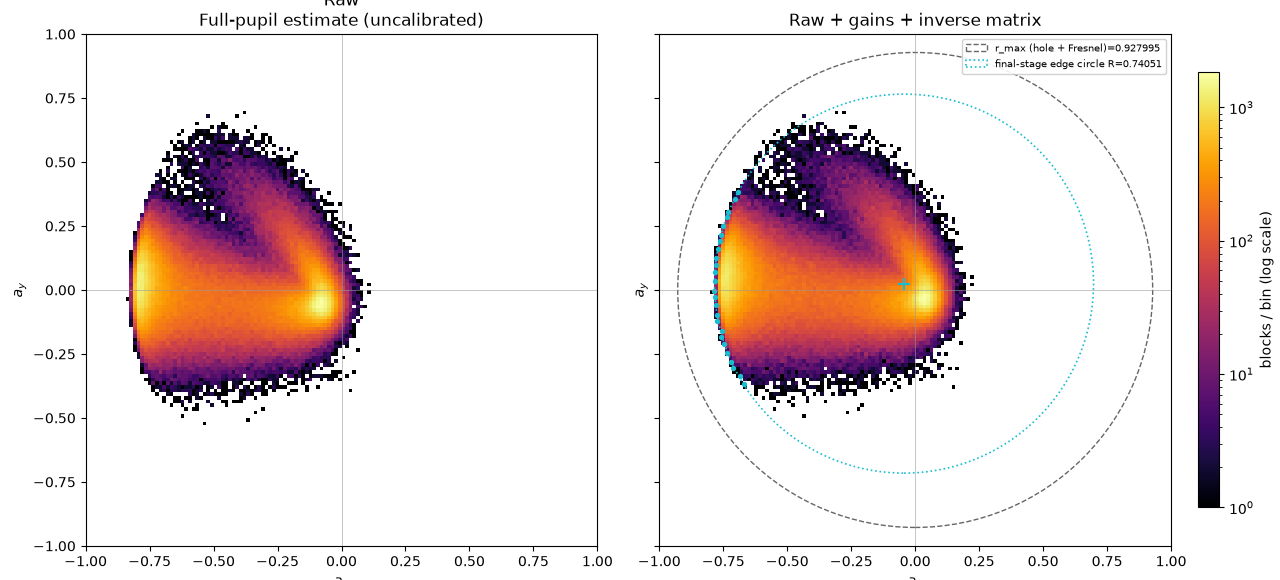

In [119]:
from matplotlib.colors import LogNorm

anisotropy_stages = ('raw', 'fresnel')
anis_limit = 1.0
ANISOTROPY_HISTOGRAMS = {}
for stage, (x_values, y_values, times, rate) in STAGES.items():
    finite = np.isfinite(x_values) & np.isfinite(y_values)
    counts, _, _ = np.histogram2d(
        x_values[finite], y_values[finite], bins=140,
        range=[[-anis_limit, anis_limit], [-anis_limit, anis_limit]],
    )
    ANISOTROPY_HISTOGRAMS[stage] = counts
count_max = max(2, max(counts.max() for counts in ANISOTROPY_HISTOGRAMS.values()))
density_norm = LogNorm(vmin=1, vmax=count_max)
fig, axes = plt.subplots(1, len(anisotropy_stages), figsize=(12.8, 5.8),
                         sharex=True, sharey=True, layout='constrained')
for axis, stage in zip(axes, anisotropy_stages):
    density_image = axis.imshow(
        ANISOTROPY_HISTOGRAMS[stage].T, origin='lower',
        extent=[-anis_limit, anis_limit, -anis_limit, anis_limit],
        norm=density_norm, cmap='inferno', interpolation='nearest',
    )
    if stage != 'raw':
        model_label = 'hole + Fresnel' if stage == 'fresnel' else 'full pupil'
        axis.add_patch(plt.Circle(
            (0, 0), R_MAX_BY_STAGE[stage], fill=False, color='0.4', lw=1, ls='--',
            label=f'r_max ({model_label})={R_MAX_BY_STAGE[stage]:.6f}',
        ))
    if stage == 'fresnel' and rf is not None:
        axis.add_patch(plt.Circle(
            rf['center'], rf['R'], fill=False, color='tab:cyan', lw=1.2, ls=':',
            label=f'final-stage edge circle R={rf["R"]:.5f}',
        ))
        axis.scatter(*rf['center'], marker='+', s=70, color='tab:cyan')
        axis.scatter(rf['edge'][:, 0], rf['edge'][:, 1], s=8, color='tab:cyan')
    if stage != 'raw':
        axis.legend(fontsize=7.5, loc='upper right', facecolor='white', framealpha=0.9)
    axis.axhline(0, color='0.6', lw=0.4)
    axis.axvline(0, color='0.6', lw=0.4)
    axis.set(xlabel='$a_x$', ylabel='$a_y$', aspect='equal',
             xlim=(-1, 1), ylim=(-1, 1),
             title=STAGE_TITLES[stage] if stage == 'raw' else 'Raw + gains + inverse matrix')
fig.colorbar(density_image, ax=axes, label='blocks / bin (log scale)', shrink=0.85, pad=0.01)
plt.show()

## 1a. Time spent in anisotropy space, before choosing regions

This region-free map asks: **how much of the recording was observed at each anisotropy coordinate?** It uses every valid native gain-plus-inverse-matrix sample, with no A/B/C masks or visit selection.

For uniform sampling, a count heat map already contains occupancy information. Here the units are made explicit:

$$T_{ij}=\frac{N_{ij}}{f_s},\qquad f_s=250{,}000\ \mathrm{Hz}.$$

Every native sample contributes **4 us** to one spatial bin. `TIME_MAP_BIN_WIDTH = 0.02` sets equal square bins in anisotropy coordinates; this is **spatial binning**, not temporal averaging or decimation. Zero-count bins are white, and no smoothing or pixel interpolation is applied.

- **Top left:** accumulated seconds per bin on a linear color scale.
- **Top right:** exactly the same seconds per bin on a logarithmic color scale. Log color makes weakly occupied areas more visible and compresses the visual contrast between strongly occupied areas.
- **Bottom left:** accumulated time versus `ax`, summed over all `ay`.
- **Bottom right:** accumulated time versus `ay`, summed over all `ax`.

Each marginal and the 2D map must sum to the same valid recorded time; the cell checks and prints that sum. Invalid photometry is excluded and its time is reported. Between-core samples are retained, and no radius or angular-model cutoff is imposed.

### Why brightness and core percentages can disagree

A compact population can have a high peak per 2D bin, while an extended population spreads substantial time across many bins. Comparing those peaks is not the same as comparing the sum over two regions. The x marginal deliberately collects the full vertical extent, but it also mixes any populations that share an x coordinate; it is not a state assignment.

There was also a sampling difference: the earlier anisotropy overview uses 80 us channel averages, while Test 1 and this map use native 4 us samples. Averaging changes the distribution of intensity ratios. The two panels here avoid that mismatch by displaying the identical native data.

The previous 31.9%/15.9%/1.0% figures were time inside particular provisional ellipses, not total time in the entire central/left/upper-left populations. This map does not use those ellipses, and their definitions remain unchanged pending inspection. Enlarging a region can include passages between configurations and lengthen its uninterrupted visits; this occupancy map alone does not determine kinetic dwell boundaries.

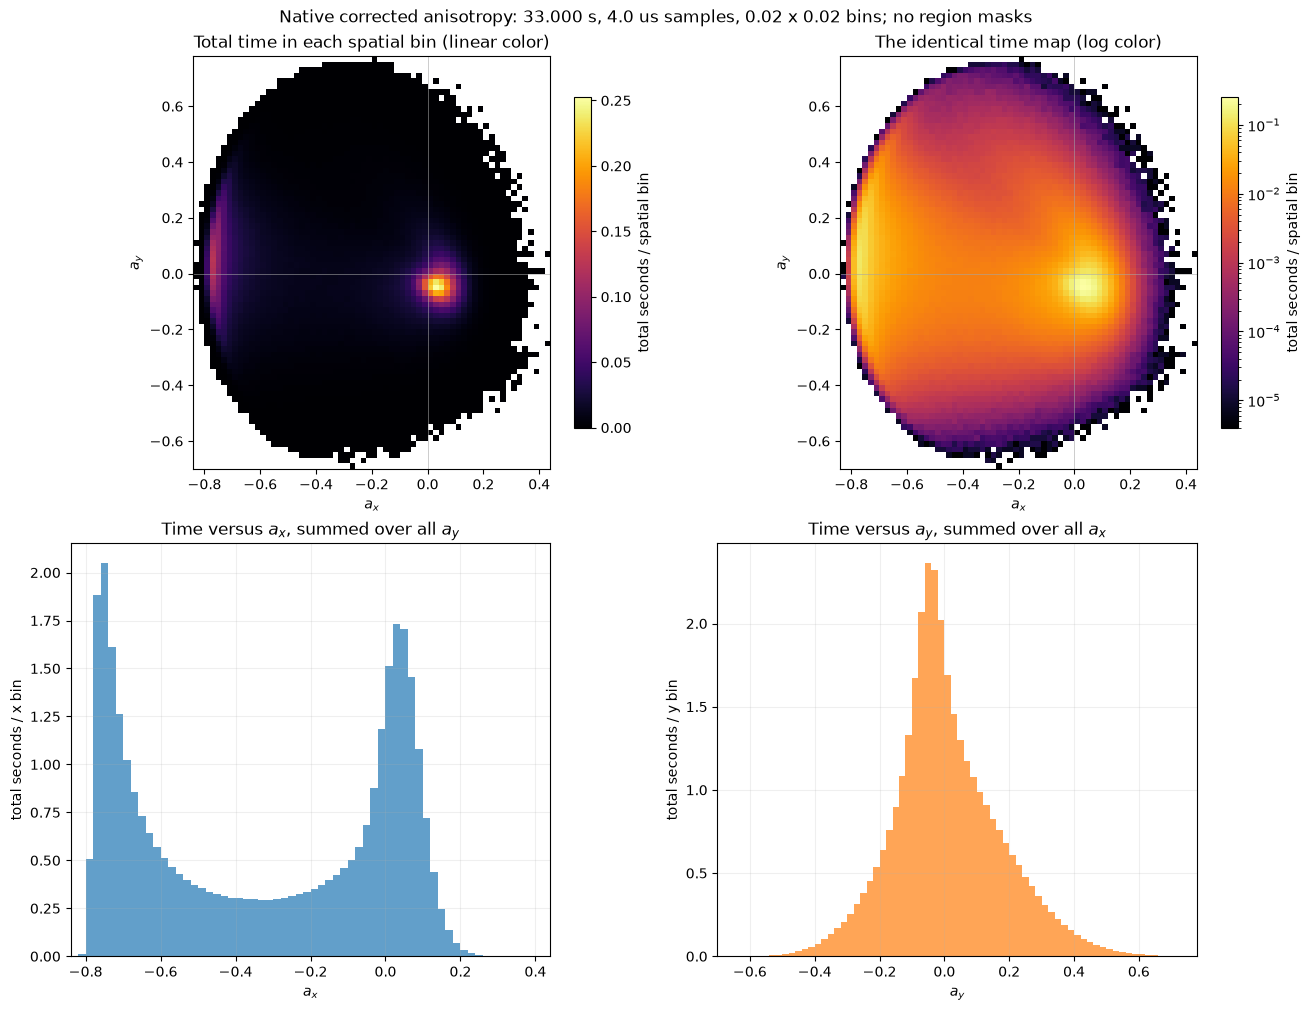

Every valid sample contributes 4.000 us to one bin.
Mapped: 8,250,000 samples = 33.000000 s; invalid photometry excluded: 0 samples = 0.000000 s.
Sum check: 2D=33.000000 s; x marginal=33.000000 s; y marginal=33.000000 s.
No A/B/C masks, minimum visit length, or transition filtering are used. All valid between-core samples are included.
Seconds per bin are total accumulated occupancy, not the length of an individual dwell. Linear/log panels contain identical numbers.


In [81]:
from matplotlib.colors import LogNorm, Normalize

TIME_MAP_BIN_WIDTH = 0.02

def anisotropy_time_map(x_values, y_values, rate, bin_width=0.02, valid=None):
    """Total observed time in equal square anisotropy bins, without core assignments."""
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    if x_values.ndim != 1 or x_values.shape != y_values.shape:
        raise ValueError('Anisotropy arrays must be matching one-dimensional arrays')
    if not np.isfinite(rate) or rate <= 0 or not np.isfinite(bin_width) or bin_width <= 0:
        raise ValueError('rate and bin_width must be positive and finite')
    usable = np.isfinite(x_values) & np.isfinite(y_values)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != usable.shape:
            raise ValueError('valid must match the sample arrays')
        usable &= valid
    if not np.any(usable):
        raise ValueError('No valid samples for the time-spent map')
    selected_x, selected_y = x_values[usable], y_values[usable]
    bin_edges = []
    for values in (selected_x, selected_y):
        lower = int(np.floor(np.min(values) / bin_width))
        upper = max(lower + 1, int(np.ceil(np.max(values) / bin_width)))
        bin_edges.append(np.arange(lower, upper + 1, dtype=float) * bin_width)
    counts, x_edges, y_edges = np.histogram2d(selected_x, selected_y, bins=bin_edges)
    valid_samples = int(np.count_nonzero(usable))
    if int(counts.sum()) != valid_samples:
        raise RuntimeError('The spatial grid did not include every valid sample')
    seconds = counts / rate
    observed_time = valid_samples / rate
    np.testing.assert_allclose(seconds.sum(), observed_time, rtol=1e-12, atol=1e-12)
    return dict(seconds=seconds, counts=counts, x_edges=x_edges, y_edges=y_edges,
                time_by_x=seconds.sum(axis=1), time_by_y=seconds.sum(axis=0),
                valid_samples=valid_samples, excluded_samples=int(len(usable) - valid_samples),
                total_time_s=observed_time, excluded_time_s=float((len(usable) - valid_samples) / rate),
                sample_interval_s=1 / rate, bin_width=bin_width)

time_map_x, time_map_y, time_map_t, time_map_rate, time_map_flags = ha.block_channel_means(
    r1, 1, return_flags=True,
 )
TIME_SPENT_MAP = anisotropy_time_map(
    time_map_x, time_map_y, time_map_rate, bin_width=TIME_MAP_BIN_WIDTH, valid=time_map_flags['valid'],
 )
del time_map_x, time_map_y, time_map_t, time_map_flags

map_seconds = TIME_SPENT_MAP['seconds']
map_extent = [TIME_SPENT_MAP['x_edges'][0], TIME_SPENT_MAP['x_edges'][-1],
              TIME_SPENT_MAP['y_edges'][0], TIME_SPENT_MAP['y_edges'][-1]]
map_nonzero = np.ma.masked_equal(map_seconds.T, 0.)
map_colormap = plt.get_cmap('inferno').copy()
map_colormap.set_bad('white')
map_minimum = TIME_SPENT_MAP['sample_interval_s']
map_maximum = max(float(map_seconds.max()), map_minimum * 1.01)
fig, time_map_axes = plt.subplots(2, 2, figsize=(13, 10), layout='constrained')
for axis, norm, title in (
    (time_map_axes[0, 0], Normalize(vmin=0, vmax=map_maximum), 'Total time in each spatial bin (linear color)'),
    (time_map_axes[0, 1], LogNorm(vmin=map_minimum, vmax=map_maximum), 'The identical time map (log color)'),
):
    time_image = axis.imshow(map_nonzero, origin='lower', extent=map_extent,
                             cmap=map_colormap, norm=norm, interpolation='nearest', aspect='equal')
    axis.set(xlabel='$a_x$', ylabel='$a_y$', title=title)
    axis.axhline(0, color='0.65', lw=.4)
    axis.axvline(0, color='0.65', lw=.4)
    fig.colorbar(time_image, ax=axis, label='total seconds / spatial bin', shrink=.8)

time_map_axes[1, 0].stairs(TIME_SPENT_MAP['time_by_x'], TIME_SPENT_MAP['x_edges'],
                           color='tab:blue', lw=1.5, fill=True, alpha=.7)
time_map_axes[1, 0].set(xlabel='$a_x$', ylabel='total seconds / x bin',
                        title='Time versus $a_x$, summed over all $a_y$', xlim=map_extent[:2])
time_map_axes[1, 1].stairs(TIME_SPENT_MAP['time_by_y'], TIME_SPENT_MAP['y_edges'],
                           color='tab:orange', lw=1.5, fill=True, alpha=.7)
time_map_axes[1, 1].set(xlabel='$a_y$', ylabel='total seconds / y bin',
                        title='Time versus $a_y$, summed over all $a_x$', xlim=map_extent[2:])
for axis in time_map_axes[1]:
    axis.grid(alpha=.2)
fig.suptitle(f'Native corrected anisotropy: {TIME_SPENT_MAP["total_time_s"]:.3f} s, '
             f'{TIME_SPENT_MAP["sample_interval_s"] * 1e6:.1f} us samples, '
             f'{TIME_MAP_BIN_WIDTH:g} x {TIME_MAP_BIN_WIDTH:g} bins; no region masks')
plt.show()

print(f'Every valid sample contributes {TIME_SPENT_MAP["sample_interval_s"] * 1e6:.3f} us to one bin.')
print(f'Mapped: {TIME_SPENT_MAP["valid_samples"]:,} samples = {TIME_SPENT_MAP["total_time_s"]:.6f} s; '
      f'invalid photometry excluded: {TIME_SPENT_MAP["excluded_samples"]:,} samples = {TIME_SPENT_MAP["excluded_time_s"]:.6f} s.')
print(f'Sum check: 2D={map_seconds.sum():.6f} s; x marginal={TIME_SPENT_MAP["time_by_x"].sum():.6f} s; '
      f'y marginal={TIME_SPENT_MAP["time_by_y"].sum():.6f} s.')
print('No A/B/C masks, minimum visit length, or transition filtering are used. All valid between-core samples are included.')
print('Seconds per bin are total accumulated occupancy, not the length of an individual dwell. Linear/log panels contain identical numbers.')

## Current Route Test: O and Annular A/B/C

This is the current route comparison. The ellipse-based analyses and pinned examples below retain their **earlier labels**: their central A is not the A used here. Nothing in this section changes the saved native observations or assigns physical conformational states.

### Spatial Definitions

All radii are measured from the optical origin `(0, 0)`, without subtracting the fitted circle center. `R = rf['R']` supplies a scale only. All angles here are **anisotropy-plane polar bearings** `atan2(ay, ax)`, not the physical azimuth `phi`.

- **O:** `r <= 0.25 R`.
- **Outer annulus:** `0.75 R <= r <= 1.0`. The outer limit is absolute anisotropy radius 1, not `R`.
- **Radial gap:** `0.25 R < r < 0.75 R`; retained as transit space, never filled or relabeled O.
- Before removing the wedges, **A** occupies bearings `0 <= angle < diagonal`, **B** occupies `diagonal <= angle < 180 degrees`, and **C** occupies `180 <= angle < 360 degrees`.
- **trans_AB** and **trans_BC** lie within the outer annulus and have **20 degrees total width**, centered on the upper-left diagonal ray and the negative horizontal ray respectively: 10 degrees on each side. Boundary samples belong to the wedge.

This convention covers the full `2 pi` with three outer sectors: C spans the lower half-plane. The lower-right continuation of the diagonal is shown as a reference, not a fourth-sector boundary. The right-hand A/C boundary is not part of the requested route comparison. The diagonal is the earlier overview-density separator (currently 141.25 degrees); it is not refitted to maximize route differences. `ANNULAR_SEPARATOR_OVERRIDE_DEG` permits an explicit alternative.

### Accepted Routes

Routes use every corrected **native 4 us observation**, with no smoothing, averaging, temporal thinning, nearest-region assignment, or interpolated crossings. An endpoint visit must contain `ANNULAR_MIN_ENDPOINT_US` of consecutive observations in A, B, or C (default **12 us**, three samples). A new committed source visit restarts the passage; short contacts between endpoints are still examined.

- **Via the boundary:** A to B (or reverse) must actually visit trans_AB; B to C (or reverse) must visit trans_BC. Every intervening sample must stay in the two endpoint sectors or their matching wedge. Thus these routes stay in the outer annulus and avoid O, the radial gap, the other wedge, and any third sector.
- **Via O:** A to O to B, or B to O to C, and their reverses, must contain an observed O contact of at least `ANNULAR_MIN_O_US` (default **4 us**, one sample). They may cross the radial gap, but may not visit **either wedge** or any third outer sector.
- Mixed wedge-plus-O routes, wrong-wedge contacts, third-sector detours (even brief ones), radial shortcuts without an observed O visit, and skipped/unobserved gates are excluded. Invalid photometry, samples outside radius 1, and timestamp gaps break the chain. Unfinished departures at the recording end are censored.

The table reports both directions, exclusions, committed visit counts, and sensitivity to 4/12/20/40 us endpoint commitments. **Gate fraction = via_gate / (via_gate + via_O)**, not a fraction of all departures. A zero accepted-route denominator is undefined (`NaN`), not zero probability. Exclusion reasons are mutually prioritized diagnostic counts, not extra accepted events. The browser displays accepted events in chronological order, retaining native sample indices.

These definitions describe observed routes under chosen geometry and commitment rules. They neither establish independent trials nor resolve paths between 4 us samples. Geometry is selected on the same recording, A is sparsely occupied, and results can be strongly threshold-dependent; the counts alone do not prove distinct states or a mandatory physical path through O.

In [105]:
ANNULAR_CORE_FRACTION = 0.25
ANNULAR_INNER_FRACTION = 0.75
ANNULAR_OUTER_RADIUS = 1.0
ANNULAR_GATE_WIDTH_DEG = 20.0
ANNULAR_SEPARATOR_OVERRIDE_DEG = None
ANNULAR_MIN_ENDPOINT_US = 12.0
ANNULAR_MIN_O_US = 4.0
ANNULAR_ENDPOINT_SWEEP_US = (4.0, 12.0, 20.0, 40.0)
ANNULAR_COLORS = {0: '#0072B2', 1: '#CC79A7', 2: '#E69F00', 3: '#009E73',
                  4: '#6F42C1', 5: '#D55E00', -1: '#BBBBBB', -2: '#222222', -3: '#666666'}

if rf is None:
    raise ValueError('Fit the diagnostic circle before constructing the radial zones')
ANNULAR_R = float(rf['R'])
annular_separator_fit = fit_origin_separator(
    STAGES['corrected'][0], STAGES['corrected'][1],
    radial_band=(0.50, 0.75), angle_bounds_deg=(120., 165.), smoothing_deg=3.,
    valid=CHANNEL_FLAGS['corrected']['valid'],
 )
ANNULAR_SEPARATOR_DEG = (annular_separator_fit['angle_deg'] if ANNULAR_SEPARATOR_OVERRIDE_DEG is None
                         else float(ANNULAR_SEPARATOR_OVERRIDE_DEG))
annular_x, annular_y, annular_times, annular_rate, annular_flags = block_channel_means(
    r1, 1, return_flags=True,
 )
ANNULAR_ZONES = classify_annular_zones(
    annular_x, annular_y, ANNULAR_R, ANNULAR_SEPARATOR_DEG,
    core_fraction=ANNULAR_CORE_FRACTION, inner_fraction=ANNULAR_INNER_FRACTION,
    outer_radius=ANNULAR_OUTER_RADIUS, gate_width_deg=ANNULAR_GATE_WIDTH_DEG,
    valid=annular_flags['valid'],
 )
ANNULAR_LABELS = ANNULAR_ZONES['labels']
annular_valid_count = int(np.count_nonzero(ANNULAR_LABELS != -2))
ANNULAR_OCCUPANCY = {}
for code, name in ANNULAR_ZONES['names'].items():
    count = int(np.count_nonzero(ANNULAR_LABELS == code))
    ANNULAR_OCCUPANCY[name] = dict(samples=count, seconds=count / annular_rate,
                                   fraction_valid=count / annular_valid_count if code != -2 and annular_valid_count else np.nan)
assert sum(row['samples'] for row in ANNULAR_OCCUPANCY.values()) == len(ANNULAR_LABELS)

def annular_duration_samples(duration_us, rate):
    if not np.isfinite(duration_us) or duration_us <= 0:
        raise ValueError('Minimum durations must be positive and finite')
    return max(1, int(np.ceil(duration_us * 1e-6 * rate - 1e-10)))

annular_endpoint_samples = annular_duration_samples(ANNULAR_MIN_ENDPOINT_US, annular_rate)
annular_o_samples = annular_duration_samples(ANNULAR_MIN_O_US, annular_rate)
ANNULAR_ROUTES = count_annular_routes(
    ANNULAR_LABELS, annular_times, annular_rate,
    min_endpoint_samples=annular_endpoint_samples, min_o_samples=annular_o_samples,
 )
print('NEW sector labels: O=center; A=upper annulus; B=upper-left sector below diagonal; C=lower annulus.')
print('These A/B/C labels are NOT the earlier ellipse definitions. Radii and bearings are measured from (0,0).')
print(f"Fitted R={ANNULAR_R:.6f}; O radius={ANNULAR_ZONES['core_radius']:.6f}; "
      f"annulus inner={ANNULAR_ZONES['inner_radius']:.6f}, outer={ANNULAR_OUTER_RADIUS:.6f} (absolute anisotropy radius).")
print(f'Separator={ANNULAR_SEPARATOR_DEG:.2f} deg, inferred from the corrected overview; horizontal B/C boundary=180 deg.')
print(f'Transition wedges have TOTAL width {ANNULAR_GATE_WIDTH_DEG:g} deg (half on each side of their boundary).')
print(f'Native observations: {len(annular_times):,} at {1e6 / annular_rate:.3f} us; no smoothing or decimation.')
if not annular_separator_fit['interior_minimum'] and ANNULAR_SEPARATOR_OVERRIDE_DEG is None:
    print('WARNING: separator is not an interior density minimum; inspect or set the explicit angle override.')
print(f'{"zone":>12} {"samples":>12} {"seconds":>12} {"valid time %":>14}')
for name, row in ANNULAR_OCCUPANCY.items():
    print(f'{name:>12} {row["samples"]:12,d} {row["seconds"]:12.6f} {100 * row["fraction_valid"]:14.3f}')
print(f'Endpoint commitment={annular_endpoint_samples / annular_rate * 1e6:.1f} us; O contact minimum={annular_o_samples / annular_rate * 1e6:.1f} us; one observed wedge sample is required.')
print('No ellipse labels, origin shift, Fourkas-angle cutoff, or interpolated gate crossing is used in this route test.')

NEW sector labels: O=center; A=upper annulus; B=upper-left sector below diagonal; C=lower annulus.
These A/B/C labels are NOT the earlier ellipse definitions. Radii and bearings are measured from (0,0).
Fitted R=0.740514; O radius=0.185129; annulus inner=0.555386, outer=1.000000 (absolute anisotropy radius).
Separator=141.25 deg, inferred from the corrected overview; horizontal B/C boundary=180 deg.
Transition wedges have TOTAL width 20 deg (half on each side of their boundary).
Native observations: 8,250,000 at 4.000 us; no smoothing or decimation.
        zone      samples      seconds   valid time %
           O    3,003,264    12.013056         36.403
           A       31,948     0.127792          0.387
           B      942,597     3.770388         11.425
           C      611,848     2.447392          7.416
    trans_AB      146,445     0.585780          1.775
    trans_BC    1,542,313     6.169252         18.695
  radial_gap    1,971,585     7.886340         23.898
     invalid

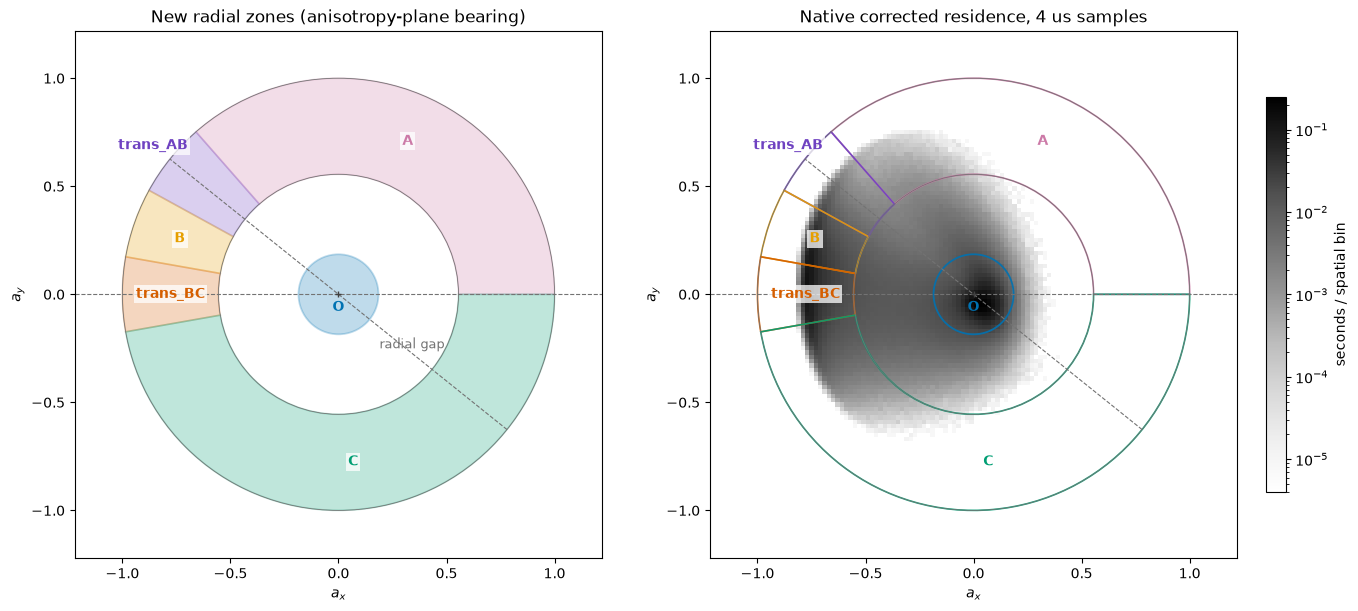


PRIMARY ROUTE COMPARISON
Consecutive endpoint commitment: 12 us; O contact: 4 us.
 direction   via gate      via O   excluded   gate % kept   kept % cand.
      A->B         31         99      1,156        23.846         10.109
      B->A         23         95      1,202        19.492          8.939
      B->C     14,891        199     17,113        98.681         46.859
      C->B     14,782        219     17,236        98.540         46.533
gate % kept = via_gate / (via_gate + via_O); exclusions are not in this denominator.
All contacts are observed samples, not inferred continuous paths. The 4 us sampling can miss crossings.
Committed endpoint visits: {'A': 3724, 'B': 121689, 'C': 74570}
Same-sector returns: 130894 ; A/C committed pairs (not a requested comparison): 2042
Chain breaks before a destination could be assigned: {'invalid': 0, 'outside': 0, 'time_gap': 0, 'record_end': 1}

EXCLUDED CANDIDATES (one primary reason per candidate)
A->B {'other_transition_wedge': 408, 'third_

In [107]:
def draw_annular_geometry(axis, zones, colors, *, fill=False, labels=True):
    from matplotlib.patches import Circle, Wedge
    outer = zones['outer_radius']
    inner = zones['inner_radius']
    core = zones['core_radius']
    boundary = zones['separator_deg']
    half_width = zones['gate_width_deg'] / 2
    sectors = ((1, 0., boundary - half_width),
               (4, boundary - half_width, boundary + half_width),
               (2, boundary + half_width, 180. - half_width),
               (5, 180. - half_width, 180. + half_width),
               (3, 180. + half_width, 360.))
    for code, lower, upper in sectors:
        axis.add_patch(Wedge((0, 0), outer, lower, upper, width=outer - inner,
                             facecolor=colors[code] if fill else 'none',
                             edgecolor=colors[code], linewidth=1.2, alpha=.25 if fill else .9))
        if labels:
            angle = np.radians((lower + upper) / 2)
            label_radius = outer + .10 if code == 4 else (inner + outer) / 2
            axis.text(label_radius * np.cos(angle), label_radius * np.sin(angle),
                      zones['names'][code], ha='center', va='center', fontsize=10,
                      color=colors[code], fontweight='bold',
                      bbox=dict(facecolor='white', edgecolor='none', alpha=.75, pad=1.5))
    axis.add_patch(Circle((0, 0), core, facecolor=colors[0] if fill else 'none',
                          edgecolor=colors[0], linewidth=1.3, alpha=.25 if fill else .9))
    for radius in (inner, outer):
        axis.add_patch(Circle((0, 0), radius, fill=False, edgecolor='0.45', lw=.6))
    diagonal = np.array([np.cos(np.radians(boundary)), np.sin(np.radians(boundary))])
    axis.plot([-outer * diagonal[0], outer * diagonal[0]],
              [-outer * diagonal[1], outer * diagonal[1]], '--', color='0.45', lw=.8)
    axis.axhline(0, color='0.45', linestyle='--', lw=.8)
    axis.plot(0, 0, '+', color='0.25', ms=5)
    if labels:
        axis.text(0, -.06, 'O', ha='center', va='center', color=colors[0], fontweight='bold')
        if fill:
            axis.text(.34, -.25, 'radial gap', ha='center', color='0.45', fontsize=9)
    limit = outer * 1.22
    axis.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel='$a_x$', ylabel='$a_y$')
    axis.set_aspect('equal')
    return axis

annular_figure, annular_axes = plt.subplots(1, 2, figsize=(13.5, 6), layout='constrained')
draw_annular_geometry(annular_axes[0], ANNULAR_ZONES, ANNULAR_COLORS, fill=True)
annular_axes[0].set_title('New radial zones (anisotropy-plane bearing)')
annular_map = np.ma.masked_equal(TIME_SPENT_MAP['seconds'].T, 0.)
annular_extent = [TIME_SPENT_MAP['x_edges'][0], TIME_SPENT_MAP['x_edges'][-1],
                  TIME_SPENT_MAP['y_edges'][0], TIME_SPENT_MAP['y_edges'][-1]]
annular_image = annular_axes[1].imshow(
    annular_map, origin='lower', extent=annular_extent, cmap='Greys', interpolation='nearest',
    norm=LogNorm(vmin=1 / annular_rate, vmax=max(float(annular_map.max()), 1.01 / annular_rate)),
 )
draw_annular_geometry(annular_axes[1], ANNULAR_ZONES, ANNULAR_COLORS)
annular_axes[1].set_title(f'Native corrected residence, {1e6 / annular_rate:g} us samples')
annular_figure.colorbar(annular_image, ax=annular_axes[1], label='seconds / spatial bin', shrink=.75)
plt.show()

def annular_route_rows(result):
    rows = []
    for direction, counts in result['counts'].items():
        gate_count, o_count = counts['via_gate'], counts['via_O']
        kept = gate_count + o_count
        rejected = sum(result['excluded'][direction].values())
        rows.append(dict(direction=direction, via_gate=gate_count, via_O=o_count,
                         valid_routes=kept, excluded=rejected, candidates=kept + rejected,
                         gate_fraction=gate_count / kept if kept else np.nan,
                         valid_fraction=kept / (kept + rejected) if kept + rejected else np.nan))
    return rows

print('\nPRIMARY ROUTE COMPARISON')
print(f'Consecutive endpoint commitment: {ANNULAR_ROUTES["min_endpoint_s"] * 1e6:g} us; '
      f'O contact: {ANNULAR_ROUTES["min_o_s"] * 1e6:g} us.')
print(f'{"direction":>10} {"via gate":>10} {"via O":>10} {"excluded":>10} {"gate % kept":>13} {"kept % cand.":>14}')
for annular_row in annular_route_rows(ANNULAR_ROUTES):
    print(f'{annular_row["direction"]:>10} {annular_row["via_gate"]:10,d} {annular_row["via_O"]:10,d} '
          f'{annular_row["excluded"]:10,d} {100 * annular_row["gate_fraction"]:13.3f} '
          f'{100 * annular_row["valid_fraction"]:14.3f}')
print('gate % kept = via_gate / (via_gate + via_O); exclusions are not in this denominator.')
print('All contacts are observed samples, not inferred continuous paths. The 4 us sampling can miss crossings.')
print('Committed endpoint visits:', ANNULAR_ROUTES['endpoint_visits'])
print('Same-sector returns:', ANNULAR_ROUTES['same_sector_returns'],
      '; A/C committed pairs (not a requested comparison):', ANNULAR_ROUTES['unsupported_pairs'])
print('Chain breaks before a destination could be assigned:', ANNULAR_ROUTES['chain_breaks'])
print('\nEXCLUDED CANDIDATES (one primary reason per candidate)')
for annular_direction, annular_reasons in ANNULAR_ROUTES['excluded'].items():
    print(annular_direction, annular_reasons)

ANNULAR_ROUTE_SWEEP = []
for annular_threshold_us in ANNULAR_ENDPOINT_SWEEP_US:
    annular_threshold_samples = annular_duration_samples(annular_threshold_us, annular_rate)
    annular_sweep_result = (ANNULAR_ROUTES if annular_threshold_samples == annular_endpoint_samples
                            else count_annular_routes(
                                ANNULAR_LABELS, annular_times, annular_rate,
                                min_endpoint_samples=annular_threshold_samples, min_o_samples=annular_o_samples))
    for annular_row in annular_route_rows(annular_sweep_result):
        ANNULAR_ROUTE_SWEEP.append(dict(endpoint_us=annular_threshold_samples / annular_rate * 1e6, **annular_row))
del annular_sweep_result
print('\nENDPOINT-COMMITMENT SENSITIVITY (same geometry; O and wedge requirements unchanged)')
print(f'{"endpoint us":>12} {"direction":>10} {"via gate":>10} {"via O":>10} {"excluded":>10} {"gate % kept":>13}')
for annular_row in ANNULAR_ROUTE_SWEEP:
    print(f'{annular_row["endpoint_us"]:12.1f} {annular_row["direction"]:>10} '
          f'{annular_row["via_gate"]:10,d} {annular_row["via_O"]:10,d} '
          f'{annular_row["excluded"]:10,d} {100 * annular_row["gate_fraction"]:13.3f}')
print('These are descriptive route counts, not independent trials, state populations, or fitted kinetic rates.')

In [108]:
from ipywidgets import Dropdown, IntSlider, HBox, VBox, Output, Layout
from IPython.display import display

ANNULAR_CONTEXT_US = 100.0
ANNULAR_ACCEPTED_EVENTS = {
    (direction, route): [event for event in ANNULAR_ROUTES['events']
                         if event['direction'] == direction and event['route'] == route]
    for direction in ANNULAR_ROUTES['counts'] for route in ('via_gate', 'via_O')
}

def show_annular_route(route_choice=('A->B', 'via_O'), event_number=1):
    events = ANNULAR_ACCEPTED_EVENTS[route_choice]
    if not events:
        print(f'{route_choice[0]}, {route_choice[1]}: no accepted events at the selected commitment.')
        return
    if not 1 <= event_number <= len(events):
        raise ValueError('event_number is outside this route category')
    event = events[event_number - 1]
    start, end = event['start_idx'], event['end_idx']
    context = annular_duration_samples(ANNULAR_CONTEXT_US, annular_rate)
    context_start, context_stop = max(0, start - context), min(len(annular_times), end + context + 1)
    context_indices = np.arange(context_start, context_stop)
    path_indices = np.arange(start, end + 1)
    elapsed = (annular_times[context_indices] - annular_times[start]) * 1e6
    passage_us = (annular_times[path_indices] - annular_times[start]) * 1e6
    passage_duration = event['duration_s'] * 1e6
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout='constrained')
    draw_annular_geometry(axes[0], ANNULAR_ZONES, ANNULAR_COLORS, fill=True, labels=False)
    axes[0].scatter(annular_x[context_indices], annular_y[context_indices], s=8, color='0.65', alpha=.4)
    path_points = axes[0].scatter(annular_x[path_indices], annular_y[path_indices],
                                  c=passage_us, s=22, cmap='viridis', zorder=4)
    axes[0].scatter(annular_x[start], annular_y[start], marker='s', s=90,
                    facecolors='none', edgecolors='black', linewidths=1.2, label='last source sample', zorder=5)
    axes[0].scatter(annular_x[end], annular_y[end], marker='D', s=90,
                    facecolors='none', edgecolors='black', linewidths=1.2, label='first destination sample', zorder=5)
    axes[0].legend(loc='lower right', fontsize=8)
    axes[0].set_title('Native observations; no interpolated crossing')
    figure.colorbar(path_points, ax=axes[0], orientation='horizontal',
                     label='us after last source sample', shrink=.85, pad=.02)
    radius = np.hypot(annular_x[context_indices], annular_y[context_indices])
    axes[1].plot(elapsed, radius, '.-', color='0.25', lw=.7, ms=3, label='origin distance')
    for name, boundary, color in (('O edge', ANNULAR_ZONES['core_radius'], ANNULAR_COLORS[0]),
                                  ('annulus inner', ANNULAR_ZONES['inner_radius'], '0.5'),
                                  ('outer limit', ANNULAR_ZONES['outer_radius'], '0.7')):
        axes[1].axhline(boundary, color=color, ls='--', lw=.8, label=name)
    axes[1].set(ylabel='anisotropy radius', title='Native radial contacts')
    axes[1].legend(fontsize=8, loc='best')
    context_labels = ANNULAR_LABELS[context_indices]
    axes[2].step(elapsed, context_labels, where='post', color='0.7', lw=.8)
    axes[2].scatter(elapsed, context_labels, s=16,
                    c=[ANNULAR_COLORS[int(code)] for code in context_labels], zorder=3)
    displayed_codes = sorted(set(context_labels) | {0, 1, 2, 3, 4, 5, -1})
    axes[2].set(yticks=displayed_codes,
                yticklabels=[ANNULAR_ZONES['names'][code] for code in displayed_codes],
                title='All observed zone labels')
    for axis in axes[1:]:
        axis.axvspan(0, passage_duration, color='0.8', alpha=.25)
        axis.set(xlabel='us after last source sample', xlim=(elapsed[0], elapsed[-1]))
        axis.grid(alpha=.15)
    route_name = ANNULAR_ZONES['names'][event['gate_code']] if event['route'] == 'via_gate' else 'O'
    figure.suptitle(f'{event["direction"]} via {route_name}; event {event_number}/{len(events)}; '
                    f'{annular_times[start]:.6f}-{annular_times[end]:.6f} s')
    plt.show()
    print(f'Native indices {start}..{end} inclusive; {len(path_indices)} observations, sampled span {passage_duration:.1f} us.')
    print(f'Source/destination consecutive visits: {event["source_samples"] / annular_rate * 1e6:g}/'
          f'{event["destination_samples"] / annular_rate * 1e6:g} us; '
          f'longest O contact: {event["max_o_run_samples"] / annular_rate * 1e6:g} us.')

annular_choices = [(f'{direction} {route} ({len(events):,})', (direction, route))
                    for (direction, route), events in ANNULAR_ACCEPTED_EVENTS.items()]
annular_route_selector = Dropdown(options=annular_choices, value=('A->B', 'via_O'),
                                   description='Route', layout=Layout(width='320px'))
annular_event_slider = IntSlider(value=1, min=1,
                                 max=max(1, len(ANNULAR_ACCEPTED_EVENTS[annular_route_selector.value])),
                                 continuous_update=False, description='Event', layout=Layout(width='360px'))
annular_browser_output = Output()

def refresh_annular_browser(change=None):
    if change is not None and change['owner'] is annular_route_selector:
        with annular_event_slider.hold_trait_notifications():
            annular_event_slider.max = max(1, len(ANNULAR_ACCEPTED_EVENTS[annular_route_selector.value]))
            annular_event_slider.value = 1
    annular_event_slider.disabled = not ANNULAR_ACCEPTED_EVENTS[annular_route_selector.value]
    with annular_browser_output:
        annular_browser_output.clear_output(wait=True)
        show_annular_route(annular_route_selector.value, annular_event_slider.value)

annular_route_selector.observe(refresh_annular_browser, names='value')
annular_event_slider.observe(refresh_annular_browser, names='value')
ANNULAR_BROWSER = VBox([HBox([annular_route_selector, annular_event_slider],
                              layout=Layout(flex_flow='row wrap')), annular_browser_output])
display(ANNULAR_BROWSER)
refresh_annular_browser()

## 1b. Center-to-radius excursions: exploratory route test

The working question is **whether excursions from one central population leave along repeatable corridors**, without requiring the same outer endpoint. That differs from two alternate routes connecting the same two dwell states. No number of branches or physical states is imposed here.

### Gates and event definition

The target is a **fraction of the fitted circle's radius**, not a percentile of observed points:

$$\rho(t)=\frac{\|\mathbf a(t)-\mathbf c_{\mathrm{rim}}\|}{R},\qquad \rho_{\mathrm{target}}=0.80.$$

The original corrected anisotropy coordinates are retained. The fitted center is used only to measure radial progress and bearing; no centering is applied to the signals or optical reconstruction.

- `ROUTE_CENTER_XY = None` locates the most populated histogram region within `0.30 R` of the fitted center, using a one-bin Gaussian smoothing of **density only**. A coordinate pair overrides it. Inspect the orange central disk before interpreting results.
- `ROUTE_CORE_FRACTION = 0.12` sets the central disk radius, about its own population center. `ROUTE_TARGET_FRACTION = 0.80` sets the target circle radius, about the fitted rim center.
- A run of `ROUTE_CORE_RESIDENCE_S` worth of consecutive core blocks arms an excursion. Its recorded path begins at the **last core sample**, and ends at the first sample of a run that stays outside the target for `ROUTE_OUTER_RESIDENCE_S`. Counts are rounded up to whole blocks; these are residence checks, not smoothing.
- Returning to the core before a confirmed exit aborts the attempt. A fresh confirmed core visit is needed before another completed passage can be counted. Isolated target recrossings do not count as separate passages.
- Invalid photometry, time gaps, and unfinished paths at the file end censor attempts; no paths are joined across them. The angle-inversion validity mask is not used to impose a geometric cutoff.
- `ROUTE_MIN_PATH_SAMPLES = 5` marks passages with enough samples for a basic route profile. This is only a sampling screen, not proof that the motion between observations was resolved. Short passages are retained and counted, and their target bearings remain visible.

### Outputs and controls

1. **Geometry and route profiles:** the core and target overlaid on corrected data, example time-spread passages, and bearing distributions at intermediate gates and the target. Each passage contributes once per gate; slow trajectories do not receive extra weight. Interior gates use their first outward crossing; the final gate uses the confirmed outer crossing.
2. **Time checks:** target bearings versus departure time and distributions in the two recording halves. These reveal drift or time-localised populations, but are not independent validation after choosing settings from the same recording.
3. **Sensitivity sweep:** independently re-detect passages to `0.50 R`, `0.65 R`, and `0.80 R` at half, current, and twice the integration interval. The central region and fitted circle are held fixed. A shorter upper-left excursion can be missing at `0.80 R` while visible at a smaller target.
4. **Event browser:** sort by exit bearing or departure time to inspect individual paths, `ax(t)`/`ay(t)`, and gate distances. Lines join observed adjacent samples only; they are not a reconstructed continuous trajectory. Change the target and rerun the route cells to browse smaller excursions.

Crossings are interpolated on adjacent sample segments. Their **bearing is an anisotropy-plane angle**, with 90 degrees upward and 180 degrees leftward around the fitted center, not the rod azimuth phi. Display histograms use 5-degree bins and circular one-bin smoothing; paths and event detection are unsmoothed. The printed 90-150-degree sector is descriptive and is not a fitted branch label.

### Interpretation limits

A wide density stripe can reflect noise, route variability, unresolved fast motion, or several corridors. Two corridors would need repeated separation at comparable radial progress and persistence under reasonable gate and sampling changes. A separate density lobe may instead be an intermediate dwell region or a shorter excursion. The profile plot restricted to `0.80 R` passages is conditional on reaching that radius; it cannot rule out those alternatives.

The sweep also exposes detection bias: block averaging changes both noise and residence confirmation, so passage counts across resolutions are not automatically physical transition rates. Formal evidence for two pathways would additionally require a calibrated one-corridor noise/dynamics null model, gate-sensitivity checks, and held-out or independent data. This section does not claim such a significance test or resolve 3D pole-crossing degeneracy.

In [82]:
from scipy.ndimage import gaussian_filter

ROUTE_CENTER_XY = None
ROUTE_CORE_FRACTION = 0.12
ROUTE_TARGET_FRACTION = 0.80
ROUTE_CORE_RESIDENCE_S = 0.00024
ROUTE_OUTER_RESIDENCE_S = 0.00024
ROUTE_MIN_PATH_SAMPLES = 5

if rf is None:
    raise ValueError('Run the corrected-data circle fit before the route diagnostic')
route_circle_center = np.asarray(rf['center'], dtype=float)
route_circle_radius = float(rf['R'])
route_x, route_y, route_times, route_rate = STAGES['corrected']
route_valid = CHANNEL_FLAGS['corrected']['valid'] & np.isfinite(route_x) & np.isfinite(route_y)
if ROUTE_CENTER_XY is None:
    search_halfwidth = 0.30 * route_circle_radius
    near_center = route_valid & (np.hypot(route_x - route_circle_center[0],
                                          route_y - route_circle_center[1]) < search_halfwidth)
    if near_center.sum() < 5:
        raise ValueError('Too few central samples; set ROUTE_CENTER_XY to the intended central population')
    core_counts, core_x_edges, core_y_edges = np.histogram2d(
        route_x[near_center], route_y[near_center], bins=41,
        range=[route_circle_center[0] + np.array([-1, 1]) * search_halfwidth,
               route_circle_center[1] + np.array([-1, 1]) * search_halfwidth],
    )
    core_mode = np.unravel_index(np.argmax(gaussian_filter(core_counts, sigma=1.0)), core_counts.shape)
    route_core_center = np.array([
        0.5 * (core_x_edges[core_mode[0]] + core_x_edges[core_mode[0] + 1]),
        0.5 * (core_y_edges[core_mode[1]] + core_y_edges[core_mode[1] + 1]),
    ])
else:
    route_core_center = np.asarray(ROUTE_CENTER_XY, dtype=float)

def route_residence_samples(residence_s, rate):
    if not np.isfinite(residence_s) or residence_s <= 0:
        raise ValueError('Route residence times must be positive and finite')
    return max(1, int(np.ceil(residence_s * rate - 1e-10)))

if (isinstance(ROUTE_MIN_PATH_SAMPLES, bool) or int(ROUTE_MIN_PATH_SAMPLES) != ROUTE_MIN_PATH_SAMPLES
        or ROUTE_MIN_PATH_SAMPLES < 2):
    raise ValueError('ROUTE_MIN_PATH_SAMPLES must be an integer >= 2')
ROUTE_RESULTS = ha.extract_radial_excursions(
    route_x, route_y, route_times, route_circle_center, route_circle_radius,
    core_center=route_core_center, core_fraction=ROUTE_CORE_FRACTION,
    outer_fraction=ROUTE_TARGET_FRACTION, valid=route_valid,
    min_core_samples=route_residence_samples(ROUTE_CORE_RESIDENCE_S, route_rate),
    min_outer_samples=route_residence_samples(ROUTE_OUTER_RESIDENCE_S, route_rate),
 )
core_outer_fraction = np.linalg.norm(route_core_center - route_circle_center) / route_circle_radius + ROUTE_CORE_FRACTION
first_profile_fraction = max(ROUTE_TARGET_FRACTION / 2,
                             core_outer_fraction + 0.1 * (ROUTE_TARGET_FRACTION - core_outer_fraction))
ROUTE_PROFILE_FRACTIONS = np.linspace(first_profile_fraction, ROUTE_TARGET_FRACTION, 3)
ROUTE_PROFILES = ha.radial_crossing_profiles(
    route_x, route_y, route_times, ROUTE_RESULTS, route_circle_center,
    route_circle_radius, ROUTE_PROFILE_FRACTIONS,
 )
route_durations = np.array([event['duration_s'] for event in ROUTE_RESULTS['paths']])
route_sample_counts = np.array([event['n_samples'] for event in ROUTE_RESULTS['paths']], dtype=int)
route_start_times = np.array([route_times[event['start_idx']] for event in ROUTE_RESULTS['paths']])
route_profile_complete = np.all(np.isfinite(ROUTE_PROFILES['bearing_deg']), axis=1)
route_resolved = (route_sample_counts >= ROUTE_MIN_PATH_SAMPLES) & route_profile_complete

print(f'Central disk: center=({route_core_center[0]:+.4f}, {route_core_center[1]:+.4f}), '
      f'radius={ROUTE_RESULTS["core_radius"]:.4f} ({ROUTE_CORE_FRACTION:.0%} of fitted R)')
print(f'Target: distance from fitted center >= {ROUTE_TARGET_FRACTION:.0%} of R = {ROUTE_RESULTS["outer_radius"]:.4f}')
print(f'Residence checks: core {route_residence_samples(ROUTE_CORE_RESIDENCE_S, route_rate)} blocks; '
      f'outer {route_residence_samples(ROUTE_OUTER_RESIDENCE_S, route_rate)} blocks @ {route_rate:.1f} Hz')
print(f'Attempts={ROUTE_RESULTS["attempts"]:,}; confirmed passages={len(route_durations):,}; '
      f'core returns before confirmation={ROUTE_RESULTS["aborted"]:,}; censored={ROUTE_RESULTS["censored"]:,}')
print(f'Invalid samples={ROUTE_RESULTS["invalid_samples"]:,}; time gaps={ROUTE_RESULTS["time_gaps"]:,}')
print(f'Profile-qualified passages: {route_resolved.sum():,}; fewer than {ROUTE_MIN_PATH_SAMPLES} path samples: '
      f'{(route_sample_counts < ROUTE_MIN_PATH_SAMPLES).sum():,}; missing gate crossings: {(~route_profile_complete).sum():,}')
if len(route_durations):
    print(f'Passage duration median={np.median(route_durations) * 1e3:.3f} ms; '
          f'10th/90th percentiles={np.percentile(route_durations, [10, 90]) * 1e3} ms')
print('Bearing is in the anisotropy plane around the fitted center: 90 deg = up, 180 deg = left; NOT rod phi.')
print('No branch count or branch labels are fitted. Profile qualification is a sampling check, not proof of physical resolution.')

Central disk: center=(+0.0323, -0.0293), radius=0.0889 (12% of fitted R)
Target: distance from fitted center >= 80% of R = 0.5924
Residence checks: core 3 blocks; outer 3 blocks @ 12500.0 Hz
Attempts=9,886; confirmed passages=2,619; core returns before confirmation=7,267; censored=0
Invalid samples=0; time gaps=0
Profile-qualified passages: 1,366; fewer than 5 path samples: 1,253; missing gate crossings: 0
Passage duration median=0.320 ms; 10th/90th percentiles=[0.16 0.72] ms
Bearing is in the anisotropy plane around the fitted center: 90 deg = up, 180 deg = left; NOT rod phi.
No branch count or branch labels are fitted. Profile qualification is a sampling check, not proof of physical resolution.


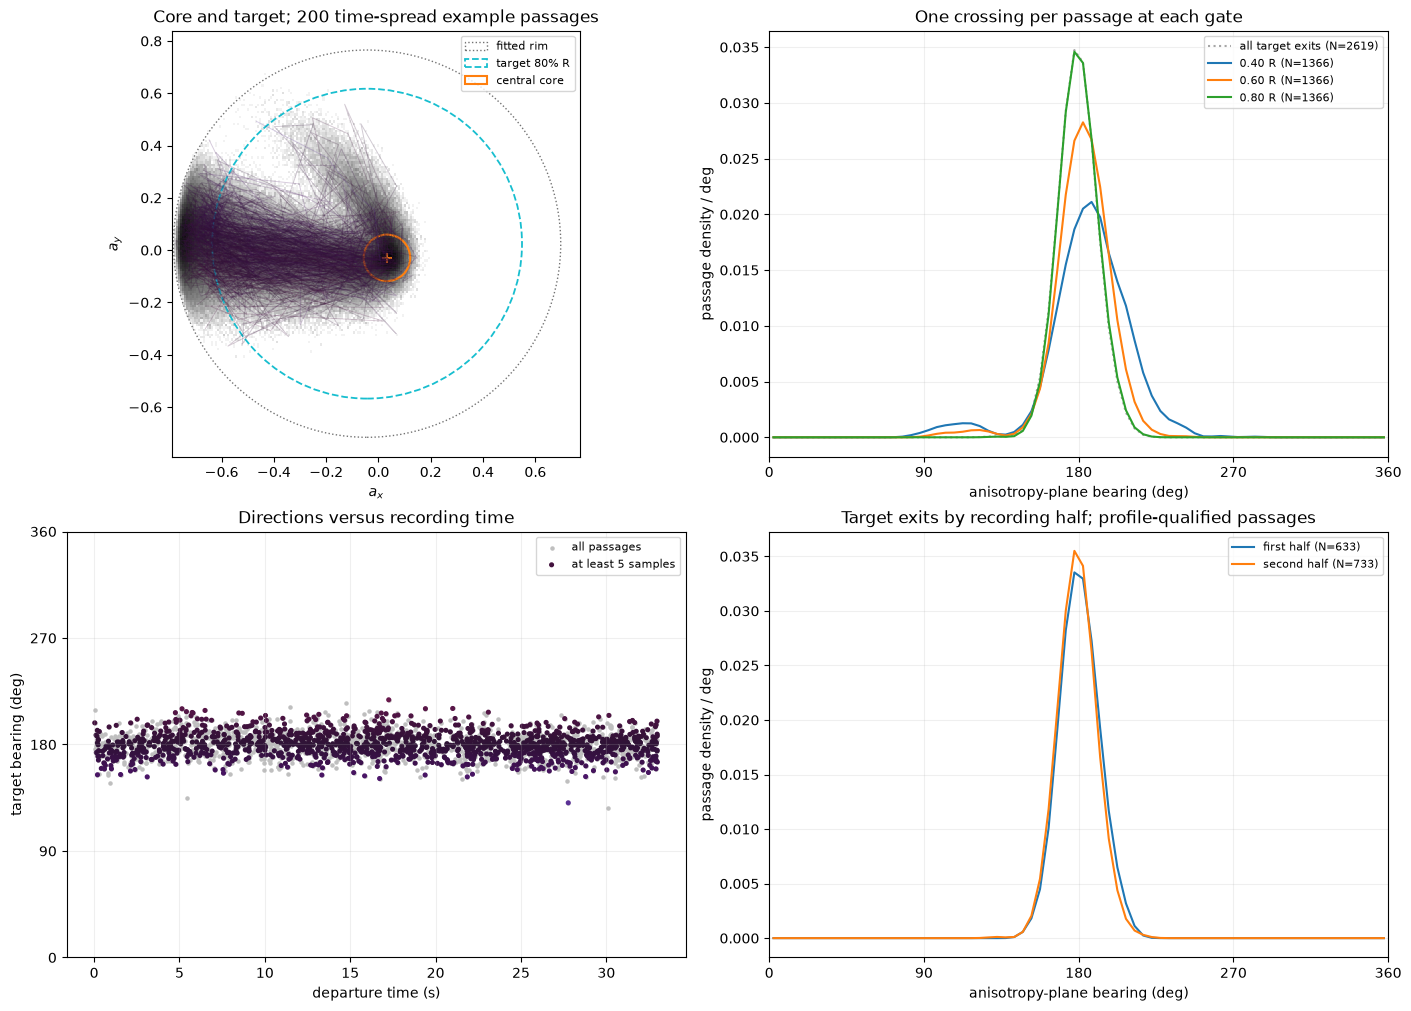

Bearing histograms use 5-degree bins with circular one-bin display smoothing; paths themselves are unsmoothed.
Every passage contributes once at each gate; no two-branch partition or significance test is imposed.


In [83]:
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d

ROUTE_ANGLE_EDGES = np.linspace(0, 360, 73)
route_angle_centers = 0.5 * (ROUTE_ANGLE_EDGES[:-1] + ROUTE_ANGLE_EDGES[1:])
route_bearings = ROUTE_PROFILES['bearing_deg']
route_exit_bearing = route_bearings[:, -1]
route_examples = np.flatnonzero(route_resolved)
if len(route_examples) > 200:
    route_examples = route_examples[np.linspace(0, len(route_examples) - 1, 200).astype(int)]
route_colors = plt.get_cmap('twilight')

def route_bearing_density(angles):
    angles = np.asarray(angles, dtype=float)
    angles = angles[np.isfinite(angles)] % 360
    counts, _ = np.histogram(angles, bins=ROUTE_ANGLE_EDGES)
    if len(angles) == 0:
        return np.zeros_like(route_angle_centers)
    return gaussian_filter1d(counts.astype(float), sigma=1, mode='wrap') / (len(angles) * np.diff(ROUTE_ANGLE_EDGES))

fig, route_axes = plt.subplots(2, 2, figsize=(14, 10), layout='constrained')
cloud_axis, profile_axis, time_axis, split_axis = route_axes.ravel()
cloud_axis.hist2d(route_x[route_valid], route_y[route_valid], bins=130,
                  norm=LogNorm(vmin=1), cmap='Greys')
for event_index in route_examples:
    event = ROUTE_RESULTS['paths'][event_index]
    route_slice = slice(event['start_idx'], event['end_idx'] + 1)
    cloud_axis.plot(route_x[route_slice], route_y[route_slice], lw=0.7, alpha=0.22,
                    color=route_colors(route_exit_bearing[event_index] / 360))
cloud_axis.add_patch(plt.Circle(route_circle_center, route_circle_radius, fill=False,
                                color='0.45', ls=':', lw=1, label='fitted rim'))
cloud_axis.add_patch(plt.Circle(route_circle_center, ROUTE_RESULTS['outer_radius'], fill=False,
                                color='tab:cyan', ls='--', lw=1.3, label=f'target {ROUTE_TARGET_FRACTION:.0%} R'))
cloud_axis.add_patch(plt.Circle(route_core_center, ROUTE_RESULTS['core_radius'], fill=False,
                                color='tab:orange', lw=1.5, label='central core'))
cloud_axis.scatter(*route_core_center, color='tab:orange', marker='+', s=60)
cloud_axis.set(xlabel='$a_x$', ylabel='$a_y$', aspect='equal',
               title=f'Core and target; {len(route_examples)} time-spread example passages')
cloud_axis.legend(fontsize=8, loc='upper right')

profile_axis.plot(route_angle_centers, route_bearing_density(route_exit_bearing),
                  color='0.65', ls=':', label=f'all target exits (N={len(route_exit_bearing)})')
for gate_index, fraction in enumerate(ROUTE_PROFILE_FRACTIONS):
    profile_axis.plot(route_angle_centers, route_bearing_density(route_bearings[route_resolved, gate_index]),
                      lw=1.5, label=f'{fraction:.2f} R (N={route_resolved.sum()})')
profile_axis.set(xlabel='anisotropy-plane bearing (deg)', ylabel='passage density / deg',
                 xlim=(0, 360), xticks=[0, 90, 180, 270, 360],
                 title='One crossing per passage at each gate')
profile_axis.legend(fontsize=8)
profile_axis.grid(alpha=0.2)

time_axis.scatter(route_start_times, route_exit_bearing, s=5, color='0.75', label='all passages')
time_axis.scatter(route_start_times[route_resolved], route_exit_bearing[route_resolved],
                  s=7, c=route_exit_bearing[route_resolved], cmap='twilight', vmin=0, vmax=360,
                  label=f'at least {ROUTE_MIN_PATH_SAMPLES} samples')
time_axis.set(xlabel='departure time (s)', ylabel='target bearing (deg)',
              ylim=(0, 360), yticks=[0, 90, 180, 270, 360], title='Directions versus recording time')
time_axis.legend(fontsize=8)
time_axis.grid(alpha=0.2)

route_time_midpoint = 0.5 * (route_times[0] + route_times[-1])
for label, selected in (('first half', route_start_times < route_time_midpoint),
                        ('second half', route_start_times >= route_time_midpoint)):
    selected &= route_resolved
    split_axis.plot(route_angle_centers, route_bearing_density(route_exit_bearing[selected]),
                    lw=1.5, label=f'{label} (N={selected.sum()})')
split_axis.set(xlabel='anisotropy-plane bearing (deg)', ylabel='passage density / deg',
               xlim=(0, 360), xticks=[0, 90, 180, 270, 360],
               title='Target exits by recording half; profile-qualified passages')
split_axis.legend(fontsize=8)
split_axis.grid(alpha=0.2)
plt.show()
print('Bearing histograms use 5-degree bins with circular one-bin display smoothing; paths themselves are unsmoothed.')
print('Every passage contributes once at each gate; no two-branch partition or significance test is imposed.')

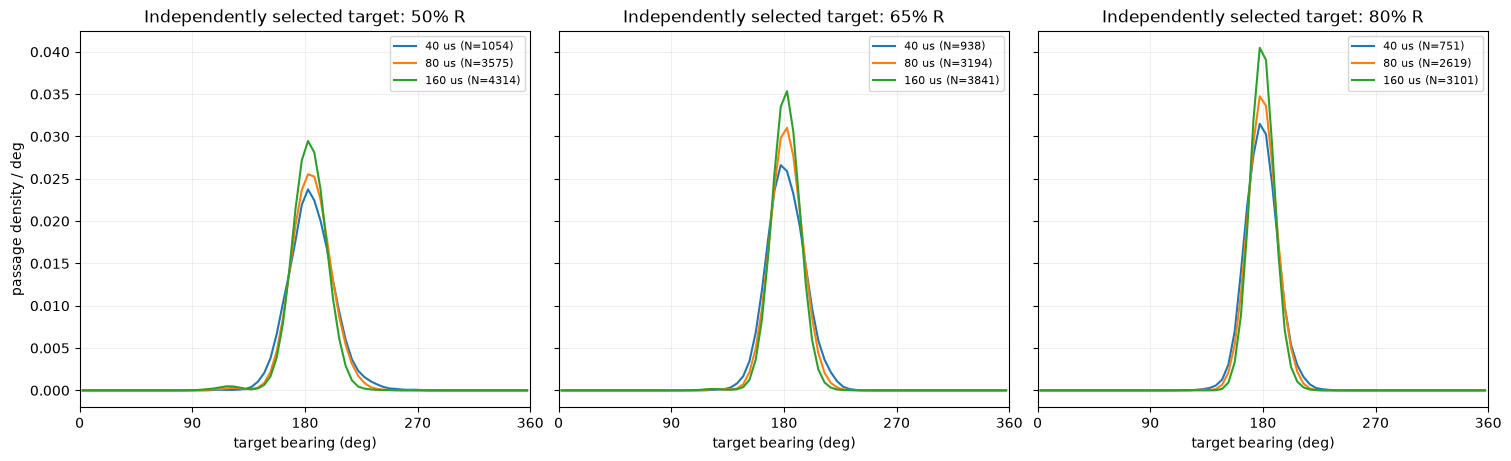

Fixed center and fitted circle; targets re-detected independently. All confirmed exits included.
Requested residence times are fixed but rounded up to whole blocks; realised times are listed.
 block us  target R   core/outer us   passages   short %   median ms   90-150 deg %
       40      0.50         240/240       1054      59.1       0.120           1.61
       40      0.65         240/240        938      46.9       0.160           1.28
       40      0.80         240/240        751      28.6       0.240           0.67
       80      0.50         240/240       3575      73.5       0.160           1.06
       80      0.65         240/240       3194      62.7       0.240           0.50
       80      0.80         240/240       2619      47.8       0.320           0.19
      160      0.50         320/320       4314      80.8       0.320           1.51
      160      0.65         320/320       3841      72.3       0.320           0.47
      160      0.80         320/320       3101      

In [84]:
ROUTE_SWEEP_TARGETS = (0.50, 0.65, 0.80)
ROUTE_SWEEP_BLOCK_FACTORS = (0.5, 1.0, 2.0)
ROUTE_SWEEP = []

for sweep_block in sorted({max(1, int(round(n_block * factor))) for factor in ROUTE_SWEEP_BLOCK_FACTORS}):
    sweep_x, sweep_y, sweep_times, sweep_rate, sweep_flags = ha.block_channel_means(
        r1, sweep_block, return_flags=True,
    )
    sweep_core_samples = route_residence_samples(ROUTE_CORE_RESIDENCE_S, sweep_rate)
    sweep_outer_samples = route_residence_samples(ROUTE_OUTER_RESIDENCE_S, sweep_rate)
    for target in ROUTE_SWEEP_TARGETS:
        sweep_events = ha.extract_radial_excursions(
            sweep_x, sweep_y, sweep_times, route_circle_center, route_circle_radius,
            core_center=route_core_center, core_fraction=ROUTE_CORE_FRACTION,
            outer_fraction=target, valid=sweep_flags['valid'],
            min_core_samples=sweep_core_samples, min_outer_samples=sweep_outer_samples,
        )
        sweep_profiles = ha.radial_crossing_profiles(
            sweep_x, sweep_y, sweep_times, sweep_events, route_circle_center, route_circle_radius, [target],
        )
        sample_counts = np.array([event['n_samples'] for event in sweep_events['paths']], dtype=int)
        durations = np.array([event['duration_s'] for event in sweep_events['paths']])
        sweep_angles = sweep_profiles['bearing_deg'][:, 0]
        finite_angles = sweep_angles[np.isfinite(sweep_angles)]
        ROUTE_SWEEP.append(dict(
            block_us=sweep_block / rec['fps'] * 1e6, target=target,
            core_residence_us=sweep_core_samples / sweep_rate * 1e6,
            outer_residence_us=sweep_outer_samples / sweep_rate * 1e6,
            count=len(sample_counts), angles=sweep_angles,
            short_fraction=float(np.mean(sample_counts < ROUTE_MIN_PATH_SAMPLES)) if len(sample_counts) else np.nan,
            duration_ms=float(np.median(durations) * 1e3) if len(durations) else np.nan,
            upper_sector_fraction=float(np.mean((finite_angles >= 90) & (finite_angles < 150))) if len(finite_angles) else np.nan,
        ))
del sweep_x, sweep_y, sweep_times, sweep_flags, sweep_events, sweep_profiles

fig, sweep_axes = plt.subplots(1, len(ROUTE_SWEEP_TARGETS), figsize=(15, 4.5), sharey=True, layout='constrained')
for axis, target in zip(np.atleast_1d(sweep_axes), ROUTE_SWEEP_TARGETS):
    for result in ROUTE_SWEEP:
        if result['target'] == target:
            axis.plot(route_angle_centers, route_bearing_density(result['angles']),
                      label=f'{result["block_us"]:.0f} us (N={result["count"]})')
    axis.set(xlabel='target bearing (deg)', xlim=(0, 360), xticks=[0, 90, 180, 270, 360],
             title=f'Independently selected target: {target:.0%} R')
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
sweep_axes[0].set_ylabel('passage density / deg')
plt.show()

print('Fixed center and fitted circle; targets re-detected independently. All confirmed exits included.')
print('Requested residence times are fixed but rounded up to whole blocks; realised times are listed.')
print(f'{"block us":>9} {"target R":>9} {"core/outer us":>15} {"passages":>10} {"short %":>9} {"median ms":>11} {"90-150 deg %":>14}')
for result in ROUTE_SWEEP:
    residence_label = f'{result["core_residence_us"]:.0f}/{result["outer_residence_us"]:.0f}'
    print(f'{result["block_us"]:9.0f} {result["target"]:9.2f} {residence_label:>15} {result["count"]:10d} '
          f'{100 * result["short_fraction"]:9.1f} {result["duration_ms"]:11.3f} '
          f'{100 * result["upper_sector_fraction"]:14.2f}')
print('90-150 deg is a descriptive upper-left bearing sector, not a fitted branch label or a hypothesis-test p-value.')
print('A direction missing at 80% R may still be present at a smaller radius; the 80% gate selects only sufficiently large excursions.')

In [85]:
from ipywidgets import interact, IntSlider, Dropdown

route_background_idx = np.flatnonzero(route_valid)
route_background_idx = route_background_idx[::max(1, len(route_background_idx) // 5000)]
route_inspection_orders = {
    'time': np.arange(len(ROUTE_RESULTS['paths'])),
    'bearing': np.argsort(route_exit_bearing),
}

def show_route(rank=0, order='bearing'):
    if not ROUTE_RESULTS['paths']:
        print('No confirmed passages for these gates.')
        return
    event_index = int(route_inspection_orders[order][rank])
    event = ROUTE_RESULTS['paths'][event_index]
    start_idx, end_idx = event['start_idx'], event['end_idx']
    path_slice = slice(start_idx, end_idx + 1)
    margin = max(3, route_residence_samples(ROUTE_CORE_RESIDENCE_S, route_rate))
    window_slice = slice(max(0, start_idx - margin), min(len(route_times), event['confirm_idx'] + margin + 1))
    path_ms = (route_times[path_slice] - route_times[start_idx]) * 1e3
    window_ms = (route_times[window_slice] - route_times[start_idx]) * 1e3
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout='constrained')
    axes[0].scatter(route_x[route_background_idx], route_y[route_background_idx], s=1, color='0.8', alpha=0.15)
    axes[0].add_patch(plt.Circle(route_core_center, ROUTE_RESULTS['core_radius'], fill=False,
                                 color='tab:orange', lw=1.3))
    axes[0].add_patch(plt.Circle(route_circle_center, ROUTE_RESULTS['outer_radius'], fill=False,
                                 color='tab:cyan', ls='--', lw=1.2))
    axes[0].plot(route_x[path_slice], route_y[path_slice], color='0.4', lw=1, zorder=2)
    path_points = axes[0].scatter(route_x[path_slice], route_y[path_slice], c=path_ms, cmap='viridis',
                                  s=32, edgecolors='white', linewidths=0.3, zorder=3)
    axes[0].scatter(route_x[start_idx], route_y[start_idx], marker='s', s=75, facecolors='none',
                    edgecolors='tab:orange', zorder=4, label='last core sample')
    axes[0].scatter(route_x[end_idx], route_y[end_idx], marker='D', s=75, facecolors='none',
                    edgecolors='tab:cyan', zorder=4, label='first confirmed outer sample')
    axes[0].set(xlabel='$a_x$', ylabel='$a_y$', aspect='equal', title='Measured samples; lines join adjacent samples')
    axes[0].legend(fontsize=7, loc='upper right')
    fig.colorbar(path_points, ax=axes[0], label='time from last core sample (ms)', shrink=0.7)

    axes[1].plot(window_ms, route_x[window_slice], 'o-', ms=3, lw=0.8, label='$a_x$')
    axes[1].plot(window_ms, route_y[window_slice], 'o-', ms=3, lw=0.8, label='$a_y$')
    axes[1].set(xlabel='time from last core sample (ms)', ylabel='anisotropy', title='Time-ordered observations')
    axes[1].legend(fontsize=8)
    radius_window = np.hypot(route_x[window_slice] - route_circle_center[0],
                              route_y[window_slice] - route_circle_center[1]) / route_circle_radius
    core_distance_window = np.hypot(route_x[window_slice] - route_core_center[0],
                                     route_y[window_slice] - route_core_center[1]) / route_circle_radius
    axes[2].plot(window_ms, radius_window, 'o-', ms=3, lw=0.8, label='radius about fitted center / R')
    axes[2].plot(window_ms, core_distance_window, '-', lw=0.8, color='tab:orange', label='distance from core center / R')
    axes[2].axhline(ROUTE_TARGET_FRACTION, color='tab:cyan', ls='--', lw=1)
    axes[2].axhline(ROUTE_CORE_FRACTION, color='tab:orange', ls=':', lw=1)
    axes[2].set(xlabel='time from last core sample (ms)', ylabel='normalised distance', title='Gate crossings and residence check')
    axes[2].legend(fontsize=7)
    for axis in axes[1:]:
        axis.axvspan(0, event['duration_s'] * 1e3, color='0.9', alpha=0.5, zorder=-1)
        axis.axvline((route_times[event['confirm_idx']] - route_times[start_idx]) * 1e3,
                     color='0.5', lw=0.8, ls=':')
        axis.grid(alpha=0.2)
    fig.suptitle(f'Passage {event_index + 1}/{len(ROUTE_RESULTS["paths"])} at {route_times[start_idx]:.6f} s; '
                 f'{event["duration_s"] * 1e3:.3f} ms, {event["n_samples"]} samples; '
                 f'target bearing {route_exit_bearing[event_index]:.1f} deg')
    plt.show()
    if not route_resolved[event_index]:
        print('Short or incomplete radial profile: do not interpret the sample-connected line as a resolved physical path.')

if ROUTE_RESULTS['paths']:
    interact(show_route,
             rank=IntSlider(value=0, min=0, max=len(ROUTE_RESULTS['paths']) - 1, step=1,
                            description='event rank:', continuous_update=False),
             order=Dropdown(options=[('Exit bearing', 'bearing'), ('Departure time', 'time')],
                            value='bearing', description='order:'))
else:
    print('No passages to inspect; adjust the central core or target radius.')

interactive(children=(IntSlider(value=0, continuous_update=False, description='event rank:', max=2618), Dropdo…

## 1c. Pinned event 549: native 4 us inspection

This section recovers **slider rank 549 in exit-bearing order**, which was displayed as **passage 1256** in the original 80 us analysis. It is now pinned by recording path and native acquisition indices, not by a rank that could change when gates or averaging change.

- Original six block-center timestamps: **16.650518 to 16.650918 s**.
- Native sample support: **[4162620, 4162740)**, containing **120 consecutive samples at 250 kHz**. The original confirmation window ends at native index 4162780 (exclusive).
- The 80 us reference was an average of 20 corrected channel samples per point, followed by forming ratios; it was not sparse sampling of one point in twenty.
- The native view uses all samples with block size 1, retaining the existing gain-plus-inverse-matrix correction, without smoothing or interpolation of new observations. Re-averaging those native corrected channels must reproduce all six saved reference points within 1e-7; otherwise the cell stops rather than silently inspecting different data.

The selected event has approximately 1 ms of context on either side, controlled by `FOCUS_CONTEXT_S`. The native foreground is not affected by `SHOW_EVERY`. The rest of the notebook retains its existing sampling and route gates; no population rerun or smaller outer threshold is applied here.

### Central-region comparison

`FOCUS_CORE_FRACTIONS = (0.12, 0.20, 0.30)` compares three disks about the **same pinned central-population center**. The fitted circle and the outer target at **0.80 R** remain fixed. These are local sensitivity comparisons, not newly inferred physical states.

The plots compare the six original points against the 120 native observations, show the time-ordered anisotropy and distance from the core, and report every consecutive core contact after first leaving the largest comparison disk. Invalid photometry breaks a contact. Duration is the number of samples multiplied by 4 us; exits in the table are exclusive. The channel and pair-sum plots provide a check for denominator failures.

### What this event shows

At native sampling the trace makes upper-left excursions, returns near the center, and then moves leftward. Some returns enter even the original 0.12 R core, but are obscured in the 80 us ratios of channel means. The original small core contains 24 us and 20 us consecutive returns; the 0.30 R comparison gives two longer returns of 48 us and 44 us. Additional shorter contacts are listed without being discarded.

The first upper-left excursion also briefly reaches beyond 0.80 R for 28 us. A later one-sample outer contact is not, by itself, strong evidence of a resolved crossing. All these brief contacts must be distinguished from the original **240 us residence/re-arming requirement**: enlarging the central disk alone does not turn short returns into confirmed dwells. The earlier population summaries were conditional on averaging and those residence checks; they cannot establish that fast upper-left excursions are absent.

This inspection does not yet prove separate physical pathways or resolve the 3D optical degeneracy. Native 4 us sample spacing is not a calibration of 4 us independent temporal resolution; detector bandwidth, signal-dependent noise, and correlated noise still matter. Positive pair sums rule out zero-denominator failures but not all optical or measurement artifacts.

In [86]:
from pathlib import Path

FOCUS_CONTEXT_S = 0.001
FOCUS_CORE_FRACTIONS = (0.12, 0.20, 0.30)
FOCUS_EVENT = {
    'source': r'data\Hinge apd recordings, 2 strand + notches\1.tdms',
    'original_rank': 549, 'original_order': 'bearing', 'original_passage': 1256,
    'native_rate_hz': 250000.0, 'block_size': 20,
    'start_native': 4162620, 'end_native_exclusive': 4162740,
    'confirm_native_exclusive': 4162780,
    'core_center': np.array([0.03230859, -0.02931147]),
    'circle_center': np.array([-0.04354894, 0.02487248]),
    'circle_radius': 0.7405140191323296, 'target_fraction': 0.80,
    'core_residence_s': 0.00024, 'outer_residence_s': 0.00024,
    'reference_ax': np.array([0.04728661, -0.33515497, -0.12729607, -0.30283434, -0.22143855, -0.72419256]),
    'reference_ay': np.array([-0.02037654, 0.43593864, 0.11139967, 0.29861856, 0.09774310, 0.11736689]),
}

def recover_native_event(recording, anchor, context_s=0.001):
    """Recover a fixed acquisition-index window; block data are only an aligned comparison."""
    native_rate = float(recording['fps'])
    if not np.isclose(native_rate, anchor['native_rate_hz'], rtol=1e-9):
        raise ValueError('The recording sample rate does not match the pinned event')
    block_size = int(anchor['block_size'])
    start_native = int(anchor['start_native'])
    stop_native = int(anchor['end_native_exclusive'])
    confirm_stop = int(anchor['confirm_native_exclusive'])
    sample_count = len(recording['t'])
    if block_size < 1 or not 0 <= start_native < stop_native <= confirm_stop <= sample_count:
        raise ValueError('Pinned event bounds are outside the recording')
    if start_native % block_size or stop_native % block_size or confirm_stop % block_size:
        raise ValueError('Pinned event bounds must align with the original averaging grid')
    if not np.isfinite(context_s) or context_s < 0:
        raise ValueError('Context duration must be nonnegative and finite')
    pad_samples = int(np.ceil(context_s * native_rate / block_size)) * block_size
    view_start = max(0, start_native - pad_samples)
    view_stop = min(sample_count, confirm_stop + pad_samples)
    channels = {name: np.asarray(recording[name])[view_start:view_stop]
                for name in ('c0', 'c90', 'c45', 'c135', 't')}
    channels['fps'] = native_rate
    native = ha.block_channel_means(channels, 1, return_flags=True)
    averaged = ha.block_channel_means(channels, block_size, return_flags=True)
    native_indices = np.arange(view_start, view_stop)
    original_start = (start_native - view_start) // block_size
    original_stop = (stop_native - view_start) // block_size
    if 'reference_ax' in anchor:
        np.testing.assert_allclose(averaged[0][original_start:original_stop], anchor['reference_ax'], atol=1e-7, rtol=0)
        np.testing.assert_allclose(averaged[1][original_start:original_stop], anchor['reference_ay'], atol=1e-7, rtol=0)
    return dict(native=native, averaged=averaged, channels=channels, native_indices=native_indices,
                view_start=view_start, view_stop=view_stop, original_slice=slice(original_start, original_stop),
                event_mask=(native_indices >= start_native) & (native_indices < stop_native),
                confirmation_mask=(native_indices >= stop_native) & (native_indices < confirm_stop))

if Path(TDMS_PATH).resolve() != Path(FOCUS_EVENT['source']).resolve():
    raise ValueError('Load the pinned source recording before inspecting this event')
FOCUS_WINDOW = recover_native_event(r1, FOCUS_EVENT, context_s=FOCUS_CONTEXT_S)
focus_native_x, focus_native_y, focus_native_t, focus_native_rate, focus_native_flags = FOCUS_WINDOW['native']
focus_block_x, focus_block_y, focus_block_t, focus_block_rate, focus_block_flags = FOCUS_WINDOW['averaged']
focus_original = FOCUS_WINDOW['original_slice']
focus_time_zero = float(focus_block_t[focus_original][0])
focus_native_us = (focus_native_t - focus_time_zero) * 1e6
focus_block_us = (focus_block_t - focus_time_zero) * 1e6
focus_event_mask = FOCUS_WINDOW['event_mask']
focus_native_valid = focus_native_flags['valid']
focus_circle_center = FOCUS_EVENT['circle_center']
focus_core_center = FOCUS_EVENT['core_center']
focus_radius = FOCUS_EVENT['circle_radius']
focus_target = FOCUS_EVENT['target_fraction']
focus_distance = np.hypot(focus_native_x - focus_core_center[0], focus_native_y - focus_core_center[1]) / focus_radius
focus_radius_fraction = np.hypot(focus_native_x - focus_circle_center[0], focus_native_y - focus_circle_center[1]) / focus_radius
if any(not np.isfinite(fraction) or fraction <= 0 for fraction in FOCUS_CORE_FRACTIONS):
    raise ValueError('Focus core fractions must be positive and finite')
if max(FOCUS_CORE_FRACTIONS) + np.linalg.norm(focus_core_center - focus_circle_center) / focus_radius >= focus_target:
    raise ValueError('Every focus core must remain inside the unchanged outer target')

print(f"Recovered original rank {FOCUS_EVENT['original_rank']} / passage {FOCUS_EVENT['original_passage']} by fixed native sample indices.")
print(f"Original averaged timestamps: {focus_time_zero:.9f}..{focus_block_t[focus_original][-1]:.9f} s")
print(f"Native support: [{FOCUS_EVENT['start_native']}, {FOCUS_EVENT['end_native_exclusive']}) = "
      f"{focus_event_mask.sum()} native samples, versus {len(focus_block_t[focus_original])} original points.")
print(f"Native step = {1e6 / focus_native_rate:.6f} us; no averaging, smoothing, interpolation, or sample skipping in the native view.")
print(f"Selected window + context: {len(focus_native_t)} samples; invalid photometry={np.count_nonzero(~focus_native_valid)}")
print('PASS: re-averaged native corrected channels reproduce all six original plotted points (absolute tolerance 1e-7).')
print(f'Core comparisons: {FOCUS_CORE_FRACTIONS}; outer target remains {focus_target:.0%} R. Global route settings are unchanged.')

Recovered original rank 549 / passage 1256 by fixed native sample indices.
Original averaged timestamps: 16.650518000..16.650918000 s
Native support: [4162620, 4162740) = 120 native samples, versus 6 original points.
Native step = 4.000000 us; no averaging, smoothing, interpolation, or sample skipping in the native view.
Selected window + context: 680 samples; invalid photometry=0
PASS: re-averaged native corrected channels reproduce all six original plotted points (absolute tolerance 1e-7).
Core comparisons: (0.12, 0.2, 0.3); outer target remains 80% R. Global route settings are unchanged.


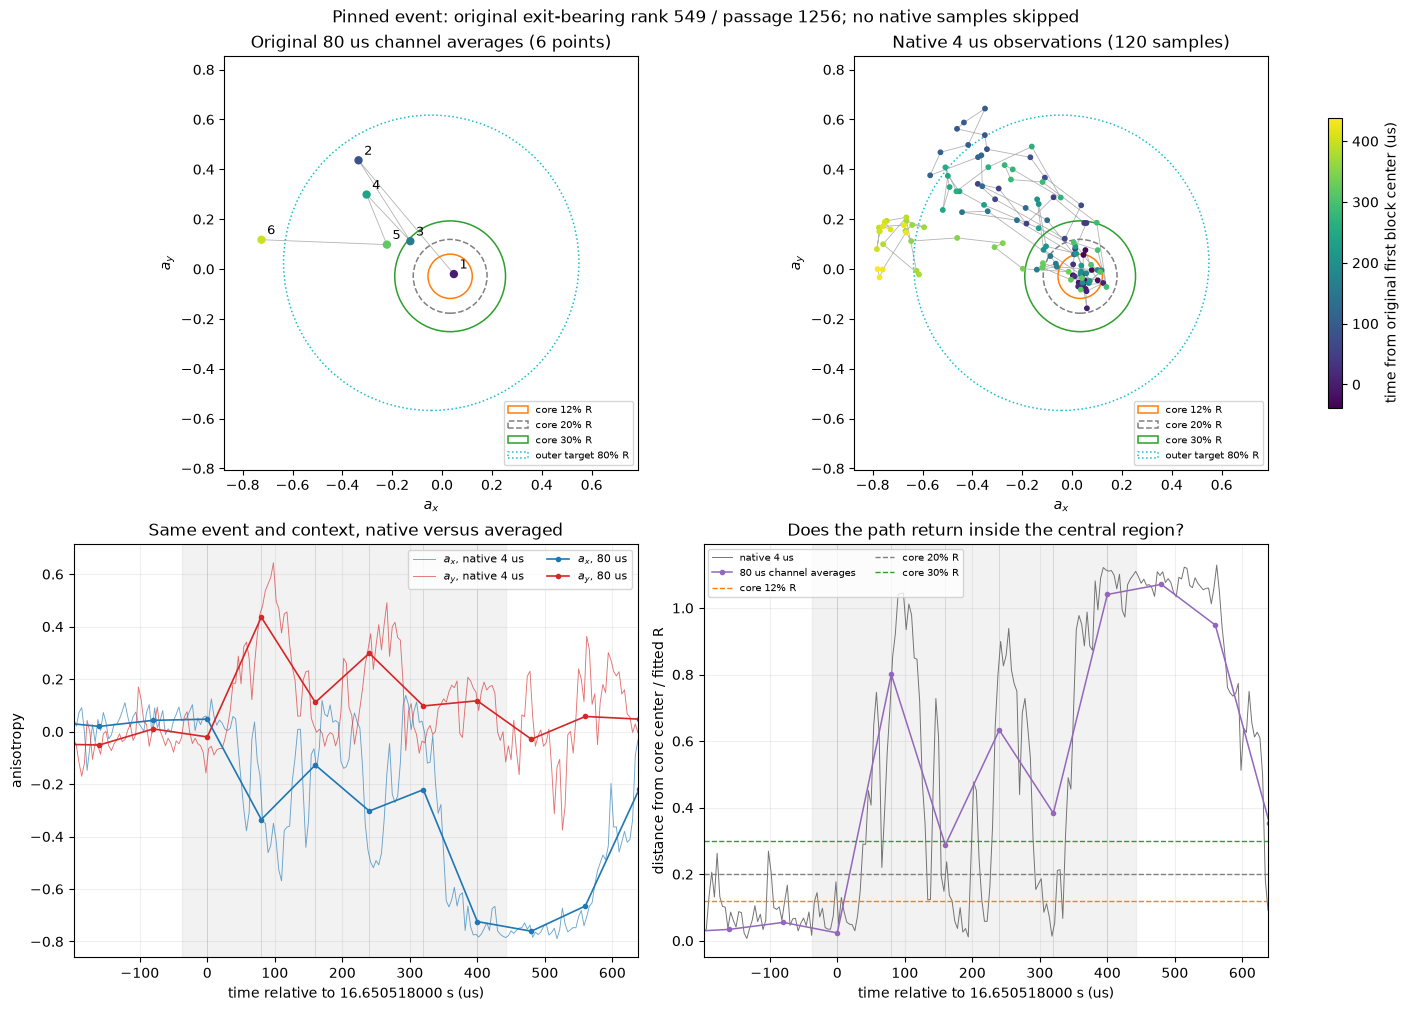

In [87]:
from matplotlib.colors import Normalize

focus_event_indices = np.flatnonzero(focus_event_mask)
focus_first_local = focus_event_indices[0]
focus_last_local = focus_event_indices[-1]
focus_time_norm = Normalize(focus_native_us[focus_first_local], focus_native_us[focus_last_local])
focus_core_colors = ['tab:orange', '0.5', 'tab:green']
focus_limit = 1.12 * focus_radius
focus_trace_limits = (focus_native_us[focus_first_local] - 160,
                      focus_native_us[focus_last_local] + 200)
fig, focus_axes = plt.subplots(2, 2, figsize=(14, 10), layout='constrained')
focus_original_axis, focus_native_axis, focus_trace_axis, focus_distance_axis = focus_axes.ravel()

for axis, x_values, y_values, sample_times, valid_values, heading in (
    (focus_original_axis, focus_block_x[focus_original], focus_block_y[focus_original],
     focus_block_us[focus_original], focus_block_flags['valid'][focus_original],
     'Original 80 us channel averages (6 points)'),
    (focus_native_axis, focus_native_x[focus_event_mask], focus_native_y[focus_event_mask],
     focus_native_us[focus_event_mask], focus_native_valid[focus_event_mask],
     'Native 4 us observations (120 samples)'),
):
    axis.plot(np.where(valid_values, x_values, np.nan), np.where(valid_values, y_values, np.nan),
              color='0.7', lw=0.6, zorder=1)
    focus_scatter = axis.scatter(x_values[valid_values], y_values[valid_values],
                                 c=sample_times[valid_values], cmap='viridis', norm=focus_time_norm,
                                 s=25 if axis is focus_original_axis else 10, zorder=2)
    for fraction, color in zip(FOCUS_CORE_FRACTIONS, focus_core_colors):
        axis.add_patch(plt.Circle(focus_core_center, fraction * focus_radius, fill=False,
                                  color=color, lw=1.1, ls='--' if fraction == 0.20 else '-',
                                  label=f'core {fraction:.0%} R'))
    axis.add_patch(plt.Circle(focus_circle_center, focus_target * focus_radius, fill=False,
                              color='tab:cyan', ls=':', lw=1.1, label='outer target 80% R'))
    axis.set(xlim=focus_circle_center[0] + np.array([-focus_limit, focus_limit]),
             ylim=focus_circle_center[1] + np.array([-focus_limit, focus_limit]),
             xlabel='$a_x$', ylabel='$a_y$', aspect='equal', title=heading)
    axis.legend(fontsize=7, loc='lower right')
for point_number, (point_x, point_y) in enumerate(zip(focus_block_x[focus_original], focus_block_y[focus_original]), start=1):
    focus_original_axis.annotate(str(point_number), (point_x, point_y), xytext=(4, 4),
                                 textcoords='offset points', fontsize=9)
fig.colorbar(focus_scatter, ax=[focus_original_axis, focus_native_axis],
             label='time from original first block center (us)', shrink=0.7)

focus_trace_axis.plot(focus_native_us, np.where(focus_native_valid, focus_native_x, np.nan),
                      color='tab:blue', lw=0.65, alpha=0.65, label='$a_x$, native 4 us')
focus_trace_axis.plot(focus_native_us, np.where(focus_native_valid, focus_native_y, np.nan),
                      color='tab:red', lw=0.65, alpha=0.65, label='$a_y$, native 4 us')
focus_trace_axis.plot(focus_block_us, focus_block_x, 'o-', color='tab:blue', ms=3, lw=1.2, label='$a_x$, 80 us')
focus_trace_axis.plot(focus_block_us, focus_block_y, 'o-', color='tab:red', ms=3, lw=1.2, label='$a_y$, 80 us')
focus_trace_axis.set(ylabel='anisotropy', title='Same event and context, native versus averaged')
focus_trace_axis.legend(fontsize=8, ncol=2)

focus_block_core_distance = np.hypot(focus_block_x - focus_core_center[0],
                                      focus_block_y - focus_core_center[1]) / focus_radius
focus_distance_axis.plot(focus_native_us, np.where(focus_native_valid, focus_distance, np.nan),
                         color='0.45', lw=0.7, label='native 4 us')
focus_distance_axis.plot(focus_block_us, focus_block_core_distance, 'o-',
                         color='tab:purple', ms=3, lw=1.1, label='80 us channel averages')
for fraction, color in zip(FOCUS_CORE_FRACTIONS, focus_core_colors):
    focus_distance_axis.axhline(fraction, color=color, lw=1, ls='--', label=f'core {fraction:.0%} R')
focus_distance_axis.set(ylabel='distance from core center / fitted R', title='Does the path return inside the central region?')
focus_distance_axis.legend(fontsize=7, ncol=2)
for axis in (focus_trace_axis, focus_distance_axis):
    axis.axvspan(focus_native_us[focus_first_local], focus_native_us[focus_last_local] + 1e6 / focus_native_rate,
                 color='0.9', alpha=0.5, zorder=-2)
    for block_time in focus_block_us[focus_original]:
        axis.axvline(block_time, color='0.8', lw=0.5, zorder=-1)
    axis.set(xlabel=f'time relative to {focus_time_zero:.9f} s (us)', xlim=focus_trace_limits)
    axis.grid(alpha=0.2)
fig.suptitle('Pinned event: original exit-bearing rank 549 / passage 1256; no native samples skipped')
plt.show()

Consecutive in-core runs after the first departure from the largest comparison core:
Times are relative to the original first block center; exit is exclusive. All short contacts are retained.
  core R   entry us    exit us   samples   duration us    meets 240 us
    0.12      174.0      198.0         6          24.0           False
    0.12      218.0      226.0         2           8.0           False
    0.12      306.0      326.0         5          20.0           False
    0.12      334.0      338.0         1           4.0           False
    0.20      134.0      142.0         2           8.0           False
    0.20      154.0      162.0         2           8.0           False
    0.20      166.0      198.0         8          32.0           False
    0.20      214.0      230.0         4          16.0           False
    0.20      294.0      326.0         8          32.0           False
    0.20      334.0      338.0         1           4.0           False
    0.30       66.0       7

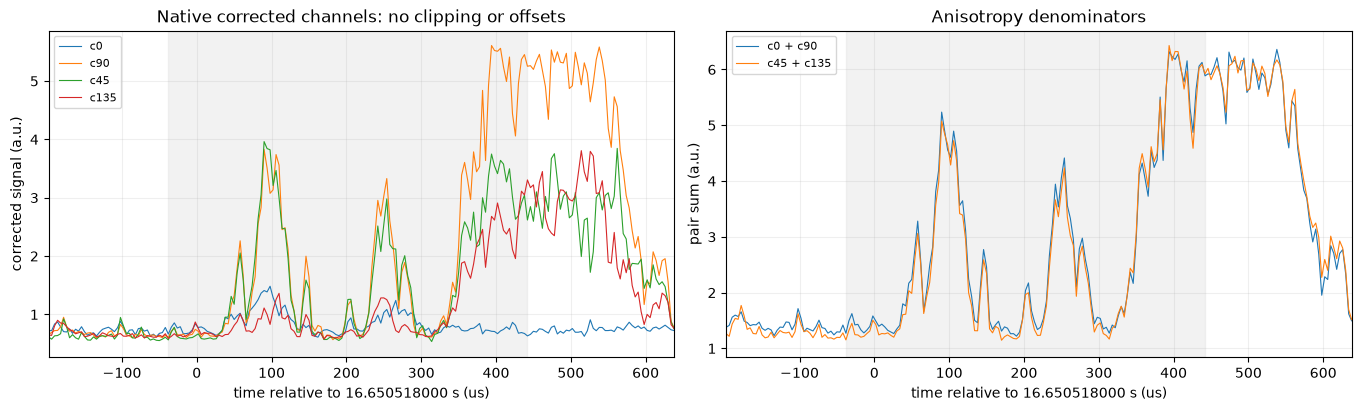

Pair sums within the pinned event: c0+c90=1.22016..6.31973; c45+c135=1.14685..6.42943
Positive denominators exclude zero-sum failures, not all measurement noise or optical artifacts.
Changing the core size alone does not change the 240 us re-arming requirement. A brief return need not satisfy it.


In [88]:
def focused_core_returns(distance_fraction, times, valid, event_mask, fractions, rate):
    """Core contacts after first leaving the largest comparison disk, without filtering."""
    distance_fraction = np.asarray(distance_fraction, dtype=float)
    times = np.asarray(times, dtype=float)
    valid = np.asarray(valid, dtype=bool) & np.isfinite(distance_fraction)
    event_mask = np.asarray(event_mask, dtype=bool)
    departures = np.flatnonzero(event_mask & valid & (distance_fraction > max(fractions)))
    if len(departures) == 0:
        return []
    after_departure = np.arange(len(times)) > departures[0]
    returns = []
    for fraction in fractions:
        inside = event_mask & after_departure & valid & (distance_fraction <= fraction)
        boundaries = np.diff(np.concatenate(([False], inside, [False])).astype(int))
        starts = np.flatnonzero(boundaries == 1)
        stops = np.flatnonzero(boundaries == -1)
        for start, stop in zip(starts, stops):
            returns.append(dict(
                fraction=float(fraction), start_idx=int(start), stop_idx=int(stop),
                entry_s=float(times[start]), exit_s=float(times[stop - 1] + 1 / rate),
                samples=int(stop - start), duration_s=float((stop - start) / rate),
            ))
    return returns

FOCUS_CORE_RETURNS = focused_core_returns(
    focus_distance, focus_native_t, focus_native_valid, focus_event_mask,
    FOCUS_CORE_FRACTIONS, focus_native_rate,
 )
print('Consecutive in-core runs after the first departure from the largest comparison core:')
print('Times are relative to the original first block center; exit is exclusive. All short contacts are retained.')
print(f'{"core R":>8} {"entry us":>10} {"exit us":>10} {"samples":>9} {"duration us":>13} {"meets 240 us":>15}')
for visit in FOCUS_CORE_RETURNS:
    confirmed = visit['duration_s'] + 1e-12 >= FOCUS_EVENT['core_residence_s']
    print(f'{visit["fraction"]:8.2f} {(visit["entry_s"] - focus_time_zero) * 1e6:10.1f} '
          f'{(visit["exit_s"] - focus_time_zero) * 1e6:10.1f} {visit["samples"]:9d} '
          f'{visit["duration_s"] * 1e6:13.1f} {str(confirmed):>15}')
print('These are measured core contacts, not automatically distinct metastable states.')

focus_outer_mask = (focus_event_mask | FOCUS_WINDOW['confirmation_mask']) & focus_native_valid & (focus_radius_fraction >= focus_target)
focus_outer_boundaries = np.diff(np.concatenate(([False], focus_outer_mask, [False])).astype(int))
FOCUS_OUTER_CONTACTS = []
print('\nNative outer-target contacts over the pinned event and its original confirmation window:')
print(f'{"entry us":>10} {"exit us":>10} {"duration us":>13} {"bearing deg":>13} {"max rho":>9}')
for start, stop in zip(np.flatnonzero(focus_outer_boundaries == 1), np.flatnonzero(focus_outer_boundaries == -1)):
    contact_bearing = np.degrees(np.arctan2(
        np.mean(focus_native_y[start:stop] - focus_circle_center[1]),
        np.mean(focus_native_x[start:stop] - focus_circle_center[0]),
    )) % 360
    contact = dict(entry_us=float(focus_native_us[start]),
                   exit_us=float(focus_native_us[stop - 1] + 1e6 / focus_native_rate),
                   duration_us=float((stop - start) * 1e6 / focus_native_rate),
                   bearing_deg=float(contact_bearing), max_rho=float(np.max(focus_radius_fraction[start:stop])))
    FOCUS_OUTER_CONTACTS.append(contact)
    print(f'{contact["entry_us"]:10.1f} {contact["exit_us"]:10.1f} {contact["duration_us"]:13.1f} '
          f'{contact["bearing_deg"]:13.1f} {contact["max_rho"]:9.3f}')
print('This is a contact list, not re-detected confirmed events; a one-sample crossing may reflect measurement noise.')

focus_channels = FOCUS_WINDOW['channels']
focus_pair_x = focus_channels['c0'] + focus_channels['c90']
focus_pair_y = focus_channels['c45'] + focus_channels['c135']
fig, focus_channel_axes = plt.subplots(1, 2, figsize=(13.5, 4), sharex=True, layout='constrained')
for channel_name in ('c0', 'c90', 'c45', 'c135'):
    focus_channel_axes[0].plot(focus_native_us, focus_channels[channel_name], lw=0.8, label=channel_name)
focus_channel_axes[0].set(ylabel='corrected signal (a.u.)', title='Native corrected channels: no clipping or offsets')
focus_channel_axes[1].plot(focus_native_us, focus_pair_x, lw=0.8, label='c0 + c90')
focus_channel_axes[1].plot(focus_native_us, focus_pair_y, lw=0.8, label='c45 + c135')
focus_channel_axes[1].set(ylabel='pair sum (a.u.)', title='Anisotropy denominators')
for axis in focus_channel_axes:
    axis.axvspan(focus_native_us[focus_first_local], focus_native_us[focus_last_local] + 1e6 / focus_native_rate,
                 color='0.9', alpha=0.5, zorder=-2)
    axis.set(xlabel=f'time relative to {focus_time_zero:.9f} s (us)', xlim=focus_trace_limits)
    axis.legend(fontsize=8)
    axis.grid(alpha=0.2)
plt.show()
print(f'Pair sums within the pinned event: c0+c90={focus_pair_x[focus_event_mask].min():.6g}..{focus_pair_x[focus_event_mask].max():.6g}; '
      f'c45+c135={focus_pair_y[focus_event_mask].min():.6g}..{focus_pair_y[focus_event_mask].max():.6g}')
print('Positive denominators exclude zero-sum failures, not all measurement noise or optical artifacts.')
print('Changing the core size alone does not change the 240 us re-arming requirement. A brief return need not satisfy it.')

## 1d. Earlier Equal-Area Ellipse Cores

**Alternative geometry retained for comparison, not the current annular route test.** Here A is a smaller origin-centered disk; B and C are identical-size radial ellipses whose centers are equally distant from the origin, with explicit edge-to-edge separation between every region pair. These A/B/C labels differ from the new annular-sector labels.

### Area and size controls

The existing right-side radial quantile provides a **base** A radius: the 95th percentile of valid native samples with `ax >= 0` and `r <= 0.30`. `ABC_A_RADIUS_OVERRIDE` overrides this base radius, before shrinking.

`ABC_AREA_FACTOR = 0.50` halves each region's area relative to the preceding base area, so lengths scale by its square root:

$$R_A=R_{A,\mathrm{base}}\sqrt{f},\qquad \mathrm{area}(A)=\mathrm{area}(B)=\mathrm{area}(C)=\pi R_A^2.$$

The base radius is approximately 0.21524; the smaller A radius is **0.15220**, and each area is **0.072775**. This factor is explicit and adjustable; it is not a result inferred from transition counts. Data and the A disk are not clipped or shifted.

### Matched radial B/C geometry

One joint fit chooses four parameters: common aspect ratio $q$, common center radius $d$, and two bearings $\beta_B,\beta_C$. For both ellipses,

$$a=R_A\sqrt q,\quad b=R_A/\sqrt q,\quad \mathbf c_j=d(\cos\beta_j,\sin\beta_j).$$

Each ellipse is oriented at its own bearing, so its major-axis line passes through the origin. Both ellipses have identical semiaxes, identical radial extents, and the same distance to A. `ABC_MIN_ASPECT = 2` and `ABC_MAX_ASPECT = 4` retain a genuine long axis; these are explicit shape assumptions, not physical calibrations.

The fit maximizes summed covered native counts in B and C on a 0.01-square spatial histogram. No temporal smoothing or rotated-transition outcome is used. The more populated side can influence this joint objective. The optimizer is a bounded numerical search, not a certified global optimum.

### Required gaps

`ABC_GAP_RADIUS_FACTOR = 1.0` requires each of A-B, A-C, and B-C to have an edge-to-edge gap at least that factor times the smaller A radius. It cannot be set below one. Center-to-center distances alone are not used as a substitute.

For the radial ellipses the A gap is $d-a-R_A$. Because the ellipses are congruent and at equal radii, reflection symmetry gives their exact B-C gap from the center chord and ellipse support widths. The implementation checks this geometry, with an independent dense-boundary regression test. A separate `ABC_CLEARANCE = 0.005` keeps B and C on their own sides of the separator.

Reference ellipse fit:

| Quantity | Value (anisotropy units) |
|---|---:|
| Shared B/C center radius | 0.653748 |
| Full major/minor lengths | 0.430515 / 0.215230 |
| A-B edge gap | 0.286290 (1.881 A radii) |
| A-C edge gap | 0.286290 (1.881 A radii) |
| B-C edge gap | 0.251164 (1.650 A radii) |

The origin-crossing separator remains the 141.25-degree valley of the 80 us overview in the 0.50-0.75 annulus. Its source remains explicit: the native angular profile has no interior minimum in the search sector. All region coverage and sample labels use native 4 us data.

### Interpretation

Outside-core points remain unassigned. Larger gaps reduce boundary adjacency but do not guarantee that noise-driven or unresolved crossings are absent. Minimum visit rules and temporal evidence remain relevant.

Outputs in this and the following ellipse/control sections depend on `ABC_*` settings and must be rerun if those settings change. They are not annular-sector statistics and do not use O, trans_AB, or trans_BC.

Both historical examples near 11.803 s remain permanently pinned with their old geometry and reference traces. The separate rank-549 example near 16.6505 s is also unchanged.

In [89]:
ABC_SEPARATOR_RADII = (0.50, 0.75)
ABC_SEPARATOR_SEARCH_DEG = (120.0, 165.0)
ABC_SEPARATOR_SMOOTH_DEG = 3.0
ABC_SEPARATOR_SOURCE = 'overview'
ABC_SEPARATOR_ANGLE_OVERRIDE = None
ABC_A_RIGHT_RADIUS_LIMIT = 0.30
ABC_A_QUANTILE = 0.95
ABC_A_RADIUS_OVERRIDE = None
ABC_AREA_FACTOR = 0.50
ABC_GAP_RADIUS_FACTOR = 1.0
ABC_FIT_BIN_WIDTH = 0.01
ABC_CLEARANCE = 0.005
ABC_MIN_ASPECT = 2.0
ABC_MAX_ASPECT = 4.0
ABC_FIT_SEED = 0
ABC_FIT_MAXITER = 320
ABC_CORE_SCALE = 1.0
ABC_MIN_VISIT_US = 12.0
ABC_ZOOM_S = (16.6500, 16.6520)
ABC_COLORS = {'A': '#D62728', 'B': '#2CA02C', 'C': '#00A6D6',
              'unassigned': '#999999', 'invalid': '#CC79A7'}

if not np.isfinite(ABC_AREA_FACTOR) or not 0 < ABC_AREA_FACTOR <= 1:
    raise ValueError('ABC_AREA_FACTOR must be in (0, 1] relative to the base A area')
if not np.isfinite(ABC_GAP_RADIUS_FACTOR) or ABC_GAP_RADIUS_FACTOR < 1:
    raise ValueError('ABC_GAP_RADIUS_FACTOR must be at least 1 (edge-to-edge gaps in A radii)')
abc_x, abc_y, abc_times, abc_rate, abc_photometry_flags = ha.block_channel_means(
    r1, 1, return_flags=True,
 )
ABC_SEPARATOR_NATIVE = ha.fit_origin_separator(
    abc_x, abc_y, valid=abc_photometry_flags['valid'],
    radial_band=ABC_SEPARATOR_RADII, angle_bounds_deg=ABC_SEPARATOR_SEARCH_DEG,
    smoothing_deg=ABC_SEPARATOR_SMOOTH_DEG,
 )
ABC_SEPARATOR_OVERVIEW = ha.fit_origin_separator(
    STAGES['corrected'][0], STAGES['corrected'][1], valid=CHANNEL_FLAGS['corrected']['valid'],
    radial_band=ABC_SEPARATOR_RADII, angle_bounds_deg=ABC_SEPARATOR_SEARCH_DEG,
    smoothing_deg=ABC_SEPARATOR_SMOOTH_DEG,
 )
if ABC_SEPARATOR_SOURCE not in ('overview', 'native'):
    raise ValueError("ABC_SEPARATOR_SOURCE must be 'overview' or 'native'")
ABC_SEPARATOR = dict(ABC_SEPARATOR_OVERVIEW if ABC_SEPARATOR_SOURCE == 'overview' else ABC_SEPARATOR_NATIVE)
if ABC_SEPARATOR_ANGLE_OVERRIDE is not None:
    separator_angle = float(ABC_SEPARATOR_ANGLE_OVERRIDE)
    if not np.isfinite(separator_angle) or not 0 < separator_angle < 180:
        raise ValueError('Separator override must be between 0 and 180 degrees')
    ABC_SEPARATOR['angle_deg'] = separator_angle
    ABC_SEPARATOR['normal'] = np.array([-np.sin(np.radians(separator_angle)), np.cos(np.radians(separator_angle))])
ABC_A_FIT = ha.fit_origin_core_radius(
    abc_x, abc_y, valid=abc_photometry_flags['valid'],
    quantile=ABC_A_QUANTILE, right_radius_limit=ABC_A_RIGHT_RADIUS_LIMIT,
 )
ABC_BASE_A_RADIUS = ABC_A_FIT['radius'] if ABC_A_RADIUS_OVERRIDE is None else float(ABC_A_RADIUS_OVERRIDE)
ABC_A_RADIUS = ABC_BASE_A_RADIUS * np.sqrt(ABC_AREA_FACTOR)
ABC_PAIR_GAP = ABC_GAP_RADIUS_FACTOR * ABC_A_RADIUS
ABC_GEOMETRY_FIT = ha.fit_radial_equal_area_ellipses(
    abc_x, abc_y, ABC_A_RADIUS, ABC_SEPARATOR['normal'], valid=abc_photometry_flags['valid'],
    histogram_step=ABC_FIT_BIN_WIDTH, clearance=ABC_CLEARANCE, pair_clearance=ABC_PAIR_GAP,
    min_aspect=ABC_MIN_ASPECT, max_aspect=ABC_MAX_ASPECT, seed=ABC_FIT_SEED, maxiter=ABC_FIT_MAXITER,
 )
ABC_REGIONS = ABC_GEOMETRY_FIT['regions']
ABC_PAIR_GAPS = ha.radial_region_gaps(ABC_REGIONS)
np.testing.assert_allclose(ABC_REGIONS['B']['semiaxes'], ABC_REGIONS['C']['semiaxes'], rtol=1e-12)
np.testing.assert_allclose(np.linalg.norm(ABC_REGIONS['B']['center']), np.linalg.norm(ABC_REGIONS['C']['center']), atol=1e-12)
np.testing.assert_allclose(ABC_GEOMETRY_FIT['area'], np.pi * ABC_BASE_A_RADIUS**2 * ABC_AREA_FACTOR, rtol=1e-12)
if min(ABC_PAIR_GAPS.values()) < ABC_PAIR_GAP - 1e-10:
    raise RuntimeError('The final pairwise clearance check failed')
ABC_CLASSIFICATION = ha.classify_region_cores(
    abc_x, abc_y, ABC_REGIONS, valid=abc_photometry_flags['valid'],
 )
ABC_LABELS = ABC_CLASSIFICATION['labels']
ABC_REGION_NAMES = ABC_CLASSIFICATION['region_names']
if not np.isfinite(ABC_MIN_VISIT_US) or ABC_MIN_VISIT_US <= 0:
    raise ValueError('ABC_MIN_VISIT_US must be positive and finite')
abc_min_samples = max(1, int(np.ceil(ABC_MIN_VISIT_US * 1e-6 * abc_rate - 1e-10)))
ABC_RESIDENCE = ha.region_residence_statistics(
    ABC_LABELS, abc_times, abc_rate, ABC_REGION_NAMES, min_visit_samples=abc_min_samples,
 )

print(f'Native geometry fit: {len(abc_times):,} samples, {1e6 / abc_rate:.3f} us per sample.')
print(f"Separator source={ABC_SEPARATOR_SOURCE}, angle={ABC_SEPARATOR['angle_deg']:.2f} deg; "
      f"overview block={1e6 / STAGES['corrected'][3]:.1f} us.")
for source_name, profile in (('native', ABC_SEPARATOR_NATIVE), ('overview', ABC_SEPARATOR_OVERVIEW)):
    print(f"{source_name}: candidate angle={profile['angle_deg']:.2f}, interior density valley={profile['interior_minimum']}")
print(f'Base A radius={ABC_BASE_A_RADIUS:.6f}; area multiplier={ABC_AREA_FACTOR:.3f}; new A radius={ABC_A_RADIUS:.6f}.')
print(f"All three areas={ABC_GEOMETRY_FIT['area']:.6f}; B/C full major/minor lengths={2 * np.asarray(ABC_GEOMETRY_FIT['shared_semiaxes'])}.")
print(f"B and C share center radius={ABC_GEOMETRY_FIT['shared_center_radius']:.6f}; radial major axes pass through the origin.")
print(f'Every pair requires an EDGE gap >= {ABC_PAIR_GAP:.6f} ({ABC_GAP_RADIUS_FACTOR:g} x new A radius).')
for pair_name, gap in ABC_PAIR_GAPS.items():
    print(f'{pair_name}: edge gap={gap:.6f} = {gap / ABC_A_RADIUS:.3f} A radii')
for name in ('B', 'C'):
    region = ABC_REGIONS[name]
    diagnostics = ABC_GEOMETRY_FIT['diagnostics'][name]
    print(f"{name}: center={np.round(region['center'], 6)}, angle={region['angle_deg']:.3f} deg, "
          f"center radius={diagnostics['center_radius']:.6f}, radial extent={np.round(diagnostics['radial_interval'], 6)}, "
          f"line gap={diagnostics['line_gap']:.6f}, converged={diagnostics['converged']}")
    if not diagnostics['converged']:
        print(f"  Feasible best-so-far fit: {diagnostics['message']}")
print('Geometry updated; inspect the next plot before rerunning downstream visit/transition/control cells.')
print('Larger gaps reduce adjacency sensitivity but do not by themselves rule out noisy or unresolved transitions. Historical pinned traces are unchanged.')

Native geometry fit: 8,250,000 samples, 4.000 us per sample.
Separator source=overview, angle=141.25 deg; overview block=80.0 us.
native: candidate angle=120.25, interior density valley=False
overview: candidate angle=141.25, interior density valley=True
Base A radius=0.215244; area multiplier=0.500; new A radius=0.152200.
All three areas=0.072775; B/C full major/minor lengths=[0.43051491 0.21523011].
B and C share center radius=0.653748; radial major axes pass through the origin.
Every pair requires an EDGE gap >= 0.152200 (1 x new A radius).
A-B: edge gap=0.286290 = 1.881 A radii
A-C: edge gap=0.286290 = 1.881 A radii
B-C: edge gap=0.251164 = 1.650 A radii
B: center=[-0.65263  0.03821], angle=176.649 deg, center radius=0.653748, radial extent=[0.43849  0.869005], line gap=0.226240, converged=True
C: center=[-0.425687  0.496162], angle=130.628 deg, center radius=0.653748, radial extent=[0.43849  0.869005], line gap=0.007534, converged=True
Geometry updated; inspect the next plot befor

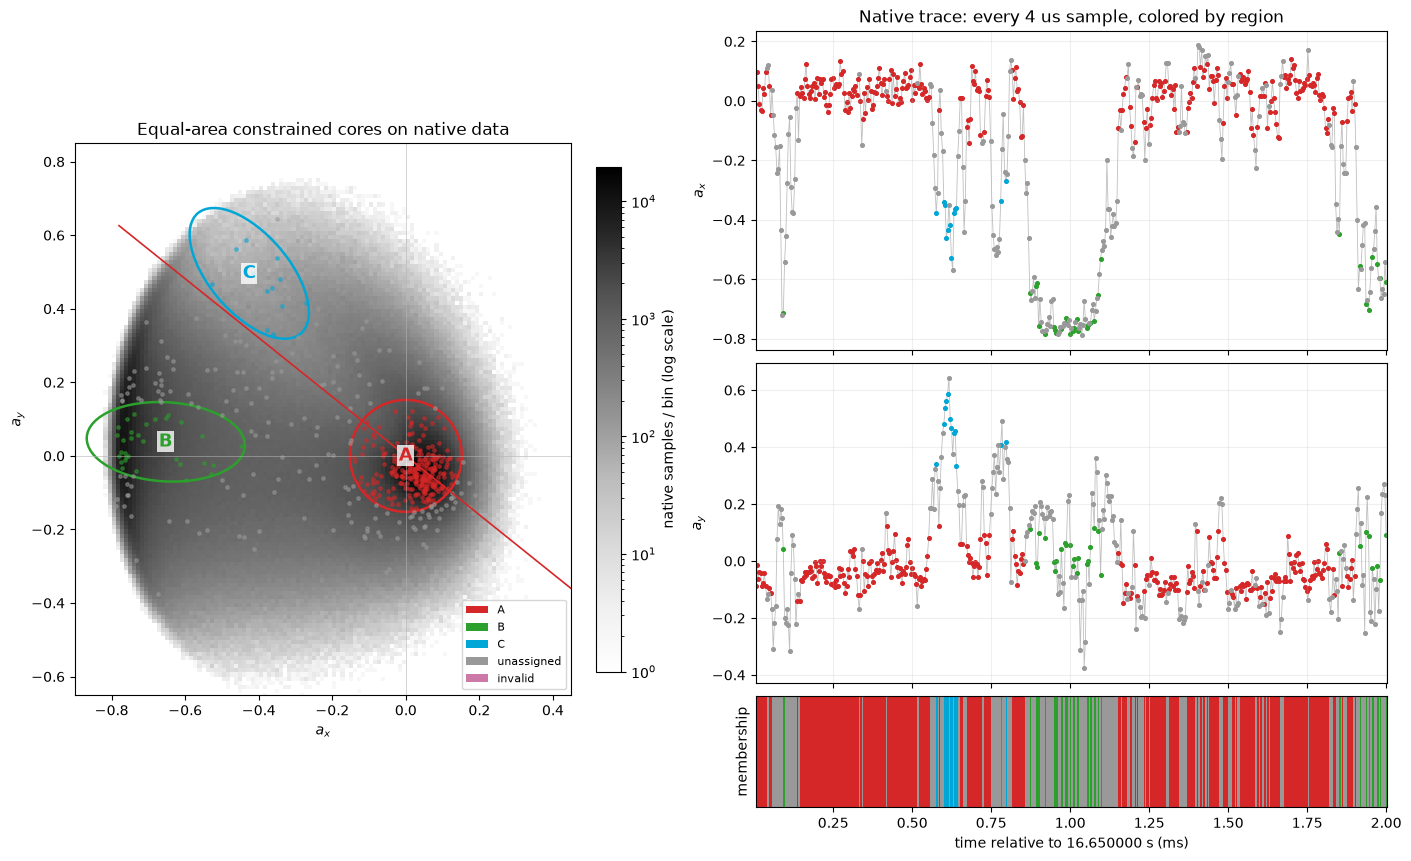

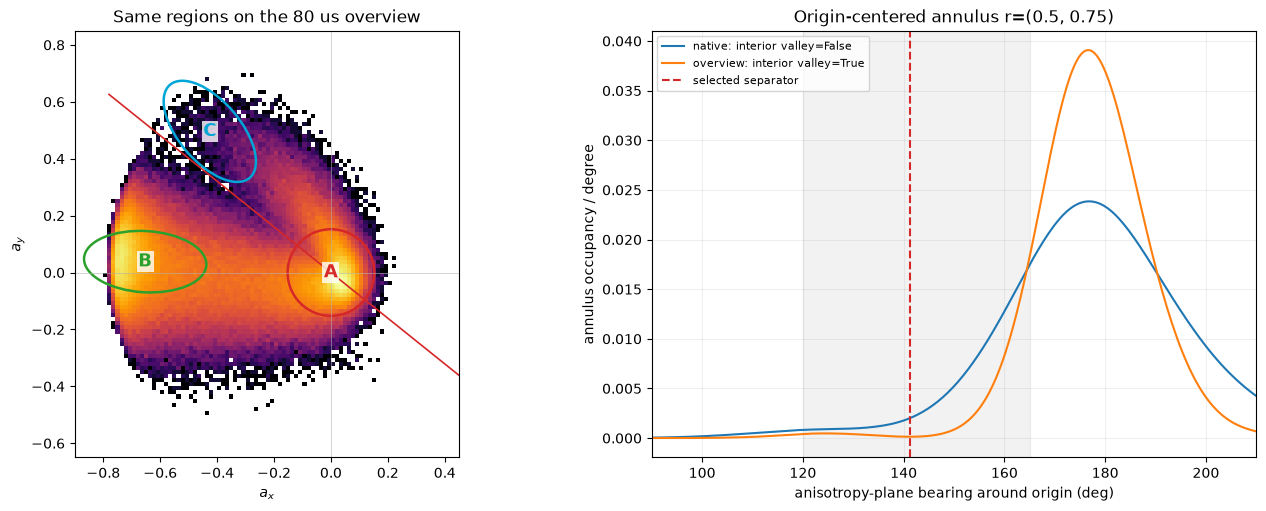

0 valid samples outside the native map bounds; all remain in the statistics.
Line fit uses the declared source; ellipse coverage and labels use native data. Density fitting is not independent validation of states.


In [90]:
from matplotlib.patches import Ellipse, Patch
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm

def draw_abc_geometry(axis):
    angle = np.radians(ABC_SEPARATOR['angle_deg'])
    direction = np.array([np.cos(angle), np.sin(angle)])
    axis.plot([-direction[0], direction[0]], [-direction[1], direction[1]],
              color='tab:red', lw=1.2, label=f"separator {ABC_SEPARATOR['angle_deg']:.2f} deg")
    for name, region in ABC_REGIONS.items():
        axes_lengths = np.asarray(region['semiaxes'])
        axis.add_patch(Ellipse(region['center'], width=2 * axes_lengths[0], height=2 * axes_lengths[1],
                               angle=region.get('angle_deg', 0.), facecolor='none', edgecolor=ABC_COLORS[name], lw=1.8))
        axis.text(*region['center'], name, ha='center', va='center', fontsize=13, fontweight='bold',
                  color=ABC_COLORS[name], bbox=dict(facecolor='white', edgecolor='none', alpha=.8, pad=1))
    axis.axhline(0, color='0.7', lw=.4)
    axis.axvline(0, color='0.7', lw=.4)
    axis.set(xlim=(-.9, .45), ylim=(-.65, .85), aspect='equal', xlabel='$a_x$', ylabel='$a_y$')

abc_zoom_start, abc_zoom_stop = np.searchsorted(abc_times, ABC_ZOOM_S)
if abc_zoom_start >= abc_zoom_stop or abc_zoom_stop > len(abc_times):
    raise ValueError('ABC_ZOOM_S must select a nonempty interval in the recording')
abc_view = slice(abc_zoom_start, abc_zoom_stop)
abc_view_ms = (abc_times[abc_view] - ABC_ZOOM_S[0]) * 1e3
abc_view_labels = ABC_LABELS[abc_view]
abc_codes = tuple(enumerate(ABC_REGION_NAMES)) + ((-1, 'unassigned'), (-2, 'invalid'))
abc_density_valid = ABC_LABELS != -2
abc_counts, abc_x_edges, abc_y_edges = np.histogram2d(
    abc_x[abc_density_valid], abc_y[abc_density_valid], bins=180, range=[[-1., 1.], [-1., 1.]],
 )
abc_outside_density = np.count_nonzero(abc_density_valid & ((np.abs(abc_x) > 1.) | (np.abs(abc_y) > 1.)))

fig = plt.figure(figsize=(14, 8.5), layout='constrained')
abc_grid = fig.add_gridspec(3, 2, width_ratios=[1.1, 1.4], height_ratios=[1., 1., .35])
abc_map_axis = fig.add_subplot(abc_grid[:, 0])
abc_x_axis = fig.add_subplot(abc_grid[0, 1])
abc_y_axis = fig.add_subplot(abc_grid[1, 1], sharex=abc_x_axis)
abc_label_axis = fig.add_subplot(abc_grid[2, 1], sharex=abc_x_axis)
abc_image = abc_map_axis.imshow(abc_counts.T, origin='lower', extent=[-1., 1., -1., 1.],
                                cmap='Greys', norm=LogNorm(vmin=1, vmax=max(2, abc_counts.max())), interpolation='nearest')
draw_abc_geometry(abc_map_axis)
for code, name in abc_codes:
    selected = abc_view_labels == code
    abc_map_axis.scatter(abc_x[abc_view][selected], abc_y[abc_view][selected], s=6,
                         color=ABC_COLORS[name], alpha=.5, rasterized=True)
    abc_x_axis.scatter(abc_view_ms[selected], abc_x[abc_view][selected], s=7, color=ABC_COLORS[name])
    abc_y_axis.scatter(abc_view_ms[selected], abc_y[abc_view][selected], s=7, color=ABC_COLORS[name])
for axis, values, label in ((abc_x_axis, abc_x, '$a_x$'), (abc_y_axis, abc_y, '$a_y$')):
    axis.plot(abc_view_ms, np.where(abc_view_labels != -2, values[abc_view], np.nan), color='0.75', lw=.6, zorder=-1)
    axis.set_ylabel(label)
    axis.grid(alpha=.2)
abc_x_axis.set_title('Native trace: every 4 us sample, colored by region')
abc_map_axis.set_title('Equal-area constrained cores on native data')
abc_map_axis.legend(handles=[Patch(facecolor=ABC_COLORS[name], label=name) for _, name in abc_codes],
                    loc='lower right', fontsize=8)
fig.colorbar(abc_image, ax=abc_map_axis, label='native samples / bin (log scale)', shrink=.65)
abc_label_colors = [ABC_COLORS['invalid'], ABC_COLORS['unassigned']] + [ABC_COLORS[name] for name in ABC_REGION_NAMES]
abc_label_axis.imshow((abc_view_labels + 2)[None, :], origin='lower', aspect='auto', interpolation='nearest',
                      extent=[abc_view_ms[0], abc_view_ms[-1] + 1e3 / abc_rate, 0, 1],
                      cmap=ListedColormap(abc_label_colors),
                      norm=BoundaryNorm(np.arange(len(abc_label_colors) + 1) - .5, len(abc_label_colors)))
abc_label_axis.set(yticks=[], ylabel='membership', xlabel=f'time relative to {ABC_ZOOM_S[0]:.6f} s (ms)')
abc_x_axis.tick_params(labelbottom=False)
abc_y_axis.tick_params(labelbottom=False)
plt.show()

fig, (abc_overview_axis, abc_separator_axis) = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
overview_x, overview_y = STAGES['corrected'][:2]
overview_valid = CHANNEL_FLAGS['corrected']['valid']
abc_overview_axis.hist2d(overview_x[overview_valid], overview_y[overview_valid], bins=140,
                         range=[[-1, 1], [-1, 1]], norm=LogNorm(vmin=1), cmap='inferno')
draw_abc_geometry(abc_overview_axis)
abc_overview_axis.set_title(f"Same regions on the {1e6 / STAGES['corrected'][3]:.0f} us overview")
for label, profile in (('native', ABC_SEPARATOR_NATIVE), ('overview', ABC_SEPARATOR_OVERVIEW)):
    bin_width = np.diff(profile['angles_deg'])[0]
    density = profile['smoothed_counts'] / (profile['annulus_samples'] * bin_width)
    abc_separator_axis.plot(profile['angles_deg'], density, label=f"{label}: interior valley={profile['interior_minimum']}")
abc_separator_axis.axvspan(*ABC_SEPARATOR_SEARCH_DEG, color='0.5', alpha=.1)
abc_separator_axis.axvline(ABC_SEPARATOR['angle_deg'], color='tab:red', ls='--', label='selected separator')
abc_separator_axis.set(xlim=(90, 210), xlabel='anisotropy-plane bearing around origin (deg)',
                       ylabel='annulus occupancy / degree', title=f'Origin-centered annulus r={ABC_SEPARATOR_RADII}')
abc_separator_axis.legend(fontsize=8)
abc_separator_axis.grid(alpha=.2)
plt.show()
print(f'{abc_outside_density:,} valid samples outside the native map bounds; all remain in the statistics.')
print('Line fit uses the declared source; ellipse coverage and labels use native data. Density fitting is not independent validation of states.')

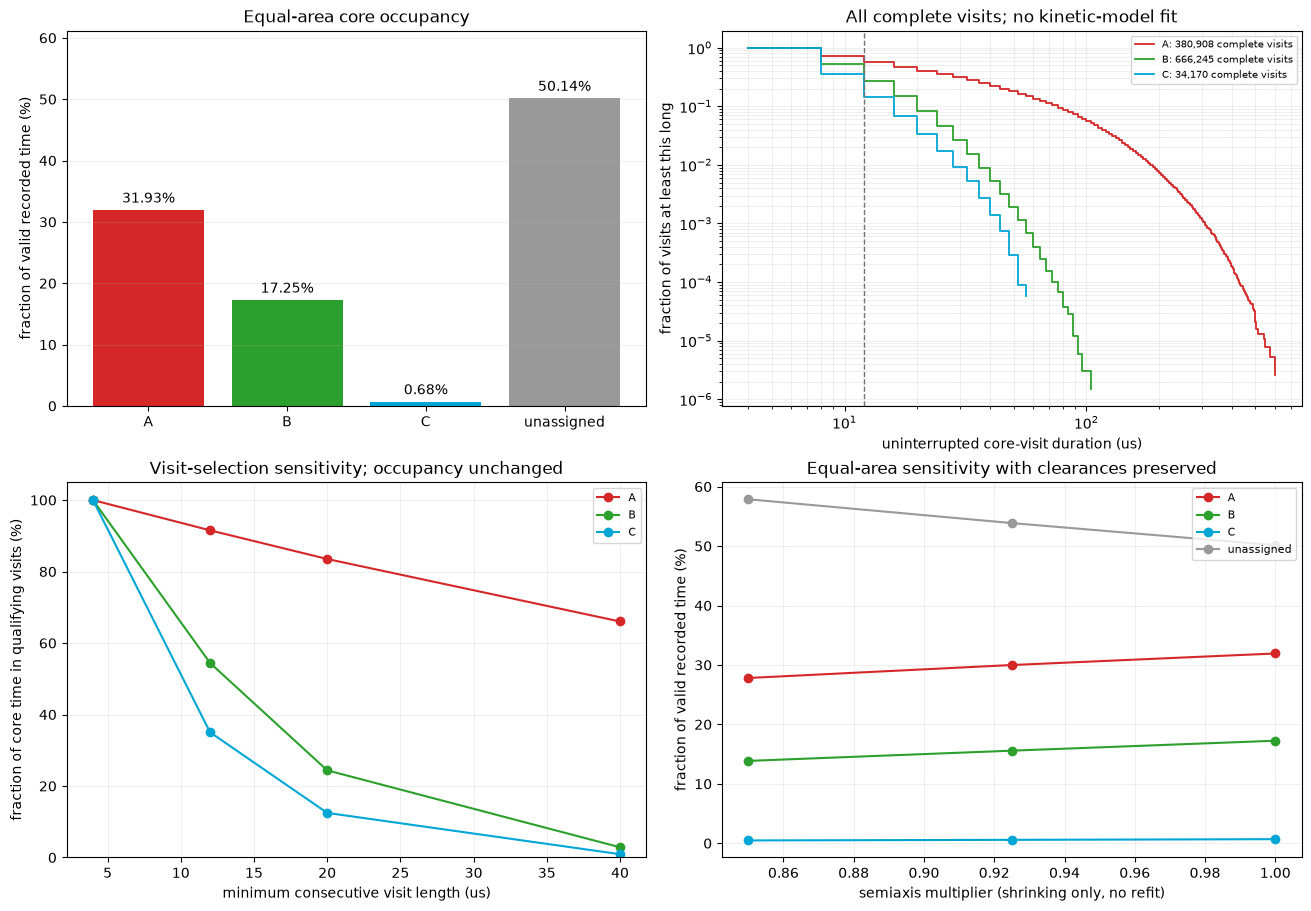

  core   minimum us   complete visits    median us   core time retained %
     A          4.0            380908         12.0                 100.00
     B          4.0            666245          8.0                 100.00
     C          4.0             34170          4.0                 100.00
     A         12.0            215876         28.0                  91.54
     B         12.0            182380         16.0                  54.42
     C         12.0              4983         12.0                  35.03
     A         20.0            154077         40.0                  83.52
     B         20.0             54784         24.0                  24.39
     C         20.0              1150         24.0                  12.48
     A         40.0             84728         68.0                  66.04
     B         40.0              3546         44.0                   2.86
     C         40.0                48         44.0                   0.92
Scaled cores keep equal areas and posi

In [91]:
ABC_VISIT_THRESHOLDS_US = (4.0, 12.0, 20.0, 40.0)
ABC_BOUNDARY_SCALE_FACTORS = (0.85, 0.925, 1.0)
abc_runs = ABC_RESIDENCE['runs']
abc_lengths = abc_runs['stop_idx'] - abc_runs['start_idx']
abc_complete_runs = ~(abc_runs['left_censored'] | abc_runs['right_censored'])
ABC_VISIT_SENSITIVITY = []
for threshold_us in ABC_VISIT_THRESHOLDS_US:
    threshold_samples = max(1, int(np.ceil(threshold_us * 1e-6 * abc_rate - 1e-10)))
    for code, name in enumerate(ABC_REGION_NAMES):
        region_runs = abc_runs['region_code'] == code
        retained_runs = region_runs & (abc_lengths >= threshold_samples)
        selected_durations = abc_runs['duration_s'][retained_runs & abc_complete_runs]
        original_time = ABC_RESIDENCE['summary'][name]['time_s']
        ABC_VISIT_SENSITIVITY.append(dict(
            region=name, threshold_us=threshold_samples / abc_rate * 1e6, n_complete=len(selected_durations),
            median_us=float(np.median(selected_durations) * 1e6) if len(selected_durations) else np.nan,
            retained_core_time_fraction=float(np.sum(abc_runs['duration_s'][retained_runs]) / original_time) if original_time else np.nan,
        ))

ABC_BOUNDARY_SENSITIVITY = []
for scale_factor in ABC_BOUNDARY_SCALE_FACTORS:
    if not 0 < scale_factor <= 1:
        raise ValueError('Use shrinking-only sensitivity to preserve the fitted no-touch constraints')
    for name, side in (('B', 1), ('C', -1)):
        scaled_region = dict(ABC_REGIONS[name], semiaxes=np.asarray(ABC_REGIONS[name]['semiaxes']) * scale_factor)
        gaps = ha.ellipse_region_clearances(scaled_region, ABC_A_RADIUS * scale_factor, ABC_SEPARATOR['normal'], side)
        if min(gaps.values()) < ABC_CLEARANCE - 1e-10:
            raise ValueError('Scaled regions violate the required clearance')
    scale_labels = ABC_LABELS if scale_factor == 1 else ha.classify_region_cores(
        abc_x, abc_y, ABC_REGIONS, valid=abc_photometry_flags['valid'], scale=scale_factor,
    )['labels']
    valid_count = np.count_nonzero(scale_labels != -2)
    scale_row = {'scale_factor': scale_factor}
    for code, name in (*enumerate(ABC_REGION_NAMES), (-1, 'unassigned')):
        scale_row[name] = np.count_nonzero(scale_labels == code) / valid_count if valid_count else np.nan
    ABC_BOUNDARY_SENSITIVITY.append(scale_row)
del scale_labels

fig, abc_summary_axes = plt.subplots(2, 2, figsize=(13, 9), layout='constrained')
abc_occupancy_axis, abc_duration_axis, abc_commit_axis, abc_boundary_axis = abc_summary_axes.ravel()
abc_occupancy_names = (*ABC_REGION_NAMES, 'unassigned')
abc_occupancies = np.array([ABC_RESIDENCE['summary'][name]['fraction_valid'] for name in abc_occupancy_names]) * 100
abc_bars = abc_occupancy_axis.bar(abc_occupancy_names, abc_occupancies, color=[ABC_COLORS[name] for name in abc_occupancy_names])
abc_occupancy_axis.bar_label(abc_bars, labels=[f'{value:.2f}%' for value in abc_occupancies], padding=3)
abc_occupancy_axis.set(ylabel='fraction of valid recorded time (%)', ylim=(0, max(abc_occupancies) * 1.2 + 1),
                       title='Equal-area core occupancy')
abc_occupancy_axis.grid(axis='y', alpha=.2)
for code, name in enumerate(ABC_REGION_NAMES):
    lengths = abc_lengths[(abc_runs['region_code'] == code) & abc_complete_runs]
    if len(lengths):
        unique_lengths, frequency = np.unique(lengths, return_counts=True)
        survival = (len(lengths) - np.concatenate(([0], np.cumsum(frequency[:-1])))) / len(lengths)
        abc_duration_axis.loglog(unique_lengths / abc_rate * 1e6, survival, drawstyle='steps-post',
                                 lw=1.3, color=ABC_COLORS[name], label=f'{name}: {len(lengths):,} complete visits')
abc_duration_axis.axvline(abc_min_samples / abc_rate * 1e6, color='0.45', ls='--', lw=1)
abc_duration_axis.set(xlabel='uninterrupted core-visit duration (us)', ylabel='fraction of visits at least this long',
                      title='All complete visits; no kinetic-model fit')
abc_duration_axis.legend(fontsize=7)
abc_duration_axis.grid(alpha=.2, which='both')
for name in ABC_REGION_NAMES:
    rows = [row for row in ABC_VISIT_SENSITIVITY if row['region'] == name]
    abc_commit_axis.plot([row['threshold_us'] for row in rows], [100 * row['retained_core_time_fraction'] for row in rows],
                         'o-', color=ABC_COLORS[name], label=name)
abc_commit_axis.set(xlabel='minimum consecutive visit length (us)', ylabel='fraction of core time in qualifying visits (%)',
                    ylim=(0, 105), title='Visit-selection sensitivity; occupancy unchanged')
abc_commit_axis.legend(fontsize=8)
abc_commit_axis.grid(alpha=.2)
for name in abc_occupancy_names:
    abc_boundary_axis.plot([row['scale_factor'] for row in ABC_BOUNDARY_SENSITIVITY], [100 * row[name] for row in ABC_BOUNDARY_SENSITIVITY],
                           'o-', color=ABC_COLORS[name], label=name)
abc_boundary_axis.set(xlabel='semiaxis multiplier (shrinking only, no refit)', ylabel='fraction of valid recorded time (%)',
                      title='Equal-area sensitivity with clearances preserved')
abc_boundary_axis.legend(fontsize=8)
abc_boundary_axis.grid(alpha=.2)
plt.show()
print(f'{"core":>6} {"minimum us":>12} {"complete visits":>17} {"median us":>12} {"core time retained %":>22}')
for row in ABC_VISIT_SENSITIVITY:
    print(f'{row["region"]:>6} {row["threshold_us"]:12.1f} {row["n_complete"]:17d} {row["median_us"]:12.1f} '
          f'{100 * row["retained_core_time_fraction"]:22.2f}')
print('Scaled cores keep equal areas and positive clearances. This is descriptive sensitivity, not a confidence interval.')
print('Complete core visits exclude edge/gap-censored visits. Native observations are correlated; visit counts are not independent events.')

## 1e. Earlier Ellipse B/C Passages and Central-A Contacts

This is the retained ellipse-based comparison, with A at the origin. It is separate from the current annular-sector route test above; these B/C labels and `no_A_sample` counts must not be substituted for the new A/B/C, trans_AB, trans_BC, or O definitions.

### Counting rules

- A committed visit is an uninterrupted core run meeting the selected minimum duration. The default is `ABC_MIN_VISIT_US`; the sweep compares 4, 12, 20, and 40 us.
- The three-by-three matrix counts changes between successive committed visits. Shorter contacts and unassigned samples can intervene, so it is not a matrix of exclusively physical direct transitions.
- B/C endpoint passages start at the last sample of the latest committed source visit and end at the first sample of the next committed opposite endpoint. A repeated committed source visit resets that start.
- `no_A_sample` means no observation inside A. `brief_A` means some A samples but no qualifying uninterrupted A run. `committed_A` means at least one qualifying A run. Even one A sample excludes the first category.
- Invalid photometry and timestamp gaps reset the chain. Unassigned observations are retained, never assigned to A or filled. No time filtering is applied.

### Interpretation and historical examples

A no-A-sample event is a candidate bypass of a chosen disk, not proof of a physical path avoiding A. The connector screen identifies possible crossings of A between adjacent measured points; it does not reconstruct the physical motion.

`ABC_BC_INSPECT_MIN_US` selects this ellipse candidate browser. Its contents depend on region boundaries and minimum visit duration. The preserved-example section after it is independent of that list: both old 40 us examples near 11.803 s remain recoverable by fixed native indices, with frozen old geometry and verified reference traces.

The larger geometric gaps do not establish a noise floor or physical time resolution. Keep candidate counts tied to their own geometry and commitment settings.

Successive committed core visits (minimum 12 us): rows=from, columns=to
                      A          B          C
           A          0      30100       3306
           B      30099          0        575
           C       3307        574          0

B/C endpoint passages, retaining ALL intervening A contacts:
 minimum us  direction   no A sample     brief A    committed A
        4.0       B->C          9770           0           9014
        4.0       C->B          9549           0           9234
       12.0       B->C           516          59           2750
       12.0       C->B           494          80           2751
       20.0       B->C            26          23            907
       20.0       C->B            32          18            906
       40.0       B->C             0           0             47
       40.0       C->B             0           1             46

At the selected 12 us commitment:
B->C: 516 no-A-sample candidates; 4 have a straight inter-sample connec

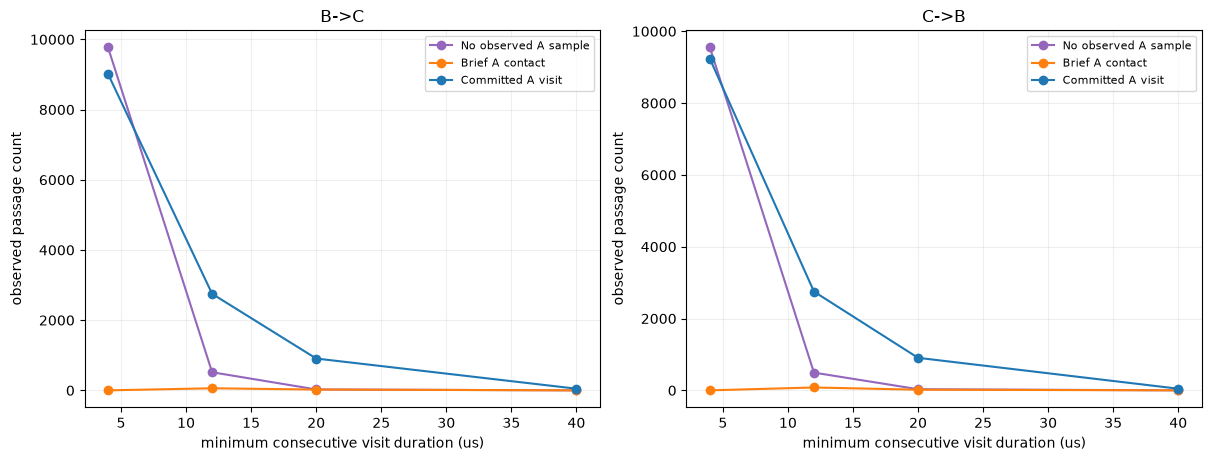

Counts are over the recorded interval, not independent observations or fitted kinetic rates.
No invalid sample or timestamp gap is crossed. Unassigned time is retained as intervening data, not assigned to A/B/C.
No-A-sample events are candidate bypasses of the chosen A disk only; 4 us sampling, noise, and region placement limit physical interpretation.


In [92]:
ABC_TRANSITION_THRESHOLDS_US = (4.0, 12.0, 20.0, 40.0)
ABC_TRANSITIONS = ha.region_transition_counts(ABC_RESIDENCE, ABC_REGION_NAMES)
ABC_TRANSITION_SWEEP = []
for threshold_us in ABC_TRANSITION_THRESHOLDS_US:
    required_samples = max(1, int(np.ceil(threshold_us * 1e-6 * abc_rate - 1e-10)))
    if required_samples == abc_min_samples:
        transition_result = ABC_TRANSITIONS
    else:
        threshold_residence = ha.region_residence_statistics(
            ABC_LABELS, abc_times, abc_rate, ABC_REGION_NAMES, min_visit_samples=required_samples,
        )
        transition_result = ha.region_transition_counts(threshold_residence, ABC_REGION_NAMES)
        del threshold_residence
    ABC_TRANSITION_SWEEP.append({'minimum_us': required_samples / abc_rate * 1e6,
                                 'counts': transition_result['counts'].copy(),
                                 'bc_counts': transition_result['bc_counts']})
del transition_result

print(f'Successive committed core visits (minimum {ABC_TRANSITIONS["minimum_visit_s"] * 1e6:.0f} us): rows=from, columns=to')
print('             ' + ' '.join(f'{name:>10}' for name in ABC_REGION_NAMES))
for name, counts in zip(ABC_REGION_NAMES, ABC_TRANSITIONS['counts']):
    print(f'{name:>12} ' + ' '.join(f'{count:10d}' for count in counts))
print('\nB/C endpoint passages, retaining ALL intervening A contacts:')
print(f'{"minimum us":>11} {"direction":>10} {"no A sample":>13} {"brief A":>11} {"committed A":>14}')
for sweep in ABC_TRANSITION_SWEEP:
    for direction, counts in sweep['bc_counts'].items():
        print(f'{sweep["minimum_us"]:11.1f} {direction:>10} {counts["no_A_sample"]:13d} '
              f'{counts["brief_A"]:11d} {counts["committed_A"]:14d}')

def screen_bc_passage(passage, x_values, y_values, a_radius):
    """Inspect measured and straight-connector proximity to A; not a physical path interpolation."""
    start, stop = passage['start_idx'], passage['end_idx'] + 1
    points = np.column_stack((x_values[start:stop], y_values[start:stop]))
    offsets = np.diff(points, axis=0)
    squared_lengths = np.sum(offsets**2, axis=1)
    projection = np.divide(-np.sum(points[:-1] * offsets, axis=1), squared_lengths,
                            out=np.zeros(len(offsets)), where=squared_lengths > 0)
    projection = np.clip(projection, 0, 1)
    feet = points[:-1] + projection[:, None] * offsets
    minimum_sample_radius = float(np.linalg.norm(points, axis=1).min())
    minimum_connector_radius = float(np.linalg.norm(feet, axis=1).min())
    return dict(passage, path_samples=len(points), min_sample_radius=minimum_sample_radius,
                min_connector_radius=minimum_connector_radius,
                connector_intersects_A=minimum_connector_radius <= a_radius,
                adjacent_core_samples=(stop - start == 2))

ABC_BC_NO_A_CANDIDATES = [
    screen_bc_passage(passage, abc_x, abc_y, ABC_A_RADIUS)
    for passage in ABC_TRANSITIONS['bc_passages'] if passage['category'] == 'no_A_sample'
 ]
print(f'\nAt the selected {ABC_TRANSITIONS["minimum_visit_s"] * 1e6:.0f} us commitment:')
for direction in ('B->C', 'C->B'):
    selected_candidates = [candidate for candidate in ABC_BC_NO_A_CANDIDATES
                           if f'{candidate["from"]}->{candidate["to"]}' == direction]
    print(f'{direction}: {len(selected_candidates)} no-A-sample candidates; '
          f'{sum(candidate["connector_intersects_A"] for candidate in selected_candidates)} have a straight inter-sample connector crossing A; '
          f'{sum(candidate["adjacent_core_samples"] for candidate in selected_candidates)} have adjacent endpoint samples.')

fig, transition_axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for axis, direction in zip(transition_axes, ('B->C', 'C->B')):
    for category, label, color in (('no_A_sample', 'No observed A sample', 'tab:purple'),
                                   ('brief_A', 'Brief A contact', 'tab:orange'),
                                   ('committed_A', 'Committed A visit', 'tab:blue')):
        axis.plot([row['minimum_us'] for row in ABC_TRANSITION_SWEEP],
                  [row['bc_counts'][direction][category] for row in ABC_TRANSITION_SWEEP],
                  'o-', color=color, label=label)
    axis.set(xlabel='minimum consecutive visit duration (us)', ylabel='observed passage count', title=direction)
    axis.grid(alpha=.2)
    axis.legend(fontsize=8)
plt.show()
print('Counts are over the recorded interval, not independent observations or fitted kinetic rates.')
print('No invalid sample or timestamp gap is crossed. Unassigned time is retained as intervening data, not assigned to A/B/C.')
print('No-A-sample events are candidate bypasses of the chosen A disk only; 4 us sampling, noise, and region placement limit physical interpretation.')

In [93]:
from ipywidgets import interact, IntSlider

ABC_BC_INSPECT_MIN_US = 40.0
inspect_samples = max(1, int(np.ceil(ABC_BC_INSPECT_MIN_US * 1e-6 * abc_rate - 1e-10)))
inspect_residence = ha.region_residence_statistics(
    ABC_LABELS, abc_times, abc_rate, ABC_REGION_NAMES, min_visit_samples=inspect_samples,
 )
inspect_transitions = ha.region_transition_counts(inspect_residence, ABC_REGION_NAMES)
ABC_BC_EXAMPLES = []
for passage in inspect_transitions['bc_passages']:
    if passage['category'] == 'no_A_sample':
        example = screen_bc_passage(passage, abc_x, abc_y, ABC_A_RADIUS)
        example['source_visit_us'] = inspect_residence['runs']['duration_s'][passage['source_run']] * 1e6
        example['destination_visit_us'] = inspect_residence['runs']['duration_s'][passage['destination_run']] * 1e6
        ABC_BC_EXAMPLES.append(example)
del inspect_residence, inspect_transitions
print(f'{len(ABC_BC_EXAMPLES)} no-A-sample candidates at {inspect_samples / abc_rate * 1e6:.0f} us commitment:')
for example_index, example in enumerate(ABC_BC_EXAMPLES):
    print(f"{example_index}: {example['from']}->{example['to']}, t={abc_times[example['start_idx']]:.9f}..{abc_times[example['end_idx']]:.9f} s; "
          f"{example['path_samples']} path samples; min r={example['min_sample_radius']:.5f} (A radius={ABC_A_RADIUS:.5f}); "
          f"connector crosses A={example['connector_intersects_A']}")

def show_bc_candidate(candidate_index=0):
    event = ABC_BC_EXAMPLES[candidate_index]
    start, end = event['start_idx'], event['end_idx']
    view = slice(max(0, start - inspect_samples), min(len(abc_times), end + inspect_samples + 1))
    path = slice(start, end + 1)
    time_us = (abc_times[view] - abc_times[start]) * 1e6
    duration_us = (abc_times[end] - abc_times[start]) * 1e6
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout='constrained')
    axes[0].imshow(abc_counts.T, origin='lower', extent=[-1, 1, -1, 1], cmap='Greys',
                   norm=LogNorm(vmin=1), interpolation='nearest', alpha=.35)
    draw_abc_geometry(axes[0])
    axes[0].plot(abc_x[path], abc_y[path], '-', color='0.45', lw=.8)
    for code, name in (*enumerate(ABC_REGION_NAMES), (-1, 'unassigned'), (-2, 'invalid')):
        path_selected = ABC_LABELS[path] == code
        trace_selected = ABC_LABELS[view] == code
        axes[0].scatter(abc_x[path][path_selected], abc_y[path][path_selected], s=18, color=ABC_COLORS[name], zorder=3)
        axes[1].scatter(time_us[trace_selected], abc_x[view][trace_selected], s=9, color=ABC_COLORS[name])
        axes[2].scatter(time_us[trace_selected], abc_y[view][trace_selected], s=9, color=ABC_COLORS[name])
    axes[0].scatter(abc_x[start], abc_y[start], marker='s', s=65, facecolors='none', edgecolors='k')
    axes[0].scatter(abc_x[end], abc_y[end], marker='D', s=65, facecolors='none', edgecolors='k')
    axes[0].set_title('Native observations; connectors are not a resolved path')
    for axis, values, label in ((axes[1], abc_x, '$a_x$'), (axes[2], abc_y, '$a_y$')):
        axis.plot(time_us, values[view], '-', color='0.65', lw=.6, zorder=-1)
        axis.axvspan(0, duration_us, color='0.9', zorder=-2)
        axis.set(xlabel=f'time relative to {abc_times[start]:.9f} s (us)', ylabel=label)
        axis.grid(alpha=.2)
    fig.suptitle(f"Candidate {candidate_index}: {event['from']}->{event['to']} without an observed A sample; "
                 f"source/destination core visits {event['source_visit_us']:.0f}/{event['destination_visit_us']:.0f} us")
    plt.show()

if ABC_BC_EXAMPLES:
    interact(show_bc_candidate, candidate_index=IntSlider(value=0, min=0, max=len(ABC_BC_EXAMPLES) - 1,
                                                          description='candidate:', continuous_update=False))
else:
    print('No no-A-sample candidates at this commitment; this is not proof of physical impossibility.')

0 no-A-sample candidates at 40 us commitment:
No no-A-sample candidates at this commitment; this is not proof of physical impossibility.


### Preserved historical B-C examples

These are the **two examples selected with the earlier, freely oriented equal-area regions and 40 us commitment**. They are kept independently of the current fitter and candidate list:

| Historical direction | Native indices, inclusive | Time window (s) | Native samples |
|---|---|---|---|
| B to C | 2950730 to 2950742 | 11.802920 to 11.802968 | 13 |
| C to B | 2950751 to 2950756 | 11.803004 to 11.803024 | 6 |

`PRESERVED_BC_ARCHIVE` stores the acquisition indices, source recording, old A/B/C ellipses, old separator angle, commitment setting, and reference corrected `(ax, ay)` values. Recovered native values are checked against those references to an absolute tolerance of 1e-10; mismatched data stop the cell instead of silently showing a different event.

The `saved event` selector displays the same path with **frozen historical geometry** on the left, **current geometry** in the middle, and native channel-ratio traces with context on the right. Current region labels are printed separately. The examples remain available even when neither passes the new event-selection criteria.

The historical directional names describe the old classifier, not an immutable physical state assignment. Their preserved observations remain valid evidence to inspect; changing boundaries can change whether they count as B-C transitions or meet the minimum visit duration. `PRESERVED_BC_CONTEXT_US` controls the displayed context without changing either pinned path.

The earlier rank-549 event at 16.650518 to 16.650918 s remains separately pinned in Section 1c.

In [94]:
from pathlib import Path
from matplotlib.patches import Ellipse
from ipywidgets import interact, IntSlider

PRESERVED_BC_ARCHIVE = {
    'source': r'data\Hinge apd recordings, 2 strand + notches\1.tdms',
    'rate_hz': 250000.0, 'historical_commitment_us': 40.0,
    'separator_angle_deg': 141.25,
    'regions': {
        'A': dict(center=(0., 0.), semiaxes=(0.215243782321051, 0.215243782321051), angle_deg=0.),
        'B': dict(center=(-0.6700864297490235, 0.04470089052739498),
                  semiaxes=(0.3626496714489263, 0.12775383372819862), angle_deg=88.98994631600951),
        'C': dict(center=(-0.16479730124506736, 0.3852099987067501),
                  semiaxes=(0.2804088851041793, 0.165222602738352), angle_deg=166.86220476290066),
    },
    'events': [
        dict(direction='B->C', start_idx=2950730, end_idx=2950742,
             reference_ax=[-0.6734582965564955, -0.5555788491441571, -0.4944102996145252,
                           -0.3476230795513049, -0.3951382913060279, -0.43630610201479764,
                           -0.3987380163654492, -0.4180700441938777, -0.44747831000191723,
                           -0.5336909023442119, -0.47576111835159907, -0.4507856597805553,
                           -0.3792414948620669],
             reference_ay=[0.0996496519001184, 0.22456115402633844, 0.259143354620231,
                           0.26668699272391216, 0.32784769058636554, 0.29962900573050777,
                           0.29523797720512396, 0.3072123963461312, 0.18169149840099197,
                           0.15195670204554665, 0.21147857219014735, 0.2705415400243901,
                           0.35695156422743946]),
        dict(direction='C->B', start_idx=2950751, end_idx=2950756,
             reference_ax=[-0.3971678160193132, -0.501162823538918, -0.5242288277042536,
                           -0.4664584125477572, -0.5069628503117057, -0.6295666574482999],
             reference_ay=[0.38980959362405976, 0.31625979801766135, 0.1538776717527064,
                           0.2552410773512273, 0.2920705793029908, 0.2763386790231919]),
    ],
}
PRESERVED_BC_CONTEXT_US = 100.0

def recover_preserved_bc_events(recording, archive, context_us=100.0):
    """Recover fixed native indices and verify saved corrected ratios, independent of current fits."""
    if not np.isclose(recording['fps'], archive['rate_hz'], rtol=1e-9):
        raise ValueError('Native rate differs from the preserved recording')
    if not np.isfinite(context_us) or context_us < 0:
        raise ValueError('Context must be nonnegative and finite')
    recovered = []
    margin = int(np.ceil(context_us * 1e-6 * recording['fps']))
    for event in archive['events']:
        start, end = int(event['start_idx']), int(event['end_idx'])
        if not 0 <= start < end < len(recording['t']):
            raise ValueError('Preserved acquisition indices lie outside the recording')
        first, stop = max(0, start - margin), min(len(recording['t']), end + margin + 1)
        channels = {name: recording[name][first:stop] for name in ('c0', 'c90', 'c45', 'c135', 't')}
        channels['fps'] = recording['fps']
        x_values, y_values, times, rate, flags = ha.block_channel_means(channels, 1, return_flags=True)
        path = slice(start - first, end - first + 1)
        np.testing.assert_allclose(x_values[path], event['reference_ax'], rtol=0, atol=1e-10)
        np.testing.assert_allclose(y_values[path], event['reference_ay'], rtol=0, atol=1e-10)
        recovered.append(dict(event, ax=x_values, ay=y_values, t=times, rate=rate, flags=flags,
                              path_slice=path, native_indices=np.arange(first, stop)))
    return recovered

if Path(TDMS_PATH).resolve() != Path(PRESERVED_BC_ARCHIVE['source']).resolve():
    raise ValueError('The preserved examples belong to another recording; load their source to inspect them')
PRESERVED_BC_EVENTS = recover_preserved_bc_events(r1, PRESERVED_BC_ARCHIVE, PRESERVED_BC_CONTEXT_US)
for event in PRESERVED_BC_EVENTS:
    path = event['path_slice']
    print(f"Preserved historical {event['direction']}: native [{event['start_idx']}, {event['end_idx']}] inclusive, "
          f"{event['t'][path][0]:.9f}..{event['t'][path][-1]:.9f} s, {len(event['t'][path])} samples; reference trace verified.")

def show_preserved_bc(example_index=0):
    event = PRESERVED_BC_EVENTS[example_index]
    path = event['path_slice']
    start_time = event['t'][path][0]
    path_times = (event['t'][path] - start_time) * 1e6
    window_times = (event['t'] - start_time) * 1e6
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), layout='constrained')
    for axis, regions, title in (
        (axes[0], PRESERVED_BC_ARCHIVE['regions'], 'Historical regions (frozen)'),
        (axes[1], ABC_REGIONS, 'Current regions; same preserved samples'),
    ):
        for name, region in regions.items():
            axis.add_patch(Ellipse(region['center'], 2 * region['semiaxes'][0], 2 * region['semiaxes'][1],
                                   angle=region.get('angle_deg', 0), fill=False, color=ABC_COLORS[name], lw=1.4))
            axis.text(*region['center'], name, color=ABC_COLORS[name], ha='center', va='center')
        axis.plot(event['ax'][path], event['ay'][path], color='0.65', lw=.8)
        points = axis.scatter(event['ax'][path], event['ay'][path], c=path_times, cmap='viridis', s=26, zorder=3)
        axis.scatter(event['ax'][path][0], event['ay'][path][0], marker='s', s=75, edgecolors='k', facecolors='none', zorder=4)
        axis.scatter(event['ax'][path][-1], event['ay'][path][-1], marker='D', s=75, edgecolors='k', facecolors='none', zorder=4)
        axis.set(xlabel='$a_x$', ylabel='$a_y$', aspect='equal', xlim=(-1, .4), ylim=(-.55, .85), title=title)
        axis.grid(alpha=.15)
    axes[2].plot(window_times, event['ax'], 'o-', ms=3, lw=.8, label='$a_x$')
    axes[2].plot(window_times, event['ay'], 'o-', ms=3, lw=.8, label='$a_y$')
    axes[2].axvspan(0, path_times[-1], color='0.9', zorder=-1)
    axes[2].set(xlabel=f'time from {start_time:.9f} s (us)', ylabel='corrected anisotropy', title='Native 4 us trace and context')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=.2)
    fig.colorbar(points, ax=list(axes[:2]), label='time from preserved path start (us)', shrink=.7)
    fig.suptitle(f"Preserved historical {event['direction']} example; not reselected by the current classifier")
    plt.show()
    old_labels = ha.classify_region_cores(event['ax'][path], event['ay'][path], PRESERVED_BC_ARCHIVE['regions'])['labels']
    new_labels = ha.classify_region_cores(event['ax'][path], event['ay'][path], ABC_REGIONS)['labels']
    print(f'Path labels: historical={old_labels.tolist()}, current={new_labels.tolist()} (A=0, B=1, C=2, unassigned=-1)')
    print('Historical event names and 40 us selection are preserved; current geometry may change their event classification.')

interact(show_preserved_bc, example_index=IntSlider(value=0, min=0, max=len(PRESERVED_BC_EVENTS) - 1,
                                                   description='saved event:', continuous_update=False))

Preserved historical B->C: native [2950730, 2950742] inclusive, 11.802920000..11.802968000 s, 13 samples; reference trace verified.
Preserved historical C->B: native [2950751, 2950756] inclusive, 11.803004000..11.803024000 s, 6 samples; reference trace verified.


interactive(children=(IntSlider(value=0, continuous_update=False, description='saved event:', max=1), Output()…

<function __main__.show_preserved_bc(example_index=0)>

## 1f. Earlier Rotated-Ellipse Control

This retained control rotates the ellipse-based B/C regions and keeps the earlier central A disk. It does not rotate or redefine the new annular sectors, O, or transition wedges, and its counts are not the current annular route comparison.

The original separator and B/C ellipses rotate counterclockwise together about the origin. A and all measured observations remain unchanged. With the shared-radius geometry, B and C also have the same radial extents; rigid rotation preserves those extents, their shared shape, equal areas, and all inter-region edge gaps.

`ROTATION_CCW_DEG = None` selects the smallest positive angle putting all of C-prime on the old B side of the previous line with the required separator clearance. `ROTATION_MARGIN_DEG = 2` adds a geometric margin. An override must satisfy the same full-ellipse crossing check. The angle is not selected from transition outcomes, and neither ellipse is refitted after rotation.

The comparison reports native point counts, occupied seconds, committed source/destination visits, no-A fractions among opposite-endpoint passages, and counts normalized by source exposure. The original and rotated conditions use identical commitment settings and preserve every observed A contact. Ratios with no qualifying passages are undefined, not zero.

These normalizations do not make the control a proof of distinct states: density, noise, and kinetics can depend on direction. Larger region gaps should reduce some boundary sensitivity, but counts and finite-sampling limitations must still be inspected. Historical examples in the preceding section remain available regardless of the control result.

In [95]:
def rotate_region_frame(regions, separator_normal, ccw_deg):
    """Rigidly rotate B, C, and separator around the unchanged origin-centered A disk."""
    if set(regions) != {'A', 'B', 'C'} or not np.isfinite(ccw_deg):
        raise ValueError('Require A/B/C regions and a finite rotation angle')
    a_center = np.asarray(regions['A']['center'], dtype=float)
    a_axes = np.asarray(regions['A']['semiaxes'], dtype=float)
    if (a_center.shape != (2,) or a_axes.shape != (2,) or not np.allclose(a_center, 0, atol=1e-12, rtol=0)
            or not np.all(np.isfinite(a_axes)) or np.any(a_axes <= 0) or not np.isclose(a_axes[0], a_axes[1])):
        raise ValueError('The control requires A to be a full origin-centered disk')
    normal = np.asarray(separator_normal, dtype=float)
    if normal.shape != (2,) or not np.all(np.isfinite(normal)) or np.linalg.norm(normal) == 0:
        raise ValueError('separator_normal must be a finite nonzero coordinate pair')
    normal = normal / np.linalg.norm(normal)
    angle = np.radians(ccw_deg)
    rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    rotated_regions = {}
    for name, region in regions.items():
        copied = dict(region, center=np.asarray(region['center'], dtype=float).copy(),
                      semiaxes=np.asarray(region['semiaxes'], dtype=float).copy())
        if name != 'A':
            copied['center'] = rotation @ copied['center']
            copied['angle_deg'] = float((region.get('angle_deg', 0.) + ccw_deg) % 180)
        rotated_regions[name] = copied
    return dict(regions=rotated_regions, normal=rotation @ normal, ccw_deg=float(ccw_deg))

def choose_opposite_side_rotation(regions, separator_normal, *, clearance=0.005, margin_deg=2.0, ccw_override=None):
    """Choose the first CCW C crossing of the old separator using geometry only, not data."""
    from scipy.optimize import brentq

    if not np.isfinite(clearance) or clearance <= 0 or not np.isfinite(margin_deg) or margin_deg < 0:
        raise ValueError('Require positive clearance and nonnegative angular margin')
    a_radius = float(regions['A']['semiaxes'][0])
    initial_gap = ellipse_region_clearances(regions['C'], a_radius, separator_normal, -1)['line_gap']
    if initial_gap <= 0:
        raise ValueError('Original C must lie entirely on its designated side of the old line')

    def old_line_margin(ccw_deg):
        rotated = rotate_region_frame(regions, separator_normal, ccw_deg)
        return ellipse_region_clearances(rotated['regions']['C'], a_radius, separator_normal, 1)['line_gap'] - clearance

    grid = np.linspace(0, 180, 721)
    previous_angle, previous_margin = float(grid[0]), old_line_margin(grid[0])
    minimum_ccw = None
    for angle in grid[1:]:
        current_margin = old_line_margin(angle)
        if previous_margin < 0 <= current_margin:
            minimum_ccw = float(brentq(old_line_margin, previous_angle, float(angle), xtol=1e-10))
            break
        previous_angle, previous_margin = float(angle), current_margin
    if minimum_ccw is None:
        raise ValueError('No CCW rotation up to 180 deg places all of C across the old separator')
    chosen_angle = minimum_ccw + margin_deg if ccw_override is None else float(ccw_override)
    if not np.isfinite(chosen_angle) or not 0 < chosen_angle <= 180:
        raise ValueError('Chosen control rotation must be CCW in (0, 180] degrees')
    control = rotate_region_frame(regions, separator_normal, chosen_angle)
    old_line_gap = ellipse_region_clearances(control['regions']['C'], a_radius, separator_normal, 1)['line_gap']
    if old_line_gap < clearance - 1e-10:
        raise ValueError("C' does not fully clear the previous separator at the chosen angle")
    for name, side in (('B', 1), ('C', -1)):
        old_gaps = ellipse_region_clearances(regions[name], a_radius, separator_normal, side)
        new_gaps = ellipse_region_clearances(control['regions'][name], a_radius, control['normal'], side)
        np.testing.assert_allclose(list(new_gaps.values()), list(old_gaps.values()), rtol=1e-8, atol=1e-10)
        if min(new_gaps.values()) < clearance - 1e-10:
            raise ValueError('Rotated geometry violates a required A/line clearance')
        np.testing.assert_allclose(control['regions'][name]['semiaxes'], regions[name]['semiaxes'])
    control.update(minimum_ccw_deg=minimum_ccw, old_line_c_gap=float(old_line_gap))
    return control

ROTATION_CCW_DEG = None
ROTATION_MARGIN_DEG = 2.0
ROTATION_THRESHOLDS_US = (4.0, 12.0, 20.0, 40.0)

ROTATION_CONTROL = choose_opposite_side_rotation(
    ABC_REGIONS, ABC_SEPARATOR['normal'], clearance=ABC_CLEARANCE,
    margin_deg=ROTATION_MARGIN_DEG, ccw_override=ROTATION_CCW_DEG,
 )
ROTATED_REGIONS = ROTATION_CONTROL['regions']
ROTATED_LABELS = classify_region_cores(
    abc_x, abc_y, ROTATED_REGIONS, valid=abc_photometry_flags['valid'],
 )['labels']
np.testing.assert_array_equal(ROTATED_LABELS == 0, ABC_LABELS == 0)
np.testing.assert_array_equal(ROTATED_LABELS == -2, ABC_LABELS == -2)
print(f"Minimum CCW rotation for C' to clear the old line: {ROTATION_CONTROL['minimum_ccw_deg']:.4f} deg")
print(f"Applied rigid rotation: +{ROTATION_CONTROL['ccw_deg']:.4f} deg; C' gap from old line={ROTATION_CONTROL['old_line_c_gap']:.6f}")
print('A membership is identical. B/C areas, aspect ratios, radial distances and new-line clearances are unchanged.')
print('Data and acquisition times are not rotated, smoothed, or decimated. No ellipse is refitted after rotation.')
print('Internal codes remain A/B/C; in the rotated condition B and C denote B-prime and C-prime.')

Minimum CCW rotation for C' to clear the old line: 20.9965 deg
Applied rigid rotation: +22.9965 deg; C' gap from old line=0.025309
A membership is identical. B/C areas, aspect ratios, radial distances and new-line clearances are unchanged.
Data and acquisition times are not rotated, smoothed, or decimated. No ellipse is refitted after rotation.
Internal codes remain A/B/C; in the rotated condition B and C denote B-prime and C-prime.


In [96]:
def compare_region_rotations(labels_by_condition, times, rate, minimum_visits_us):
    """Compare identical counting rules with explicit occupancy and conditional denominators."""
    occupancy_rows = []
    passage_rows = []
    transition_matrices = {}
    for condition, labels in labels_by_condition.items():
        base = region_residence_statistics(labels, times, rate, ('A', 'B', 'C'), min_visit_samples=1)
        for region in ('A', 'B', 'C', 'unassigned', 'invalid'):
            values = base['summary'][region]
            occupancy_rows.append(dict(condition=condition, region=region, samples=values['samples'],
                                       time_s=values['time_s'], fraction_valid=values['fraction_valid']))
        runs = base['runs']
        lengths = runs['stop_idx'] - runs['start_idx']
        for minimum_us in minimum_visits_us:
            if not np.isfinite(minimum_us) or minimum_us <= 0:
                raise ValueError('Minimum visit durations must be positive and finite')
            required = max(1, int(np.ceil(minimum_us * 1e-6 * rate - 1e-10)))
            selected_runs = dict(runs, retained=(runs['region_code'] >= 0) & (lengths >= required))
            selected_residence = dict(base, runs=selected_runs, minimum_visit_s=required / rate)
            transitions = region_transition_counts(selected_residence)
            realised_us = required / rate * 1e6
            transition_matrices[(condition, realised_us)] = transitions['counts'].copy()
            for direction, category_counts in transitions['bc_counts'].items():
                source, destination = direction.split('->')
                source_index, destination_index = ('A', 'B', 'C').index(source), ('A', 'B', 'C').index(destination)
                source_time = base['summary'][source]['time_s']
                source_visits = int(transitions['committed_visit_counts'][source_index])
                destination_visits = int(transitions['committed_visit_counts'][destination_index])
                total = int(sum(category_counts.values()))
                no_a = int(category_counts['no_A_sample'])
                passage_rows.append(dict(
                    condition=condition, minimum_us=realised_us, direction=direction,
                    no_A=no_a, brief_A=int(category_counts['brief_A']), committed_A=int(category_counts['committed_A']),
                    total_passages=total, no_A_fraction=no_a / total if total else np.nan,
                    source_samples=base['summary'][source]['samples'], destination_samples=base['summary'][destination]['samples'],
                    source_time_s=source_time, source_visits=source_visits, destination_visits=destination_visits,
                    no_A_per_source_s=no_a / source_time if source_time > 0 else np.nan,
                    no_A_per_1000_source_visits=1000 * no_a / source_visits if source_visits else np.nan,
                ))
    return dict(occupancy=occupancy_rows, passages=passage_rows, transition_matrices=transition_matrices)

ROTATION_COMPARISON = compare_region_rotations(
    {'original': ABC_LABELS, 'rotated': ROTATED_LABELS}, abc_times, abc_rate, ROTATION_THRESHOLDS_US,
 )
print('Native occupancy on the same recording; no time filtering:')
print(f'{"condition":>10} {"core":>12} {"samples":>12} {"seconds":>12} {"valid time %":>14}')
for row in ROTATION_COMPARISON['occupancy']:
    display_region = row['region'] + ("'" if row['condition'] == 'rotated' and row['region'] in ('B', 'C') else '')
    print(f'{row["condition"]:>10} {display_region:>12} {row["samples"]:12,d} {row["time_s"]:12.6f} {100 * row["fraction_valid"]:14.3f}')

print('\nEndpoint passages: source = last committed source-core visit; A contacts are never erased.')
print(f'{"condition":>10} {"min us":>7} {"direction":>11} {"no A":>8} {"brief A":>9} {"commit A":>10} {"total":>9} {"no A %":>10}')
for row in ROTATION_COMPARISON['passages']:
    direction = row['direction'] if row['condition'] == 'original' else row['direction'].replace('B', "B'").replace('C', "C'")
    print(f'{row["condition"]:>10} {row["minimum_us"]:7.1f} {direction:>11} {row["no_A"]:8d} {row["brief_A"]:9d} '
          f'{row["committed_A"]:10d} {row["total_passages"]:9d} {100 * row["no_A_fraction"]:10.3f}')

print('\nExposure and visit normalization (descriptive, NOT fitted rate constants):')
print(f'{"condition":>10} {"min us":>7} {"direction":>11} {"source visits":>15} {"dest visits":>13} {"no A/source s":>16} {"no A/1000 visits":>19}')
for row in ROTATION_COMPARISON['passages']:
    direction = row['direction'] if row['condition'] == 'original' else row['direction'].replace('B', "B'").replace('C', "C'")
    print(f'{row["condition"]:>10} {row["minimum_us"]:7.1f} {direction:>11} {row["source_visits"]:15d} {row["destination_visits"]:13d} '
          f'{row["no_A_per_source_s"]:16.3f} {row["no_A_per_1000_source_visits"]:19.3f}')
print('No A % = no-A-sample count / all opposite-endpoint passages, including brief and committed A visits.')
print('Source seconds include all samples inside that source core. Source-visit denominator counts committed uninterrupted runs.')
print('Undefined ratios are NaN, not zero. A rare endpoint or long commitment may leave too few passages for interpretation.')

Native occupancy on the same recording; no time filtering:
 condition         core      samples      seconds   valid time %
  original            A    2,633,989    10.535956         31.927
  original            B    1,422,814     5.691256         17.246
  original            C       56,255     0.225020          0.682
  original   unassigned    4,136,942    16.547768         50.145
  original      invalid            0     0.000000            nan
   rotated            A    2,633,989    10.535956         31.927
   rotated           B'      535,973     2.143892          6.497
   rotated           C'      501,840     2.007360          6.083
   rotated   unassigned    4,578,198    18.312792         55.493
   rotated      invalid            0     0.000000            nan

Endpoint passages: source = last committed source-core visit; A contacts are never erased.
 condition  min us   direction     no A   brief A   commit A     total     no A %
  original     4.0        B->C     9770         0   

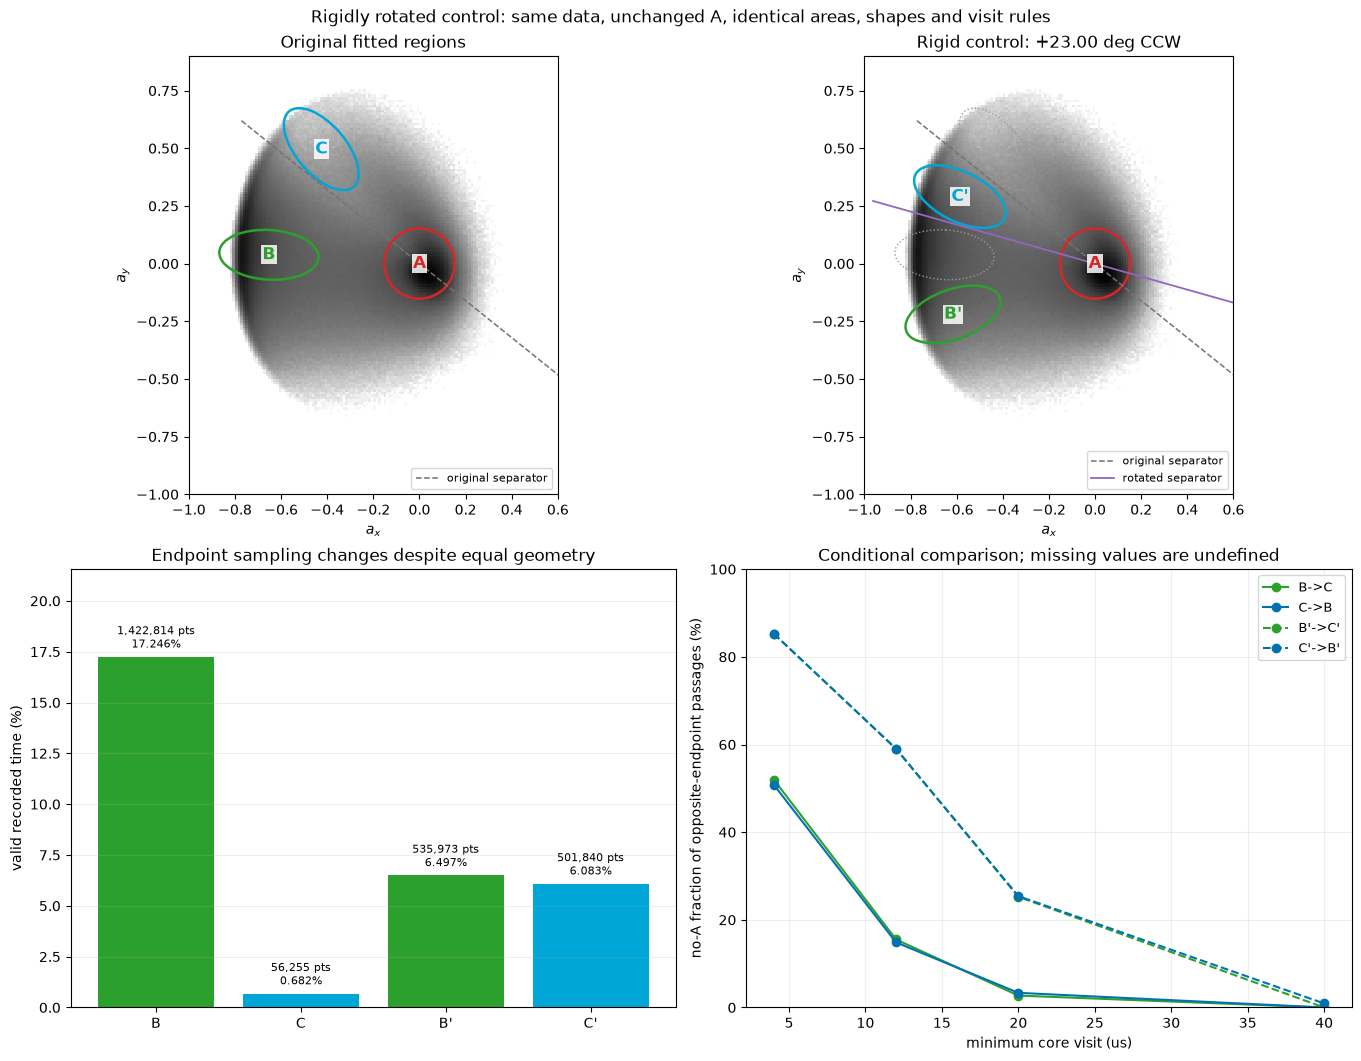

Rotation samples different density, noise, and dwell distributions. Higher control fractions indicate region-placement sensitivity, not proof that original B/C are different physical states.


In [97]:
from matplotlib.patches import Ellipse
from matplotlib.colors import LogNorm

rotation_density, rotation_x_edges, rotation_y_edges = np.histogram2d(
    abc_x[abc_photometry_flags['valid']], abc_y[abc_photometry_flags['valid']],
    bins=180, range=[[-1., 1.], [-1., 1.]],
 )
rotation_norm = LogNorm(vmin=1, vmax=max(2, rotation_density.max()))
fig, rotation_axes = plt.subplots(2, 2, figsize=(13.5, 10.5), layout='constrained')
for axis, condition, regions, normal in (
    (rotation_axes[0, 0], 'original', ABC_REGIONS, ABC_SEPARATOR['normal']),
    (rotation_axes[0, 1], 'rotated', ROTATED_REGIONS, ROTATION_CONTROL['normal']),
):
    axis.imshow(rotation_density.T, origin='lower', extent=[-1., 1., -1., 1.],
                cmap='Greys', norm=rotation_norm, interpolation='nearest')
    old_direction = np.array([ABC_SEPARATOR['normal'][1], -ABC_SEPARATOR['normal'][0]])
    axis.plot([-old_direction[0], old_direction[0]], [-old_direction[1], old_direction[1]],
              color='0.45', ls='--', lw=1.1, label='original separator')
    if condition == 'rotated':
        for name in ('B', 'C'):
            old_region = ABC_REGIONS[name]
            axis.add_patch(Ellipse(old_region['center'], width=2 * old_region['semiaxes'][0],
                                   height=2 * old_region['semiaxes'][1], angle=old_region['angle_deg'],
                                   fill=False, color='0.6', ls=':', lw=1))
        new_direction = np.array([normal[1], -normal[0]])
        axis.plot([-new_direction[0], new_direction[0]], [-new_direction[1], new_direction[1]],
                  color='tab:purple', lw=1.3, label='rotated separator')
    for name, region in regions.items():
        label = name + ("'" if condition == 'rotated' and name != 'A' else '')
        axis.add_patch(Ellipse(region['center'], width=2 * region['semiaxes'][0],
                               height=2 * region['semiaxes'][1], angle=region.get('angle_deg', 0.),
                               fill=False, color=ABC_COLORS[name], lw=1.8))
        axis.text(*region['center'], label, ha='center', va='center', fontsize=12, fontweight='bold',
                  color=ABC_COLORS[name], bbox=dict(facecolor='white', edgecolor='none', alpha=.85, pad=1))
    axis.set(xlabel='$a_x$', ylabel='$a_y$', xlim=(-1, .6), ylim=(-1, .9), aspect='equal',
             title='Original fitted regions' if condition == 'original' else f"Rigid control: +{ROTATION_CONTROL['ccw_deg']:.2f} deg CCW")
    axis.legend(fontsize=8, loc='lower right')

selected_occupancy = [row for row in ROTATION_COMPARISON['occupancy'] if row['region'] in ('B', 'C')]
occupancy_labels = [row['region'] + ("'" if row['condition'] == 'rotated' else '') for row in selected_occupancy]
occupancy_percent = [100 * row['fraction_valid'] for row in selected_occupancy]
rotation_bars = rotation_axes[1, 0].bar(occupancy_labels, occupancy_percent,
                                      color=[ABC_COLORS[row['region']] for row in selected_occupancy])
rotation_axes[1, 0].bar_label(rotation_bars, labels=[f'{row["samples"]:,} pts\n{100 * row["fraction_valid"]:.3f}%' for row in selected_occupancy],
                              padding=4, fontsize=8)
rotation_axes[1, 0].set(ylabel='valid recorded time (%)', ylim=(0, max(occupancy_percent) * 1.25),
                       title='Endpoint sampling changes despite equal geometry')
rotation_axes[1, 0].grid(axis='y', alpha=.2)

for condition, linestyle in (('original', '-'), ('rotated', '--')):
    for direction, color in (('B->C', '#2CA02C'), ('C->B', '#0072B2')):
        rows = [row for row in ROTATION_COMPARISON['passages'] if row['condition'] == condition and row['direction'] == direction]
        label = direction if condition == 'original' else direction.replace('B', "B'").replace('C', "C'")
        rotation_axes[1, 1].plot([row['minimum_us'] for row in rows], [100 * row['no_A_fraction'] for row in rows],
                                 marker='o', ls=linestyle, color=color, label=label)
rotation_axes[1, 1].set(xlabel='minimum core visit (us)', ylabel='no-A fraction of opposite-endpoint passages (%)',
                       ylim=(0, 100), title='Conditional comparison; missing values are undefined')
rotation_axes[1, 1].legend(fontsize=9)
rotation_axes[1, 1].grid(alpha=.2)
fig.suptitle('Rigidly rotated control: same data, unchanged A, identical areas, shapes and visit rules')
plt.show()

for condition in ('original', 'rotated'):
    rows = [row for row in ROTATION_COMPARISON['passages'] if row['condition'] == condition and row['minimum_us'] >= 39.999]
    if rows and any(row['total_passages'] == 0 for row in rows):
        print(f'{condition}: no opposite-endpoint passages at 40 us; the no-A fraction is undefined, NOT evidence of zero bypass probability.')
print('Rotation samples different density, noise, and dwell distributions. Higher control fractions indicate region-placement sensitivity, not proof that original B/C are different physical states.')

Synthetic reference: annular pupil + Fresnel interface; input theta is prescribed, not measured.
Full pupil: no hole or interface: r_max=0.926898; 21/901 simulated samples outside this inverse model
Annular pupil: hole only: r_max=0.921156; 53/901 simulated samples outside this inverse model
Annular pupil + Fresnel interface: r_max=0.927995; 0/901 simulated samples outside this inverse model


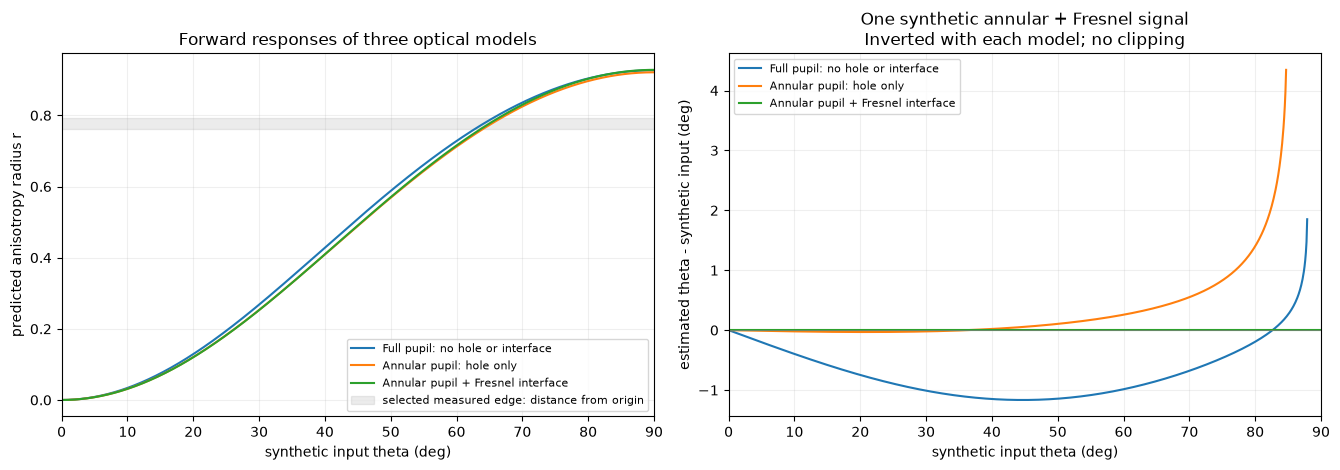

The matching annular/Fresnel forward-inverse pair is zero by construction, not experimental validation.
For any physical n >= NA=1.3, homogeneous full-pupil r_max is in [0.875, 1).
No physical refractive index gives r_max = fitted R=0.74051 in the homogeneous full-pupil model.
The fitted radius is measured about its fitted center, not the optical origin.
Circle fitting uses measured anisotropy, not inverted theta: angle clipping cannot create this edge.
The hole/Fresnel model assumes a circular annulus and one lossless interface, n_water=1.33, n_oil=1.515.


In [98]:
theta_input = np.linspace(0, 90, 901)
sine_squared_input = np.sin(np.radians(theta_input))**2
reference_a, reference_b, reference_c = OPTICAL_COEFFICIENTS['fresnel']
synthetic_fresnel_radius = reference_c * sine_squared_input / (reference_a + reference_b * sine_squared_input)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
print('Synthetic reference: annular pupil + Fresnel interface; input theta is prescribed, not measured.')
for model_name, coefficients in OPTICAL_COEFFICIENTS.items():
    coeff_a, coeff_b, coeff_c = coefficients
    model_radius = coeff_c * sine_squared_input / (coeff_a + coeff_b * sine_squared_input)
    reconstructed, model_flags = ha.theta_from_r(
        synthetic_fresnel_radius, *coefficients, return_flags=True,
    )
    axes[0].plot(theta_input, model_radius, label=MODEL_LABELS[model_name])
    axes[1].plot(theta_input, reconstructed - theta_input, label=MODEL_LABELS[model_name])
    print(f'{MODEL_LABELS[model_name]}: r_max={ha.r_max_of(*coefficients):.6f}; '
          f'{model_flags["over_range"].sum()}/{len(theta_input)} simulated samples outside this inverse model')
if rf is not None:
    selected_radius = np.hypot(rf['edge'][:, 0], rf['edge'][:, 1])
    axes[0].axhspan(selected_radius.min(), selected_radius.max(), color='0.5', alpha=0.15,
                    label='selected measured edge: distance from origin')
axes[0].set(xlabel='synthetic input theta (deg)', ylabel='predicted anisotropy radius r',
             title='Forward responses of three optical models', xlim=(0, 90))
axes[1].axhline(0, color='0.5', lw=0.5)
axes[1].set(xlabel='synthetic input theta (deg)', ylabel='estimated theta - synthetic input (deg)',
             title='One synthetic annular + Fresnel signal\nInverted with each model; no clipping', xlim=(0, 90))
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()
print('The matching annular/Fresnel forward-inverse pair is zero by construction, not experimental validation.')

print(f'For any physical n >= NA={NA}, homogeneous full-pupil r_max is in [0.875, 1).')
if rf is not None:
    target_radius = rf['R']
    if target_radius < 0.875 or target_radius >= 1:
        print(f'No physical refractive index gives r_max = fitted R={target_radius:.5f} in the homogeneous full-pupil model.')
    else:
        from scipy.optimize import brentq
        target_cosine = brentq(
            lambda cosine: (cosine**2 + 4 * cosine + 7) / (2 * (cosine**2 + cosine + 4)) - target_radius,
            0, 1,
        )
        formal_index = NA / np.sqrt(1 - target_cosine**2)
        print(f'Formal n={formal_index:.6f} if R were an origin-centered full-pupil saturation radius; not applied.')
    print('The fitted radius is measured about its fitted center, not the optical origin.')
print('Circle fitting uses measured anisotropy, not inverted theta: angle clipping cannot create this edge.')
print(f'The hole/Fresnel model assumes a circular annulus and one lossless interface, n_water={N_WATER}, n_oil={N_OIL}.')

## 2. Three-stage theta occupancy and optional peak traces

Each row shows time-binned angle occupancy and the overall theta distribution for one stage: raw/full-pupil, gain-plus-matrix/full-pupil, then gain-plus-matrix/**annular-plus-Fresnel**. Each row uses its own inverse-model coefficients and validity mask. These are estimated optical polar angles, not measured ground truth.

`THETA_TIME_BIN_S` changes only displayed time bins, not the integration interval or reconstructed angles. All valid blocks enter the distributions.

This view does not assume two or three physical states. Distinct anisotropy regions can have the same radius and therefore the same theta. State counting should retain both anisotropy coordinates and temporal dwell information.

The optional `SHOW_TWO_PEAK_DIAGNOSTIC` produces one overlay per stage, fitting two components in 10 ms windows. Rejected or failed fits remain `NaN` without interpolation or contaminated median filtering. This descriptive overlay is not a state-count test.

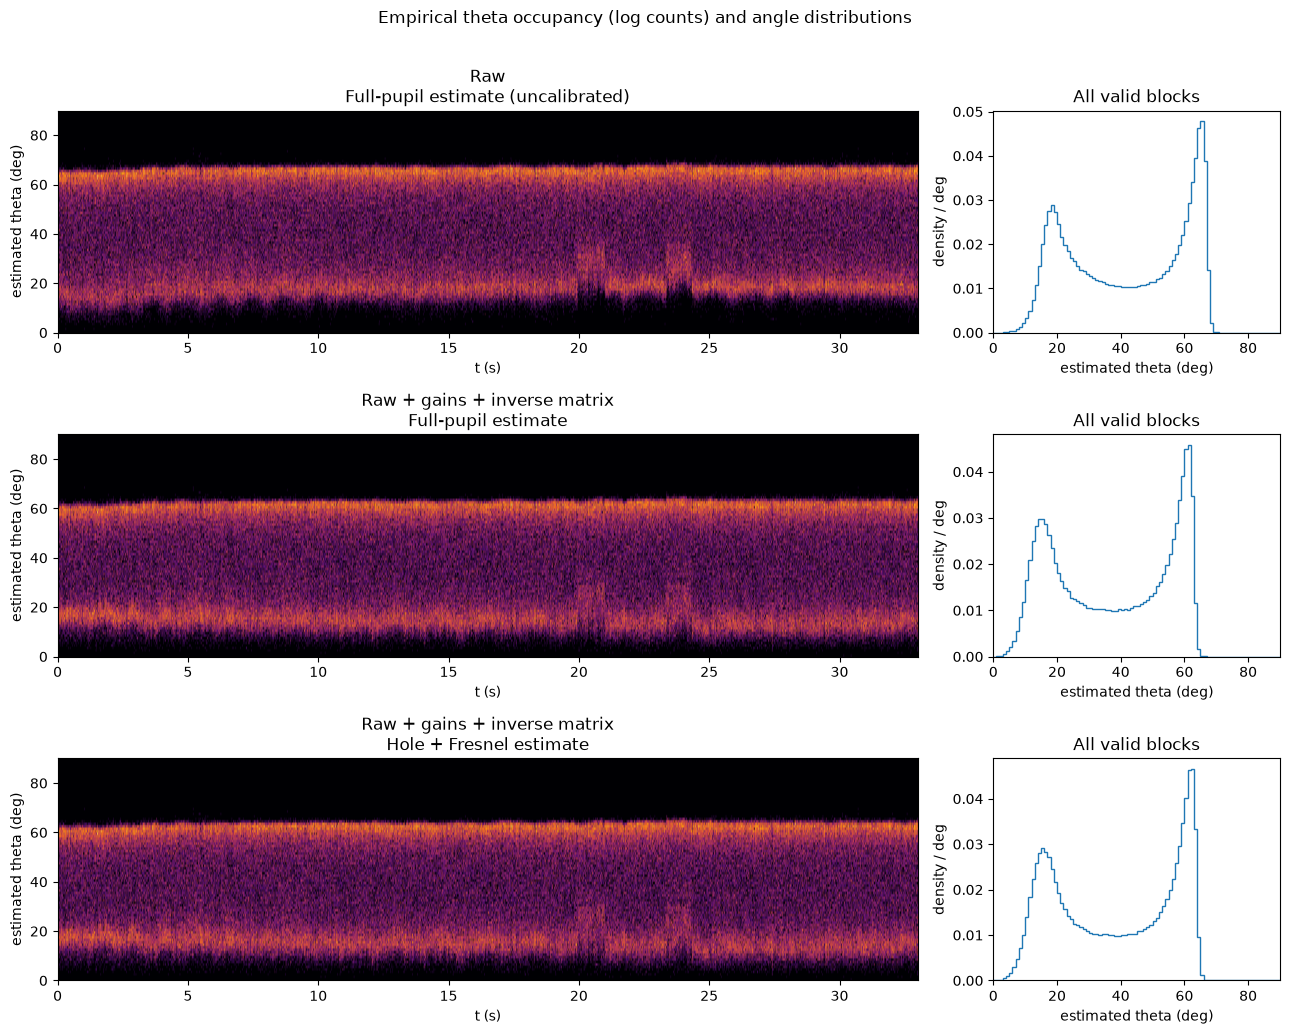

In [99]:
def two_peak_trace(theta_values, times, rate, axis, title, window_s=0.010):
    """Optional descriptive two-component fit; not a test for two physical states."""
    from sklearn.mixture import GaussianMixture

    window = max(int(round(window_s * rate)), 5)
    stride = max(window // 2, 1)
    starts = np.arange(0, max(0, len(theta_values) - window + 1), stride)
    window_times = np.asarray(times)[starts + window // 2]
    positions = np.full((len(starts), 2), np.nan)
    accepted = np.zeros(len(starts), dtype=bool)
    histogram_edges = np.arange(0, 91, 1.0)
    histogram_centers = 0.5 * (histogram_edges[:-1] + histogram_edges[1:])
    for window_index, start in enumerate(starts):
        values = np.asarray(theta_values[start:start + window], dtype=float)
        if not np.all(np.isfinite(values)) or np.ptp(values) < 1e-8:
            continue
        try:
            mixture = GaussianMixture(
                2, covariance_type='full', n_init=1, max_iter=60,
                tol=1e-3, random_state=0,
            ).fit(values[:, None])
            means = mixture.means_.ravel()
            order = np.argsort(means)
            if not (mixture.converged_ and np.min(mixture.weights_) > 0.12
                    and means[order[1]] - means[order[0]] > 15.0):
                continue
            labels = mixture.predict(values[:, None])
            components = [values[labels == component] for component in order]
            if any(len(component) == 0 for component in components):
                continue
            positions[window_index] = [
                histogram_centers[np.argmax(np.histogram(component, bins=histogram_edges)[0])]
                for component in components
            ]
            accepted[window_index] = True
        except (ValueError, np.linalg.LinAlgError):
            continue
    if np.any(accepted):
        axis.plot(window_times, positions[:, 0], lw=0.8, color='tab:blue', label='lower fitted peak')
        axis.plot(window_times, positions[:, 1], lw=0.8, color='tab:red', label='upper fitted peak')
        axis.legend(fontsize=8)
    axis.set(xlabel='t (s)', ylabel='theta (deg)', ylim=(0, 90),
             title=f'{title}: {accepted.sum()}/{len(starts)} accepted windows (two components assumed)')
    return dict(t=window_times, peaks=positions, valid=accepted)

if not np.isfinite(THETA_TIME_BIN_S) or THETA_TIME_BIN_S <= 0:
    raise ValueError('THETA_TIME_BIN_S must be positive and finite')
fig, axes = plt.subplots(len(STAGES), 2, figsize=(13, 3.5 * len(STAGES)),
                         gridspec_kw={'width_ratios': [3, 1]}, squeeze=False)
for row, (stage, (x_values, y_values, times, rate)) in enumerate(STAGES.items()):
    theta_values = THETA[stage]
    valid = VALIDITY[stage]['valid_angle']
    time_start = times[0] - 0.5 / rate
    time_end = times[-1] + 0.5 / rate
    time_bins = max(1, int(np.ceil((time_end - time_start) / THETA_TIME_BIN_S)))
    time_edges = np.linspace(time_start, time_end, time_bins + 1)
    angle_edges = np.linspace(0, 90, 91)
    counts, _, _ = np.histogram2d(times[valid], theta_values[valid], bins=[time_edges, angle_edges])
    axes[row, 0].imshow(np.log1p(counts.T), origin='lower', aspect='auto', cmap='inferno',
                        extent=[time_start, time_end, 0, 90])
    axes[row, 0].set(xlabel='t (s)', ylabel='estimated theta (deg)', title=STAGE_TITLES[stage])
    if np.any(valid):
        axes[row, 1].hist(theta_values[valid], bins=angle_edges, density=True, histtype='step', color='tab:blue')
    axes[row, 1].set(xlabel='estimated theta (deg)', ylabel='density / deg', xlim=(0, 90),
                     title='All valid blocks')
fig.suptitle('Empirical theta occupancy (log counts) and angle distributions')
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

TWO_PEAK_RESULTS = {}
if SHOW_TWO_PEAK_DIAGNOSTIC:
    fig, axes = plt.subplots(len(STAGES), 1, figsize=(13, 3 * len(STAGES)))
    for axis, (stage, (_, _, times, rate)) in zip(np.atleast_1d(axes), STAGES.items()):
        TWO_PEAK_RESULTS[stage] = two_peak_trace(THETA[stage], times, rate, axis, stage)
    fig.tight_layout()
    plt.show()

## 3. Unit Sphere: Three Azimuth Choices and Native Time Windows

`SPHERE_STAGE` selects `"raw"`, `"corrected"`, or **`"fresnel"`** (default). Raw and corrected use homogeneous full-pupil inversion; fresnel uses gain-plus-matrix corrected intensities with annular-plus-Fresnel inversion. All sphere modes retain the same theta and validity mask for the selected stage.

### Sampling and Editable Bounds

**`SPHERE_USE_NATIVE = True`**, at the top of the sphere-coordinate cell, uses every native observation, currently **4 us**. Set it to `False` to use the existing `BLOCK_US` overview, currently 80 us, then rerun the sphere-coordinate and two sphere-plot cells. This flag does not change the overview, region analysis, or pinned observations elsewhere in the notebook. Native theta and validity are recomputed from the native intensity ratios, not interpolated from the averaged angles.

The viewer starts with **200 us**, normally **50 native points**. `SPHERE_WINDOW_S = 0.0002` is only the initial duration, not a fixed window constraint. Optional `SPHERE_T_START` and `SPHERE_T_END` set initial absolute times in seconds; `None` uses the recording start and initial duration.

Both **t_start (s)** and **t_end (s)** are editable. Changing t_end resizes the interval. Moving t_start or the linked slider shifts the current interval, preserving its duration, so entering a new start followed by a new end is sufficient to select an arbitrary interval. Bounds stay inside the recording and at least one sampling period apart. `TIME_STEP_S = None` gives one-sample navigation, currently 4 us; a positive value overrides that step. Typed values are not snapped to the step.

All valid observations with timestamps in **`[t_start, t_end)`** are displayed; the end is exclusive. The title reports valid/total samples, since invalid observations can reduce the displayed count. Only machine-precision tolerance is used at time boundaries. No foreground thinning or smoothing is applied. `SHOW_EVERY`, `SPHERE_BACKGROUND_MAX_POINTS`, and `SPHERE_INTERACTIVE_MAX_POINTS` affect only the optional background displays, not the selected observations or unwrapping.

### Three Coordinate Modes

- **Folded:** principal azimuth $\phi=\tfrac12\operatorname{atan2}(a_y,a_x)$ in approximately -90 to +90 degrees, covering the positive-x half of the upper hemisphere.
- **Unwrapped:** $\phi_{\mathrm{trial}}=\tfrac12\operatorname{unwrap}(2\phi)$, the same simple nearest-step trial as before. It is initially selected.
- **Alternate fold:** leave nonnegative principal phi unchanged and add 180 degrees only to the negative-phi quadrant:

$$\phi_{\mathrm{alternate}}=\begin{cases}\phi+\pi,&\phi<0,\\\phi,&\phi\ge0.\end{cases}$$

Thus the alternate fold uses phi in 0-180 degrees and occupies the positive-y half of the upper hemisphere instead. Only that chosen quadrant changes: its x and y coordinates reverse sign, while theta and z remain unchanged. This is a different fixed branch convention, not another temporal unwrap.

All three choices preserve the measured `cos(2 phi)` and `sin(2 phi)`. Unwrapping is computed over uninterrupted valid runs of the full selected-sampling recording, **before display thinning**, not restarted when a window moves. Invalid observations, exact-pole samples with undefined azimuth, and timestamp gaps restart phase tracking. Pole observations remain plotted at the pole. Numerical arrays are `ph_s`, `ph_s_unwrapped`, `ph_s_alternate`, `SPHERE_UNWRAPPED_COORDINATES`, and `SPHERE_ALTERNATE_COORDINATES`.

Theta remains folded into 0-90 degrees in every mode. Neither changing the fold nor simple azimuth unwrapping establishes physical pole crossings. Near-zero anisotropy, noise, or fast motion can produce incorrect unwrap choices and accumulated winding; corrected branch jumps are not counted physical rotations.

### Connections and Camera

Within the selected interval, **Connections** joins consecutive valid observations in acquisition-time order in whichever mode is active. Missing or invalid samples and timestamp gaps break the lines; no observation is skipped to bridge them. A blue square marks the first valid point and an orange diamond the last; the final 20 points are outlined. Straight 3D segments are visual connectors, not reconstructed motion or interpolated measurements, and can pass inside the sphere.

Context is initially hidden to keep the short trace visible; its checkbox restores the thinned full-recording cloud. Time changes, interval resizing, and mode changes preserve the camera. Left drag rotates, middle drag pans, and right drag zooms in the normal toolbar mode; presets and the home button reset the view.

Four fixed perspectives retain the folded baseline at the selected sampling, with equal axis scaling and one theta color scale. They remain available without ipympl or a functioning widget renderer. The dedicated interactive canvas restores the previous global Matplotlib backend after importing ipympl.

In [116]:
SPHERE_USE_NATIVE = True
SPHERE_BACKGROUND_MAX_POINTS = 25000

def unwrap_sphere_azimuth(phi, times, rate, valid=None):
    """Unwrap the measured double azimuth within each uninterrupted valid run."""
    phi = np.asarray(phi, dtype=float)
    times = np.asarray(times, dtype=float)
    if phi.ndim != 1 or times.shape != phi.shape:
        raise ValueError('phi and times must be matching one-dimensional arrays')
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError('rate must be positive and finite')
    increments = np.diff(times)
    if not np.all(np.isfinite(times)) or np.any(increments <= 0):
        raise ValueError('times must be finite and strictly increasing')
    usable = np.isfinite(phi)
    if valid is not None:
        valid = np.asarray(valid, dtype=bool)
        if valid.shape != phi.shape:
            raise ValueError('valid must match phi')
        usable &= valid
    unwrapped = np.full(phi.shape, np.nan)
    if not len(phi):
        return unwrapped
    adjacent = usable[:-1] & usable[1:] & np.isclose(increments, 1 / rate, rtol=1e-6, atol=1e-12)
    starts = np.flatnonzero(usable & np.concatenate(([True], ~adjacent)))
    stops = np.flatnonzero(usable & np.concatenate((~adjacent, [True]))) + 1
    for start, stop in zip(starts, stops):
        unwrapped[start:stop] = 0.5 * np.unwrap(2 * phi[start:stop])
    return unwrapped

def alternate_sphere_azimuth(phi):
    """Move the negative principal-azimuth quadrant by +pi; leave the other unchanged."""
    phi = np.asarray(phi, dtype=float)
    return np.where(np.isfinite(phi), np.where(phi < 0, phi + np.pi, phi), np.nan)

if SPHERE_STAGE not in STAGES:
    raise ValueError(f"SPHERE_STAGE must be one of {tuple(STAGES)}")
if isinstance(SHOW_EVERY, bool) or int(SHOW_EVERY) != SHOW_EVERY or SHOW_EVERY < 1:
    raise ValueError('SHOW_EVERY must be a positive integer')
if (isinstance(SPHERE_BACKGROUND_MAX_POINTS, bool)
        or int(SPHERE_BACKGROUND_MAX_POINTS) != SPHERE_BACKGROUND_MAX_POINTS or SPHERE_BACKGROUND_MAX_POINTS < 1):
    raise ValueError('SPHERE_BACKGROUND_MAX_POINTS must be a positive integer')
if SPHERE_USE_NATIVE:
    sphere_recording = rec if SPHERE_STAGE == 'raw' else r1
    Xs, Ys, ts, fps_s, sphere_channel_flags = ha.block_channel_means(sphere_recording, 1, return_flags=True)
else:
    Xs, Ys, ts, fps_s = STAGES[SPHERE_STAGE]
    sphere_channel_flags = CHANNEL_FLAGS[SPHERE_STAGE]
r_s = np.hypot(Xs, Ys)
sphere_theta_deg, sphere_radius_flags = ha.theta_from_r(
    r_s, *OPTICAL_COEFFICIENTS[STAGE_MODELS[SPHERE_STAGE]], return_flags=True,
 )
sphere_valid = sphere_channel_flags['valid'] & sphere_radius_flags['valid']
sphere_theta_deg = np.where(sphere_valid, sphere_theta_deg, np.nan)
th_s = np.radians(sphere_theta_deg)
ph_s = 0.5 * np.arctan2(Ys, Xs)
azimuth_undefined = sphere_valid & (r_s == 0)
ph_s = np.where(sphere_valid & ~azimuth_undefined, ph_s, np.nan)
ph_s_unwrapped = unwrap_sphere_azimuth(ph_s, ts, fps_s, valid=sphere_valid & ~azimuth_undefined)
ph_s_alternate = alternate_sphere_azimuth(ph_s)
sphere_folded_phi = np.where(azimuth_undefined, 0., ph_s)
sphere_unwrapped_phi = np.where(azimuth_undefined, 0., ph_s_unwrapped)
sphere_alternate_phi = np.where(azimuth_undefined, 0., ph_s_alternate)
xd = np.sin(th_s) * np.cos(sphere_folded_phi)
yd = np.sin(th_s) * np.sin(sphere_folded_phi)
zd = np.cos(th_s)
SPHERE_UNWRAPPED_COORDINATES = np.column_stack((
    np.sin(th_s) * np.cos(sphere_unwrapped_phi),
    np.sin(th_s) * np.sin(sphere_unwrapped_phi), zd,
))
SPHERE_ALTERNATE_COORDINATES = np.column_stack((
    np.sin(th_s) * np.cos(sphere_alternate_phi),
    np.sin(th_s) * np.sin(sphere_alternate_phi), zd,
))
dec = int(SHOW_EVERY) * max(1, int(np.ceil(len(ts) / (SHOW_EVERY * SPHERE_BACKGROUND_MAX_POINTS))))
sphere_display = np.arange(0, len(ts), dec)
sphere_display = sphere_display[sphere_valid[sphere_display]]
sphere_phase_pairs = (np.isfinite(ph_s[:-1]) & np.isfinite(ph_s[1:])
                      & np.isclose(np.diff(ts), 1 / fps_s, rtol=1e-6, atol=1e-12))
sphere_branch_jumps = sphere_phase_pairs & (np.abs(np.diff(ph_s)) > np.pi / 2)
print(f"Sphere: {SPHERE_STAGE}, {'native' if SPHERE_USE_NATIVE else 'overview'} sampling, {1e6 / fps_s:g} us; "
      f"{sphere_valid.sum():,}/{len(ts):,} valid observations, {len(sphere_display):,} background points.")
print(f"Optical model: {MODEL_LABELS[STAGE_MODELS[SPHERE_STAGE]]}; r_max={R_MAX_BY_STAGE[SPHERE_STAGE]:.6f}")
print(f'Invalid angle/photometry observations={np.count_nonzero(~sphere_valid):,}; '
      f'undefined azimuth at exact pole={azimuth_undefined.sum():,}. No clipping or gap filling.')
print(f'Simple azimuth unwrap: {sphere_branch_jumps.sum():,} principal-branch jumps adjusted; '
      'theta is unchanged and remains <= 90 deg.')
print('Alternate fold: add 180 deg only where principal phi < 0; the other quadrant stays unchanged.')
print('All selected-window observations are retained. Only background displays are thinned; other analyses keep their original sampling.')

Sphere: fresnel, native sampling, 4 us; 8,250,000/8,250,000 valid observations, 25,000 background points.
Optical model: Annular pupil + Fresnel interface; r_max=0.927995
Invalid angle/photometry observations=0; undefined azimuth at exact pole=0. No clipping or gap filling.
Simple azimuth unwrap: 1,227,329 principal-branch jumps adjusted; theta is unchanged and remains <= 90 deg.
Alternate fold: add 180 deg only where principal phi < 0; the other quadrant stays unchanged.
All selected-window observations are retained. Only background displays are thinned; other analyses keep their original sampling.


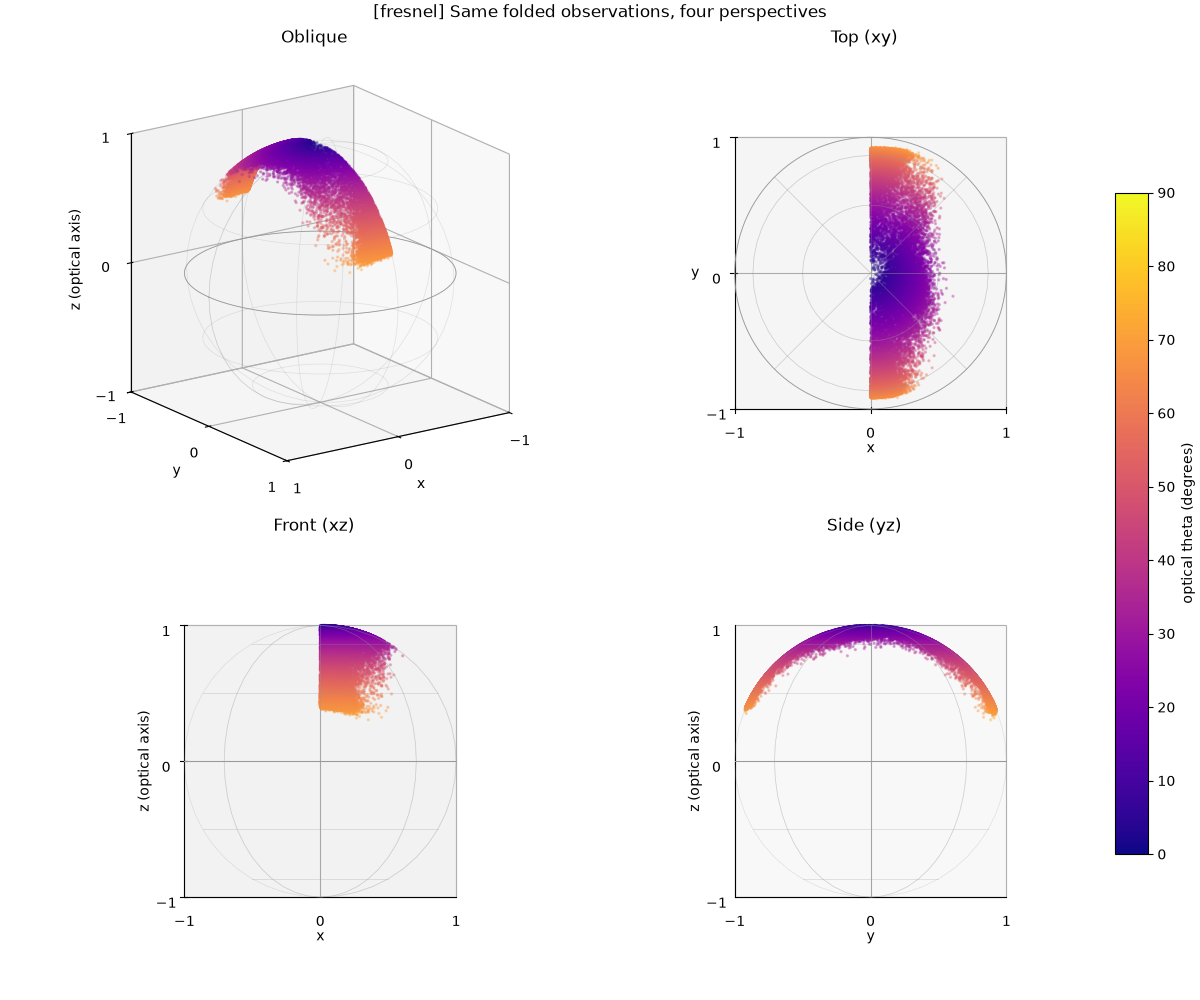

In [117]:
SPHERE_VIEWS = {'Oblique': (float(VIEW['elev']), float(VIEW['azim'])),
                'Top (xy)': (90., -90.), 'Front (xz)': (0., -90.), 'Side (yz)': (0., 0.)}

def set_sphere_view(axis, view):
    axis.set(xticks=(-1, 0, 1), yticks=(-1, 0, 1), zticks=(-1, 0, 1),
             xlabel='x', ylabel='y', zlabel='z (optical axis)')
    axis.view_init(elev=view[0], azim=view[1])
    hidden_axis = None
    if np.isclose(abs(view[0]) % 180, 90.):
        hidden_axis = axis.zaxis
    elif np.isclose(view[0] % 180, 0.):
        if np.isclose(view[1] % 180, 90.):
            hidden_axis = axis.yaxis
        elif np.isclose(view[1] % 180, 0.):
            hidden_axis = axis.xaxis
    if hidden_axis is not None:
        hidden_axis.set_ticks([])
        hidden_axis.set_label_text('')

def draw_sphere_frame(axis, view=(18., 55.)):
    azimuth_grid, polar_grid = np.meshgrid(np.linspace(0, 2 * np.pi, 49), np.linspace(0, np.pi, 25))
    axis.plot_wireframe(np.cos(azimuth_grid) * np.sin(polar_grid),
                         np.sin(azimuth_grid) * np.sin(polar_grid), np.cos(polar_grid),
                         rstride=4, cstride=6, color='0.6', alpha=.25, linewidth=.5)
    equator = np.linspace(0, 2 * np.pi, 120)
    axis.plot(np.cos(equator), np.sin(equator), np.zeros_like(equator), color='0.6', lw=.6)
    axis.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
    axis.set_box_aspect((1, 1, 1))
    axis.set_proj_type('ortho')
    set_sphere_view(axis, view)
    return axis

sphere_theta_deg = np.degrees(th_s)
sphere_perspective_figure = plt.figure(figsize=(12, 10), layout='constrained')
for sphere_view_number, (sphere_view_name, sphere_view_angles) in enumerate(SPHERE_VIEWS.items(), 1):
    sphere_view_axis = sphere_perspective_figure.add_subplot(2, 2, sphere_view_number, projection='3d')
    draw_sphere_frame(sphere_view_axis, sphere_view_angles)
    sphere_view_points = sphere_view_axis.scatter(
        xd[sphere_display], yd[sphere_display], zd[sphere_display], s=2,
        c=sphere_theta_deg[sphere_display], cmap='plasma', vmin=0, vmax=90, alpha=.3, depthshade=False,
    )
    sphere_view_axis.set_title(sphere_view_name)
sphere_perspective_figure.colorbar(
    plt.cm.ScalarMappable(norm=Normalize(0, 90), cmap='plasma'),
    ax=sphere_perspective_figure.axes, label='optical theta (degrees)', shrink=.7, pad=.02,
 )
sphere_perspective_figure.suptitle(f'[{SPHERE_STAGE}] Same folded observations, four perspectives')
plt.show()

In [118]:
SPHERE_WINDOW_S = 0.0002
SPHERE_T_START = None
SPHERE_T_END = None
SPHERE_INTERACTIVE_MAX_POINTS = 25000

def create_sphere_widget(coordinates, theta_deg, times, valid, display_indices, views, *,
                         time_step=None, window_s=0.0002, max_context_points=25000, title='Sphere',
                         unwrapped_coordinates=None, alternate_coordinates=None, t_start=None, t_end=None):
    import matplotlib
    from matplotlib.figure import Figure
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    backend_before = matplotlib.get_backend()
    fallback_before = matplotlib.rcParams['backend_fallback']
    try:
        from ipympl.backend_nbagg import Canvas, FigureManager
    finally:
        if matplotlib.get_backend() != backend_before:
            matplotlib.use(backend_before)
        matplotlib.rcParams['backend_fallback'] = fallback_before
    from ipywidgets import FloatSlider, BoundedFloatText, Dropdown, ToggleButtons, Button, Checkbox, HBox, VBox, Layout, link
    coordinates = np.asarray(coordinates, dtype=float)
    theta_deg, times = np.asarray(theta_deg, dtype=float), np.asarray(times, dtype=float)
    valid = np.asarray(valid, dtype=bool)
    if (times.ndim != 1 or len(times) == 0 or coordinates.shape != (len(times), 3)
            or theta_deg.shape != times.shape or valid.shape != times.shape
            or not np.all(np.isfinite(times)) or np.any(np.diff(times) <= 0)):
        raise ValueError('Sphere coordinates, angles, validity and increasing times must match')
    if (not np.isfinite(window_s) or window_s <= 0
            or isinstance(max_context_points, bool) or int(max_context_points) != max_context_points
            or max_context_points < 1):
        raise ValueError('Initial window and maximum context points must be positive')
    interval = float(np.median(np.diff(times))) if len(times) > 1 else float(window_s)
    time_step = interval if time_step is None else float(time_step)
    if not np.isfinite(time_step) or time_step <= 0:
        raise ValueError('Time step must be positive and finite')
    record_start, record_end = float(times[0]), float(times[-1]) + interval
    t_start = record_start if t_start is None else float(t_start)
    t_end = min(record_end, t_start + max(window_s, interval)) if t_end is None else float(t_end)
    boundary_tolerance = 16 * np.finfo(float).eps * max(1., abs(record_start), abs(record_end))
    if (not np.all(np.isfinite([t_start, t_end])) or t_start < record_start
            or t_end > record_end + boundary_tolerance or t_end - t_start < interval - boundary_tolerance):
        raise ValueError('Require recording start <= t_start < t_end <= recording end and at least one sample interval')
    t_end = min(t_end, record_end)
    bounds = dict(start=t_start, end=t_end, busy=False)
    coordinate_modes = {'Folded': coordinates}
    mode_tips = ['Principal azimuth']
    for mode, values, tip in (('Unwrapped', unwrapped_coordinates, 'Simple pi-periodic azimuth unwrap'),
                              ('Alternate fold', alternate_coordinates, 'Negative principal phi shifted by +180 degrees')):
        if values is not None:
            values = np.asarray(values, dtype=float)
            if values.shape != coordinates.shape:
                raise ValueError(f'{mode} coordinates must match the folded coordinates')
            coordinate_modes[mode] = values
            mode_tips.append(tip)
    usable_by_mode = {mode: valid & np.all(np.isfinite(values), axis=1) & np.isfinite(theta_deg)
                      for mode, values in coordinate_modes.items()}
    display_indices = np.asarray(display_indices, dtype=int)
    if display_indices.ndim != 1 or np.any(display_indices < 0) or np.any(display_indices >= len(times)):
        raise ValueError('Display indices are outside the sphere observations')
    display_indices = display_indices[usable_by_mode['Folded'][display_indices]]
    stride = max(1, int(np.ceil(len(display_indices) / max_context_points)))
    background_indices = display_indices[::stride]
    figure = Figure(figsize=(9.2, 7.2), layout='constrained')
    canvas = Canvas(figure)
    manager = FigureManager(canvas, num=0)
    canvas.toolbar_visible = True
    canvas.toolbar_position = 'top'
    canvas.header_visible = False
    canvas.resizable = True
    canvas.capture_scroll = True
    canvas.layout = Layout(width='100%', max_width='920px')
    axis = figure.add_subplot(111, projection='3d')
    first_view = next(iter(views))
    draw_sphere_frame(axis, views[first_view])
    axis.mouse_init(rotate_btn=1, pan_btn=2, zoom_btn=3)
    background = axis.scatter([], [], [], s=2, c=[], cmap='plasma',
                               vmin=0, vmax=90, alpha=.18, depthshade=False)
    window_path = Line3DCollection([], colors='0.35', linewidths=.8, alpha=.8)
    axis.add_collection3d(window_path, autolim=False)
    window_points = axis.scatter([], [], [], s=14, c=[], cmap='plasma',
                                  vmin=0, vmax=90, alpha=.9, depthshade=False)
    recent_points = axis.scatter([], [], [], s=35, c=[], cmap='plasma',
                                  vmin=0, vmax=90, edgecolors='black', linewidths=.5, depthshade=False)
    start_point = axis.scatter([], [], [], s=80, marker='s', facecolors='none',
                                edgecolors='#0072B2', linewidths=1.4, depthshade=False, label='first valid')
    end_point = axis.scatter([], [], [], s=80, marker='D', facecolors='none',
                              edgecolors='#D55E00', linewidths=1.4, depthshade=False, label='last valid')
    axis.legend(loc='upper left', fontsize=8)
    figure.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, 90), cmap='plasma'),
                     ax=axis, label='optical theta (degrees)', shrink=.7, pad=.03)
    max_start = max(t_start, record_end - (t_end - t_start))
    time_control = FloatSlider(value=t_start, min=record_start, max=max_start,
                                step=time_step, continuous_update=False,
                                description='Time', readout_format='.6f', layout=Layout(width='350px'))
    time_input = BoundedFloatText(value=t_start, min=record_start, max=max_start,
                                  step=time_step, continuous_update=False, description='t_start (s)',
                                  layout=Layout(width='240px'))
    end_input = BoundedFloatText(value=t_end, min=t_start + interval, max=record_end,
                                 step=time_step, continuous_update=False, description='t_end (s)',
                                 layout=Layout(width='240px'))
    time_link = link((time_control, 'value'), (time_input, 'value'))
    mode_control = ToggleButtons(options=list(coordinate_modes),
                                  value='Unwrapped' if unwrapped_coordinates is not None else 'Folded',
                                  tooltips=mode_tips)
    view_control = Dropdown(options=list(views), value=first_view,
                            description='View', layout=Layout(width='210px'))
    reset_control = Button(icon='home', tooltip='Reset camera', layout=Layout(width='38px'))
    context_control = Checkbox(value=False, description='Context', indent=False, layout=Layout(width='100px'))
    connection_control = Checkbox(value=True, description='Connections', indent=False, layout=Layout(width='120px'))
    background.set_visible(context_control.value)

    def update_window(_change=None):
        start_time, stop_time = float(time_input.value), float(end_input.value)
        active_coordinates = coordinate_modes[mode_control.value]
        usable = usable_by_mode[mode_control.value]
        lower, upper = np.searchsorted(times, np.array([start_time, stop_time]) - boundary_tolerance)
        selected = np.flatnonzero(usable[lower:upper]) + lower
        for collection, indices in ((window_points, selected), (recent_points, selected[-20:]),
                                     (start_point, selected[:1]), (end_point, selected[-1:])):
            collection.set_offsets(active_coordinates[indices, :2])
            collection.set_3d_properties(active_coordinates[indices, 2], zdir='z')
        window_points.set_array(theta_deg[selected])
        recent_points.set_array(theta_deg[selected[-20:]])
        adjacent = ((np.diff(selected) == 1)
                    & np.isclose(np.diff(times[selected]), interval, rtol=1e-6, atol=1e-12))
        segments = np.stack((active_coordinates[selected[:-1][adjacent]],
                             active_coordinates[selected[1:][adjacent]]), axis=1)
        window_path.set_segments(segments)
        span = stop_time - start_time
        duration_label = f'{span * 1e6:g} us' if span < .001 else f'{span * 1e3:g} ms'
        axis.set_title(f'{title}: {mode_control.value}, {duration_label}\n'
                       f'{start_time:.6f}-{stop_time:.6f} s; {len(selected):,}/{upper - lower:,} valid samples')
        canvas.draw_idle()

    def update_start(change):
        if bounds['busy']:
            return
        duration = bounds['end'] - bounds['start']
        bounds['busy'] = True
        try:
            new_start = float(change['new'])
            end_input.min = min(record_end, new_start + interval)
            end_input.value = min(record_end, new_start + duration)
            bounds.update(start=new_start, end=float(end_input.value))
        finally:
            bounds['busy'] = False
        update_window()

    def update_end(change):
        if bounds['busy']:
            return
        bounds['busy'] = True
        try:
            bounds['end'] = float(change['new'])
            maximum = max(bounds['start'], record_end - (bounds['end'] - bounds['start']))
            time_control.max = maximum
            time_input.max = maximum
        finally:
            bounds['busy'] = False
        update_window()

    def update_mode(_change=None):
        active_coordinates = coordinate_modes[mode_control.value]
        indices = background_indices[usable_by_mode[mode_control.value][background_indices]]
        background.set_offsets(active_coordinates[indices, :2])
        background.set_3d_properties(active_coordinates[indices, 2], zdir='z')
        background.set_array(theta_deg[indices])
        update_window()

    def update_view(change):
        set_sphere_view(axis, views[change['new']])
        canvas.draw_idle()

    def reset_view(_button):
        view_control.value = first_view
        set_sphere_view(axis, views[first_view])
        axis.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
        canvas.draw_idle()

    def update_context(change):
        background.set_visible(change['new'])
        canvas.draw_idle()

    def update_connections(change):
        window_path.set_visible(change['new'])
        canvas.draw_idle()

    def finish_rotation(event):
        if event.inaxes is axis:
            current_roll = axis.roll
            set_sphere_view(axis, (axis.elev, axis.azim))
            axis.roll = current_roll
            canvas.draw_idle()

    time_input.observe(update_start, names='value')
    end_input.observe(update_end, names='value')
    mode_control.observe(update_mode, names='value')
    view_control.observe(update_view, names='value')
    context_control.observe(update_context, names='value')
    connection_control.observe(update_connections, names='value')
    reset_control.on_click(reset_view)
    rotation_callback = canvas.mpl_connect('button_release_event', finish_rotation)
    time_controls = HBox([time_input, end_input, time_control], layout=Layout(flex_flow='row wrap'))
    mode_controls = HBox([mode_control], layout=Layout(flex_flow='row wrap'))
    view_controls = HBox([view_control, reset_control, context_control, connection_control],
                         layout=Layout(flex_flow='row wrap'))
    widget = VBox([time_controls, mode_controls, view_controls, canvas], layout=Layout(width='100%'))
    update_mode()
    canvas.draw()
    if matplotlib.get_backend() != backend_before:
        raise RuntimeError('Sphere creation unexpectedly changed the global plotting backend')
    return dict(widget=widget, figure=figure, canvas=canvas, manager=manager, axis=axis,
                background=background, window_points=window_points, recent_points=recent_points,
                window_path=window_path, start_point=start_point, end_point=end_point,
                time_control=time_control, time_input=time_input, start_input=time_input, end_input=end_input,
                time_link=time_link, mode_control=mode_control, view_control=view_control, reset_control=reset_control,
                context_control=context_control, connection_control=connection_control, update_window=update_window,
                rotation_callback=rotation_callback, background_count=len(background_indices), backend=backend_before)

previous_sphere_widget = globals().get('SPHERE_WIDGET')
if previous_sphere_widget is not None:
    if 'time_link' in previous_sphere_widget:
        previous_sphere_widget['time_link'].unlink()
    previous_sphere_widget['canvas'].close()
    previous_sphere_widget['manager'].toolbar.close()
    previous_sphere_widget['widget'].close()
try:
    SPHERE_WIDGET = create_sphere_widget(
        np.column_stack((xd, yd, zd)), sphere_theta_deg, ts, sphere_valid, sphere_display, SPHERE_VIEWS,
        time_step=TIME_STEP_S, window_s=SPHERE_WINDOW_S, max_context_points=SPHERE_INTERACTIVE_MAX_POINTS,
        title=f'[{SPHERE_STAGE}, {1e6 / fps_s:g} us sampling] orientation trial',
        unwrapped_coordinates=SPHERE_UNWRAPPED_COORDINATES, alternate_coordinates=SPHERE_ALTERNATE_COORDINATES,
        t_start=SPHERE_T_START, t_end=SPHERE_T_END,
    )
except ImportError as sphere_widget_error:
    SPHERE_WIDGET = None
    print(f'Interactive sphere unavailable: {sphere_widget_error}. The four fixed perspectives above remain available.')
else:
    display(SPHERE_WIDGET['widget'])
    print(f'ipympl canvas ready; other plots retain backend {SPHERE_WIDGET["backend"]}.')
    print(f'Initial interval: {SPHERE_WIDGET["start_input"].value:.6f} to {SPHERE_WIDGET["end_input"].value:.6f} s; '
          f'navigation step {SPHERE_WIDGET["time_control"].step * 1e6:g} us.')
    print('Edit t_end to resize; moving t_start or the slider shifts the current interval. Bounds stay inside the recording.')
    print('Connections join consecutive valid observations in the selected mode; invalid observations and timestamp gaps break lines.')
    print(f'{SPHERE_WIDGET["background_count"]:,} optional background points; no selected-window observations are thinned.')

ipympl canvas ready; other plots retain backend module://ipympl.backend_nbagg.
Initial interval: 0.000000 to 0.000200 s; navigation step 4 us.
Edit t_end to resize; moving t_start or the slider shifts the current interval. Bounds stay inside the recording.
Connections join consecutive valid observations in the selected mode; invalid observations and timestamp gaps break lines.
25,000 optional background points; no selected-window observations are thinned.
